# PN-TDNN-DPD Training: CWGAN-GP with QAT

**Version:** 2.0 (Production)  
**Architecture:** Phase-Normalized TDNN (24-dim, M=3, 1,362 params)  
**Training:** CWGAN-GP + Spectral Loss + ILA  

## Key Design Decisions

| Component | Specification | Reason |
|-----------|--------------|--------|
| Input dim | 24 | 6 features × 4 taps (M=3) |
| Memory depth | M=3 | Captures >95% GaN PA memory |
| Feature extraction | Phase-normalized | Decouples amplitude/phase learning |
| Output activation | Linear (no Tanh) | Phase denorm bounds output naturally |
| Training | ILA | No PA model in loop |
| QAT | Q1.15 weights, Q8.8 activations | After epoch 300 |

In [1]:
# Install dependencies (run once)
!pip install -q torch torchvision torchaudio
!pip install -q numpy pandas matplotlib seaborn tqdm
!pip install -q scipy scikit-learn pyyaml tensorboard

print("✅ Dependencies installed!")

✅ Dependencies installed!


In [2]:
# Cell 1: Environment Setup
import os
import sys
from pathlib import Path

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

else:
    # Local development
    REPO_PATH = Path('.').resolve()
    sys.path.insert(0, str(REPO_PATH))

Mounted at /content/drive


In [3]:
# Set working directory
WORK_DIR = '/content/drive/MyDrive/FIX/6g-pa-gan-dpd' #change MyDrive to Revised as branch in gdrive
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

In [4]:
REPO_PATH = Path('/content/drive/MyDrive/FIX/6g-pa-gan-dpd')
print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {REPO_PATH}")

Working directory: /content/drive/MyDrive/FIX/6g-pa-gan-dpd
Python path includes: /content/drive/MyDrive/FIX/6g-pa-gan-dpd


In [5]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
import yaml
from typing import Dict, Tuple
from torch.utils.tensorboard import SummaryWriter
import gc

from models.pn_tdnn_generator import (
    PNTDNNGenerator,
    PhaseNormalizedFeatureExtraction,
    Discriminator,
    create_pn_tdnn_generator,
    create_discriminator
)

from models.dgru import DGRU
from models.gmp import GMP
from models.vdlstm import VDLSTM
from models.cascaded import CascadedDPDPA

# Cell 9: Import differentiable NMSE for validation
from utils.spectral_loss import (
    SpectralLoss,
    compute_evm,
    compute_aclr,
    compute_nmse,
    compute_nmse_differentiable  # Add this import
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


In [6]:
# Cell 3: Configuration (matches train.py and ARCHITECTURE.md)
config = {
    # Model architecture (FROZEN - matches ARCHITECTURE.md)
    'model': {
        'generator': {
            'memory_depth': 3,        # M=3 (24-dim input)
            'hidden_dims': [32, 16],  # FC layers
            'leaky_slope': 0.2,       # LeakyReLU
        },
        'discriminator': {
            'input_dim': 4,           # 2 (output) + 2 (condition)
            'hidden_dims': [64, 32],  # FC layers
            'leaky_slope': 0.2,
        },
        'pa_surrogate': {
            'dgru': {
                'hidden_size': 64,
                'output_size': 2,
                'num_layers': 2,
                'bidirectional': False,
                'batch_first': True,
            },
            'vdlstm': {
                'input_size': 2,
                'hidden_size': 64,
                'output_size': 2,
                'num_layers': 2,
                'window_length': 4,
                'stride': 1,
                'batch_first': True,
            },
            'gmp': {
                'memory_length': 11,
                'degree': 5,
            },
            'training': {
                'epochs': 100,
                'batch_size': 64,
                'lr': 1e-3,
                'val_split': 0.2,
            }
        }
    },

    # Dataset configuration (dpa_200mhz)
    'dataset': {
        'name': 'DPA_200MHz',
        'n_channels': 1,              # CHANGED: 1 channel (was 5 for apa_200mhz)
        'n_sub_channels': 10,         # CHANGED: 10 sub-channels (was 1 for apa_200mhz)
    },

    # Training hyperparameters
    'training': {
        'epochs': 500,
        'batch_size': 64,
        'n_critic': 5,                # WGAN-GP: train D 5x per G update
        'gp_weight': 10.0,            # Gradient penalty weight

        'optimizer': {
            'lr_generator': 1e-4,
            'lr_discriminator': 1e-4,
            'betas': [0.0, 0.9],      # WGAN-GP: no momentum
            'weight_decay': 1e-5,
        },

        'scheduler': {
            'type': 'cosine',
            'min_lr': 1e-6,
        },

        'loss': {
            'adversarial': 1.0,       # Wasserstein loss weight
            'reconstruction_l1': 40.0, # L1 loss weight
            'spectral': 10.0,         # Spectral loss weight
        },
    },

    # Early stopping configuration (NEW)
    'early_stopping': {
        'enabled': True,              # Enable early stopping
        'patience': 25,               # Stop if no improvement for 25 epochs
        'monitor': 'val_evm_db',      # Metric to monitor ('val_evm_db', 'val_nmse_db', 'val_l1')
        'min_delta': 0.01,            # Minimum improvement threshold (0.01 dB for EVM)
        'restore_best_weights': True, # Restore best model at end
    },

    # QAT configuration
    'qat': {
        'enabled': True,
        'start_epoch': 300,           # Enable QAT after float32 pre-training
        'weight_bits': 16,            # Q1.15
        'activation_bits': 16,        # Q8.8
    },

    # System parameters (CHANGED for dpa_200mhz)
    'system': {
        'sample_rate': 800e6,         # CHANGED: 200 MSps for dpa_200mhz (was 250 MSps)
    },

    # Spectral loss configuration (CRITICAL for dpa_200mhz)
    'spectral_loss': {
        'bw_main_ch': 200e6,          # Main channel 200 MHz
        'n_sub_ch': 10,               # CHANGED: 10 sub-channels for dpa_200mhz
        'nperseg': 2560,              # FFT segment length
    },

    # Logging
    'logging': {
        'log_interval': 100,
        'checkpoint_interval': 25,
    }
}

print("Configuration loaded:")
print(f"  Dataset: {config['dataset']['name']} ({config['dataset']['n_channels']} channel, {config['dataset']['n_sub_channels']} sub-channels)")
print(f"  Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"  Memory depth: M={config['model']['generator']['memory_depth']}")
print(f"  Input dim: {6 * (config['model']['generator']['memory_depth'] + 1)}")
print(f"  Hidden dims: {config['model']['generator']['hidden_dims']}")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  QAT starts at epoch: {config['qat']['start_epoch']}")
print(f"  Spectral Loss: {config['spectral_loss']['n_sub_ch']} sub-channels, {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz BW")
print(f"  Early Stopping: {config['early_stopping']['enabled']} (patience={config['early_stopping']['patience']}, monitor={config['early_stopping']['monitor']})")
print(f"\nPA Surrogate Config:")
print(f"  DGRU: hidden={config['model']['pa_surrogate']['dgru']['hidden_size']}, layers={config['model']['pa_surrogate']['dgru']['num_layers']}")
print(f"  VDLSTM: hidden={config['model']['pa_surrogate']['vdlstm']['hidden_size']}, window={config['model']['pa_surrogate']['vdlstm']['window_length']}")
print(f"  GMP: memory={config['model']['pa_surrogate']['gmp']['memory_length']}, degree={config['model']['pa_surrogate']['gmp']['degree']}")
print(f"  Training: epochs={config['model']['pa_surrogate']['training']['epochs']}, lr={config['model']['pa_surrogate']['training']['lr']}")

Configuration loaded:
  Dataset: DPA_200MHz (1 channel, 10 sub-channels)
  Sample rate: 800 MSps
  Memory depth: M=3
  Input dim: 24
  Hidden dims: [32, 16]
  Epochs: 500
  QAT starts at epoch: 300
  Spectral Loss: 10 sub-channels, 200 MHz BW
  Early Stopping: True (patience=25, monitor=val_evm_db)

PA Surrogate Config:
  DGRU: hidden=64, layers=2
  VDLSTM: hidden=64, window=4
  GMP: memory=11, degree=5
  Training: epochs=100, lr=0.001


In [7]:
# Cell 4: Data Loading (matches train.py)
def load_measured_data(data_dir: Path, split: str = 'train'):
    """
    Load measured PA input/output data from CSV files.

    ILA convention:
    - u_pa: PA input (clean signal) -> TARGET for DPD
    - y_pa: PA output (distorted signal) -> INPUT to DPD
    """
    input_file = data_dir / f'{split}_input.csv'
    output_file = data_dir / f'{split}_output.csv'

    if not input_file.exists() or not output_file.exists():
        raise FileNotFoundError(f"Data files not found in {data_dir}")

    # Load CSV files
    input_df = pd.read_csv(input_file)
    output_df = pd.read_csv(output_file)

    # Convert to complex arrays
    u_pa = (input_df['I'].values + 1j * input_df['Q'].values).astype(np.complex64)
    y_pa = (output_df['I'].values + 1j * output_df['Q'].values).astype(np.complex64)

    # Normalize to -3 dBFS (0.7 linear)
    max_val = np.max(np.abs(u_pa))
    u_pa = u_pa / max_val * 0.7
    y_pa = y_pa / max_val * 0.7

    print(f"Loaded {len(u_pa):,} {split} samples")
    print(f"  PA input power:  {10*np.log10(np.mean(np.abs(u_pa)**2)):.2f} dBFS")
    print(f"  PA output power: {10*np.log10(np.mean(np.abs(y_pa)**2)):.2f} dBFS")

    return u_pa, y_pa

# Load data
data_dir = Path('data/DPA_200MHz')
u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')
u_pa_test, y_pa_test = load_measured_data(data_dir, 'test')

Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS
Loaded 7,680 test samples
  PA input power:  -11.80 dBFS
  PA output power: -1.77 dBFS


In [8]:
# Cell 5: Dataset Creation (matches train.py)
def create_dpd_dataset(u_pa: np.ndarray, y_pa: np.ndarray, memory_depth: int = 3) -> TensorDataset:
    """
    Create dataset for DPD training using Indirect Learning Architecture.

    ILA: DPD(y_PA) ≈ u_PA
    - Input to DPD: y_PA (distorted PA output)
    - Target: u_PA (clean PA input)

    PNTDNNGenerator handles phase-normalized feature extraction internally.
    We return raw IQ sequences [batch, M+1, 2].
    """
    num_samples = len(y_pa) - memory_depth

    # Input: raw IQ sequences from PA output
    inputs = np.zeros((num_samples, memory_depth + 1, 2), dtype=np.float32)
    # Target: IQ samples from PA input
    targets = np.zeros((num_samples, 2), dtype=np.float32)

    for i in range(num_samples):
        # Memory taps from PA output (time order: oldest to newest)
        for m in range(memory_depth + 1):
            idx = i + memory_depth - m
            inputs[i, m, 0] = y_pa[idx].real
            inputs[i, m, 1] = y_pa[idx].imag

        # Target is PA input at current time
        target_idx = i + memory_depth
        targets[i, 0] = u_pa[target_idx].real
        targets[i, 1] = u_pa[target_idx].imag

    return TensorDataset(torch.from_numpy(inputs), torch.from_numpy(targets))

# Create datasets
memory_depth = config['model']['generator']['memory_depth']
train_dataset = create_dpd_dataset(u_pa_train, y_pa_train, memory_depth)
val_dataset = create_dpd_dataset(u_pa_val, y_pa_val, memory_depth)
test_dataset = create_dpd_dataset(u_pa_test, y_pa_test, memory_depth)

# Create dataloaders
batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_dataset):,} samples, {len(train_loader):,} batches")
print(f"  Validation: {len(val_dataset):,} samples, {len(val_loader):,} batches")
print(f"  Test:       {len(test_dataset):,} samples, {len(test_loader):,} batches")


Dataset sizes:
  Training:   23,037 samples, 359 batches
  Validation: 7,677 samples, 120 batches
  Test:       7,677 samples, 120 batches


Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS


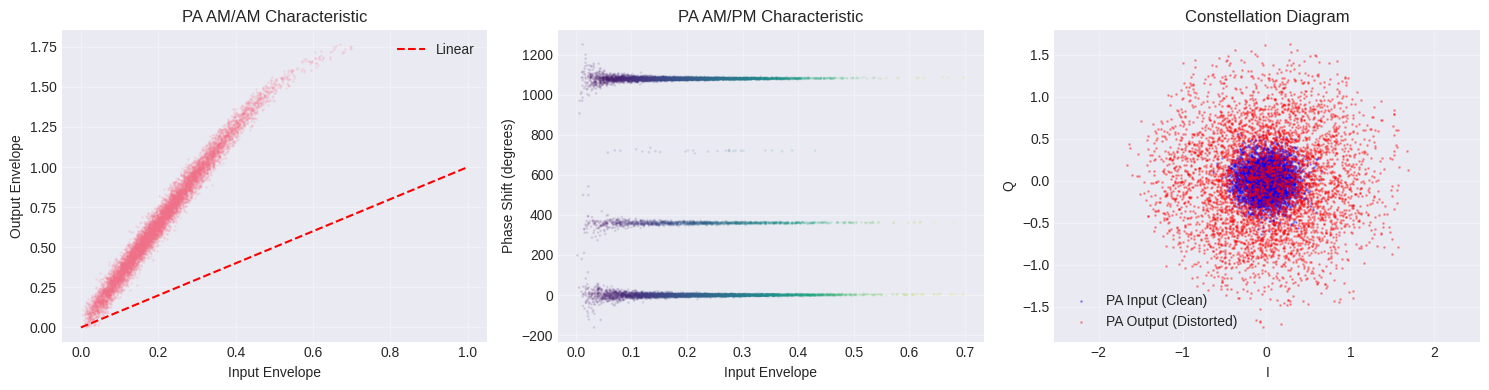


✅ Data loaded successfully!
   Training samples: 23,040
   Validation samples: 7,680


In [ ]:
# # Cell 5a: PA Distortion and IQ Signal Visualization

try:
    u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
    u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')

    # Quick visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # AM/AM characteristic
    env_in = np.abs(u_pa_train[:10000])
    env_out = np.abs(y_pa_train[:10000])
    axes[0].scatter(env_in, env_out, alpha=0.1, s=1)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Linear')
    axes[0].set_xlabel('Input Envelope')
    axes[0].set_ylabel('Output Envelope')
    axes[0].set_title('PA AM/AM Characteristic')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # AM/PM characteristic
    phase_in = np.angle(u_pa_train[:10000])
    phase_out = np.angle(y_pa_train[:10000])
    phase_diff = np.unwrap(phase_out - phase_in)
    axes[1].scatter(env_in, np.degrees(phase_diff), alpha=0.1, s=1, c=env_in, cmap='viridis')
    axes[1].set_xlabel('Input Envelope')
    axes[1].set_ylabel('Phase Shift (degrees)')
    axes[1].set_title('PA AM/PM Characteristic')
    axes[1].grid(True, alpha=0.3)

    # Constellation
    axes[2].scatter(u_pa_train[:5000].real, u_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
    axes[2].scatter(y_pa_train[:5000].real, y_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
    axes[2].set_xlabel('I')
    axes[2].set_ylabel('Q')
    axes[2].set_title('Constellation Diagram')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].axis('equal')

    plt.tight_layout()
    plt.savefig('figures/pa_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Data loaded successfully!")
    print(f"   Training samples: {len(u_pa_train):,}")
    print(f"   Validation samples: {len(u_pa_val):,}")

except FileNotFoundError as e:
    print(f"\n❌ {e}")
    print("\nℹ️ Please upload your OpenDPD data files to the 'data' directory!")

Computing spectral analysis with 10 subchannels...


/tmp/ipython-input-211/212086781.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power_linear = np.trapz(psd[mask], freqs[mask])


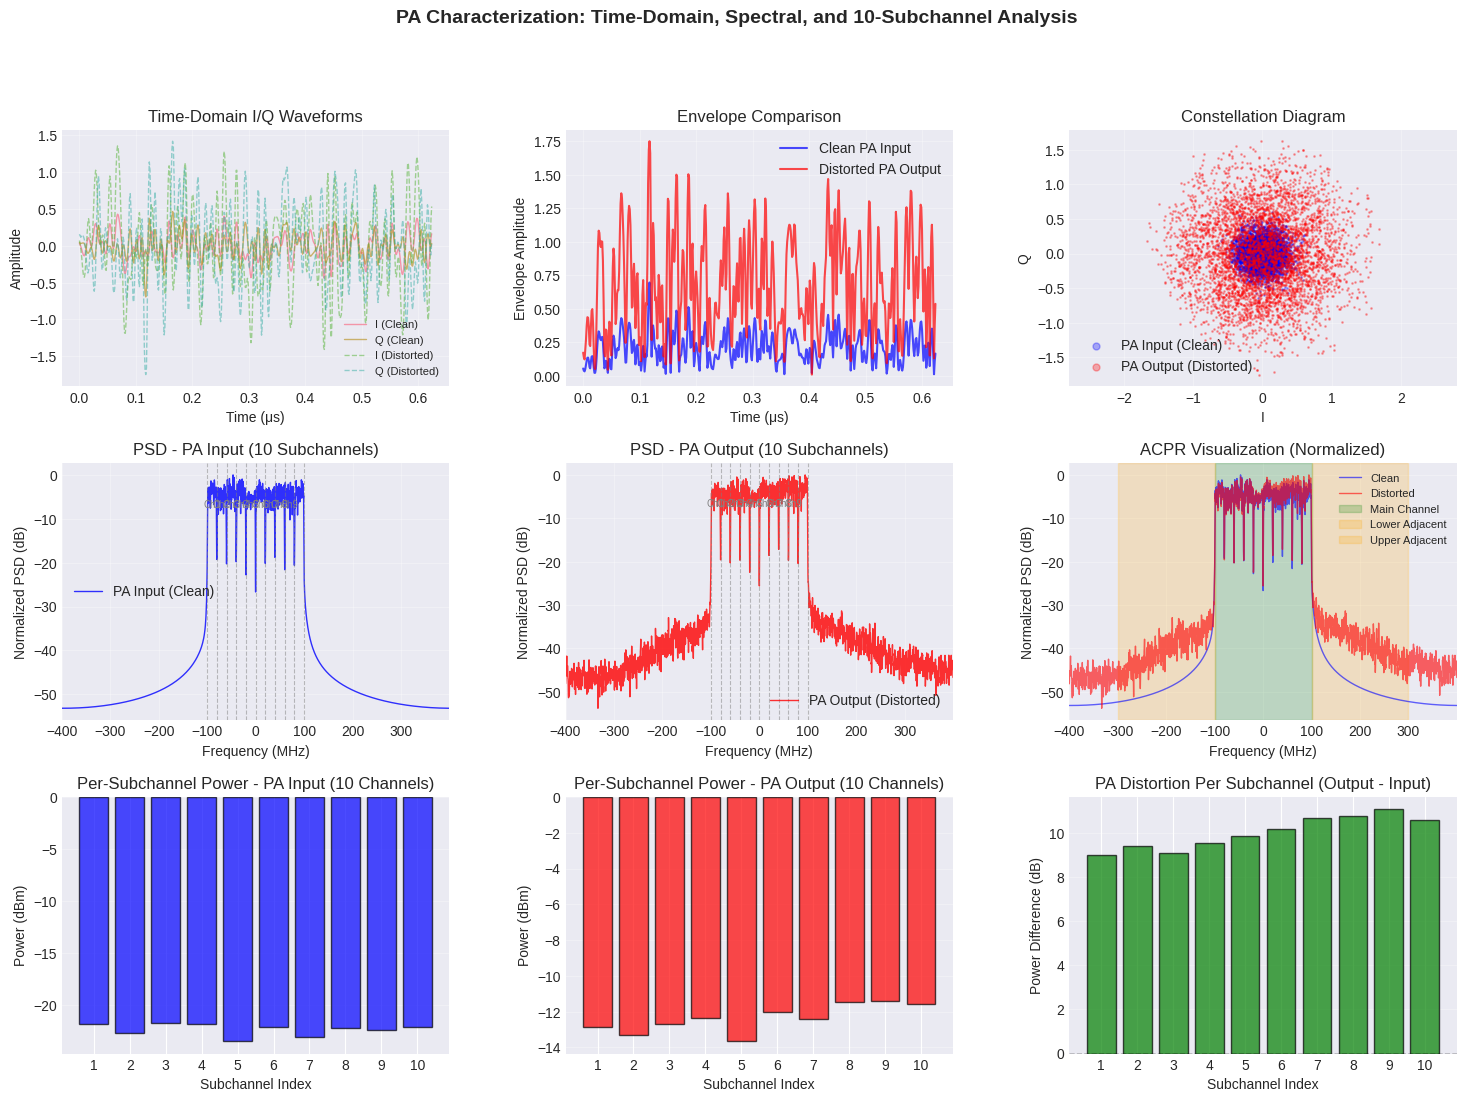


✅ Comprehensive visualization complete!
   Sample rate: 800 MSps
   Main channel BW: 200 MHz
   Subchannels: 10
   Subchannel BW: 20.0 MHz

   Mean power (Clean):     -22.37 dBm
   Mean power (Distorted): -12.37 dBm
   Power difference:       10.00 dB


In [30]:
# Cell 5b: Comprehensive Visualization - Time Domain, Spectral, and Per-Subchannel Analysis
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq, fftshift

def compute_psd_with_subchannels(signal_data, fs, nperseg=2560, n_sub_ch=10, bw_main_ch=200e6):
    """
    Compute PSD and identify subchannel boundaries.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        nperseg: FFT segment length
        n_sub_ch: Number of subchannels
        bw_main_ch: Main channel bandwidth (Hz)

    Returns:
        freqs: Frequency vector (Hz)
        psd_db: PSD in dBm/Hz
        subchannel_edges: List of (f_start, f_end) for each subchannel
    """
    # Compute PSD using Welch's method
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)

    # Shift to centered spectrum
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    # Convert to dBm/Hz (assuming 50 ohm impedance)
    psd_db = 10 * np.log10(psd + 1e-20)  # Add small value to avoid log(0)

    # Compute subchannel edges
    subchannel_bw = bw_main_ch / n_sub_ch
    f_start = -bw_main_ch / 2
    subchannel_edges = []
    for i in range(n_sub_ch):
        f_low = f_start + i * subchannel_bw
        f_high = f_low + subchannel_bw
        subchannel_edges.append((f_low, f_high))

    return freqs, psd_db, subchannel_edges

def compute_subchannel_power(signal_data, fs, subchannel_edges, nperseg=2560):
    """
    Compute power in each subchannel.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        subchannel_edges: List of (f_start, f_end) tuples
        nperseg: FFT segment length

    Returns:
        subchannel_powers: Array of power in dBm for each subchannel
    """
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    subchannel_powers = []
    for f_low, f_high in subchannel_edges:
        # Find indices within subchannel
        mask = (freqs >= f_low) & (freqs <= f_high)
        # Integrate PSD over subchannel bandwidth
        power_linear = np.trapz(psd[mask], freqs[mask])
        power_dbm = 10 * np.log10(power_linear + 1e-20)
        subchannel_powers.append(power_dbm)

    return np.array(subchannel_powers)

# Visualization parameters
fs = config['system']['sample_rate']  # 800e6 Hz
nperseg = config['spectral_loss']['nperseg']  # 2560
n_sub_ch = config['spectral_loss']['n_sub_ch']  # 10
bw_main_ch = config['spectral_loss']['bw_main_ch']  # 200e6 Hz

# Sample subset for visualization
n_samples = 10000
u_pa_vis = u_pa_train[:n_samples]
y_pa_vis = y_pa_train[:n_samples]

print("Computing spectral analysis with 10 subchannels...")

# Compute PSD and subchannel boundaries
freqs_clean, psd_clean, subchannel_edges = compute_psd_with_subchannels(
    u_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)
freqs_distorted, psd_distorted, _ = compute_psd_with_subchannels(
    y_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)

# Compute per-subchannel power
power_clean = compute_subchannel_power(u_pa_vis, fs, subchannel_edges, nperseg)
power_distorted = compute_subchannel_power(y_pa_vis, fs, subchannel_edges, nperseg)

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ===========================
# Row 1: Time-Domain Analysis
# ===========================

# Time-domain I/Q waveforms
ax1 = fig.add_subplot(gs[0, 0])
t_us = np.arange(500) / (fs / 1e6)  # First 500 samples in microseconds
ax1.plot(t_us, u_pa_vis[:500].real, label='I (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, u_pa_vis[:500].imag, label='Q (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, y_pa_vis[:500].real, label='I (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.plot(t_us, y_pa_vis[:500].imag, label='Q (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.set_xlabel('Time (μs)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Time-Domain I/Q Waveforms')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Envelope comparison
ax2 = fig.add_subplot(gs[0, 1])
env_clean = np.abs(u_pa_vis[:500])
env_distorted = np.abs(y_pa_vis[:500])
ax2.plot(t_us, env_clean, label='Clean PA Input', alpha=0.7, linewidth=1.5, color='blue')
ax2.plot(t_us, env_distorted, label='Distorted PA Output', alpha=0.7, linewidth=1.5, color='red')
ax2.set_xlabel('Time (μs)')
ax2.set_ylabel('Envelope Amplitude')
ax2.set_title('Envelope Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Constellation diagram
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(u_pa_vis[:5000].real, u_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
ax3.scatter(y_pa_vis[:5000].real, y_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
ax3.set_xlabel('I')
ax3.set_ylabel('Q')
ax3.set_title('Constellation Diagram')
ax3.legend(markerscale=5)
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# ===========================
# Row 2: Spectral Analysis with Subchannels
# ===========================

# Create normalized versions (0 dB peak)
psd_clean_norm = psd_clean - np.max(psd_clean)
psd_distorted_norm = psd_distorted - np.max(psd_distorted)

# PSD with subchannel boundaries (Clean)
ax4 = fig.add_subplot(gs[1, 0])
freqs_mhz = freqs_clean / 1e6
# CHANGE 1: Use psd_clean_norm instead of psd_clean
ax4.plot(freqs_mhz, psd_clean_norm, label='PA Input (Clean)', color='blue', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax4.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        # Dynamic text positioning will work fine with normalized data (0 - 10 = -10 dB)
        ax4.text((f_low + f_high) / 2 / 1e6, ax4.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax4.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax4.set_xlabel('Frequency (MHz)')
# CHANGE 2: Update label to 'Normalized PSD (dB)'
ax4.set_ylabel('Normalized PSD (dB)')
ax4.set_title(f'PSD - PA Input ({n_sub_ch} Subchannels)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD with subchannel boundaries (Distorted)
ax5 = fig.add_subplot(gs[1, 1])
# CHANGE 3: Use psd_distorted_norm instead of psd_distorted
ax5.plot(freqs_mhz, psd_distorted_norm, label='PA Output (Distorted)', color='red', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax5.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        ax5.text((f_low + f_high) / 2 / 1e6, ax5.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax5.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax5.set_xlabel('Frequency (MHz)')
# CHANGE 4: Update label
ax5.set_ylabel('Normalized PSD (dB)')
ax5.set_title(f'PSD - PA Output ({n_sub_ch} Subchannels)')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD Overlay for ACPR visualization
ax6 = fig.add_subplot(gs[1, 2])
# CHANGE 5 & 6: Use normalized versions for both
ax6.plot(freqs_mhz, psd_clean_norm, label='Clean', color='blue', linewidth=1, alpha=0.6)
ax6.plot(freqs_mhz, psd_distorted_norm, label='Distorted', color='red', linewidth=1, alpha=0.6)
# Highlight main channel and adjacent channels
main_ch_mask = (freqs_clean >= -bw_main_ch/2) & (freqs_clean <= bw_main_ch/2)
adj_lower_mask = (freqs_clean >= -3*bw_main_ch/2) & (freqs_clean < -bw_main_ch/2)
adj_upper_mask = (freqs_clean > bw_main_ch/2) & (freqs_clean <= 3*bw_main_ch/2)
ax6.axvspan(-bw_main_ch/2/1e6, bw_main_ch/2/1e6, alpha=0.2, color='green', label='Main Channel')
ax6.axvspan(-3*bw_main_ch/2/1e6, -bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Lower Adjacent')
ax6.axvspan(bw_main_ch/2/1e6, 3*bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Upper Adjacent')
ax6.set_xlabel('Frequency (MHz)')
ax6.set_ylabel('Normalized PSD (dB)')
ax6.set_title('ACPR Visualization (Normalized)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([freqs_mhz[0], freqs_mhz[-1]])
# Optional: Set Y-limit to focus on the top 80dB dynamic range
# ax6.set_ylim([-80, 5])

# ===========================
# Row 3: Per-Subchannel Analysis
# ===========================

# Per-subchannel power (Clean)
ax7 = fig.add_subplot(gs[2, 0])
subchannel_idx = np.arange(1, n_sub_ch + 1)
ax7.bar(subchannel_idx, power_clean, alpha=0.7, color='blue', edgecolor='black')
ax7.set_xlabel('Subchannel Index')
ax7.set_ylabel('Power (dBm)')
ax7.set_title(f'Per-Subchannel Power - PA Input ({n_sub_ch} Channels)')
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_xticks(subchannel_idx)

# Per-subchannel power (Distorted)
ax8 = fig.add_subplot(gs[2, 1])
ax8.bar(subchannel_idx, power_distorted, alpha=0.7, color='red', edgecolor='black')
ax8.set_xlabel('Subchannel Index')
ax8.set_ylabel('Power (dBm)')
ax8.set_title(f'Per-Subchannel Power - PA Output ({n_sub_ch} Channels)')
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_xticks(subchannel_idx)

# Per-subchannel power difference (Distortion)
ax9 = fig.add_subplot(gs[2, 2])
power_diff = power_distorted - power_clean
colors = ['green' if d > 0 else 'purple' for d in power_diff]
ax9.bar(subchannel_idx, power_diff, alpha=0.7, color=colors, edgecolor='black')
ax9.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax9.set_xlabel('Subchannel Index')
ax9.set_ylabel('Power Difference (dB)')
ax9.set_title(f'PA Distortion Per Subchannel (Output - Input)')
ax9.grid(True, alpha=0.3, axis='y')
ax9.set_xticks(subchannel_idx)

plt.suptitle(f'PA Characterization: Time-Domain, Spectral, and {n_sub_ch}-Subchannel Analysis',
             fontsize=14, fontweight='bold')

plt.savefig('figures/pa_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Comprehensive visualization complete!")
print(f"   Sample rate: {fs/1e6:.0f} MSps")
print(f"   Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"   Subchannels: {n_sub_ch}")
print(f"   Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"\n   Mean power (Clean):     {np.mean(power_clean):.2f} dBm")
print(f"   Mean power (Distorted): {np.mean(power_distorted):.2f} dBm")
print(f"   Power difference:       {np.mean(power_diff):.2f} dB")

Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...


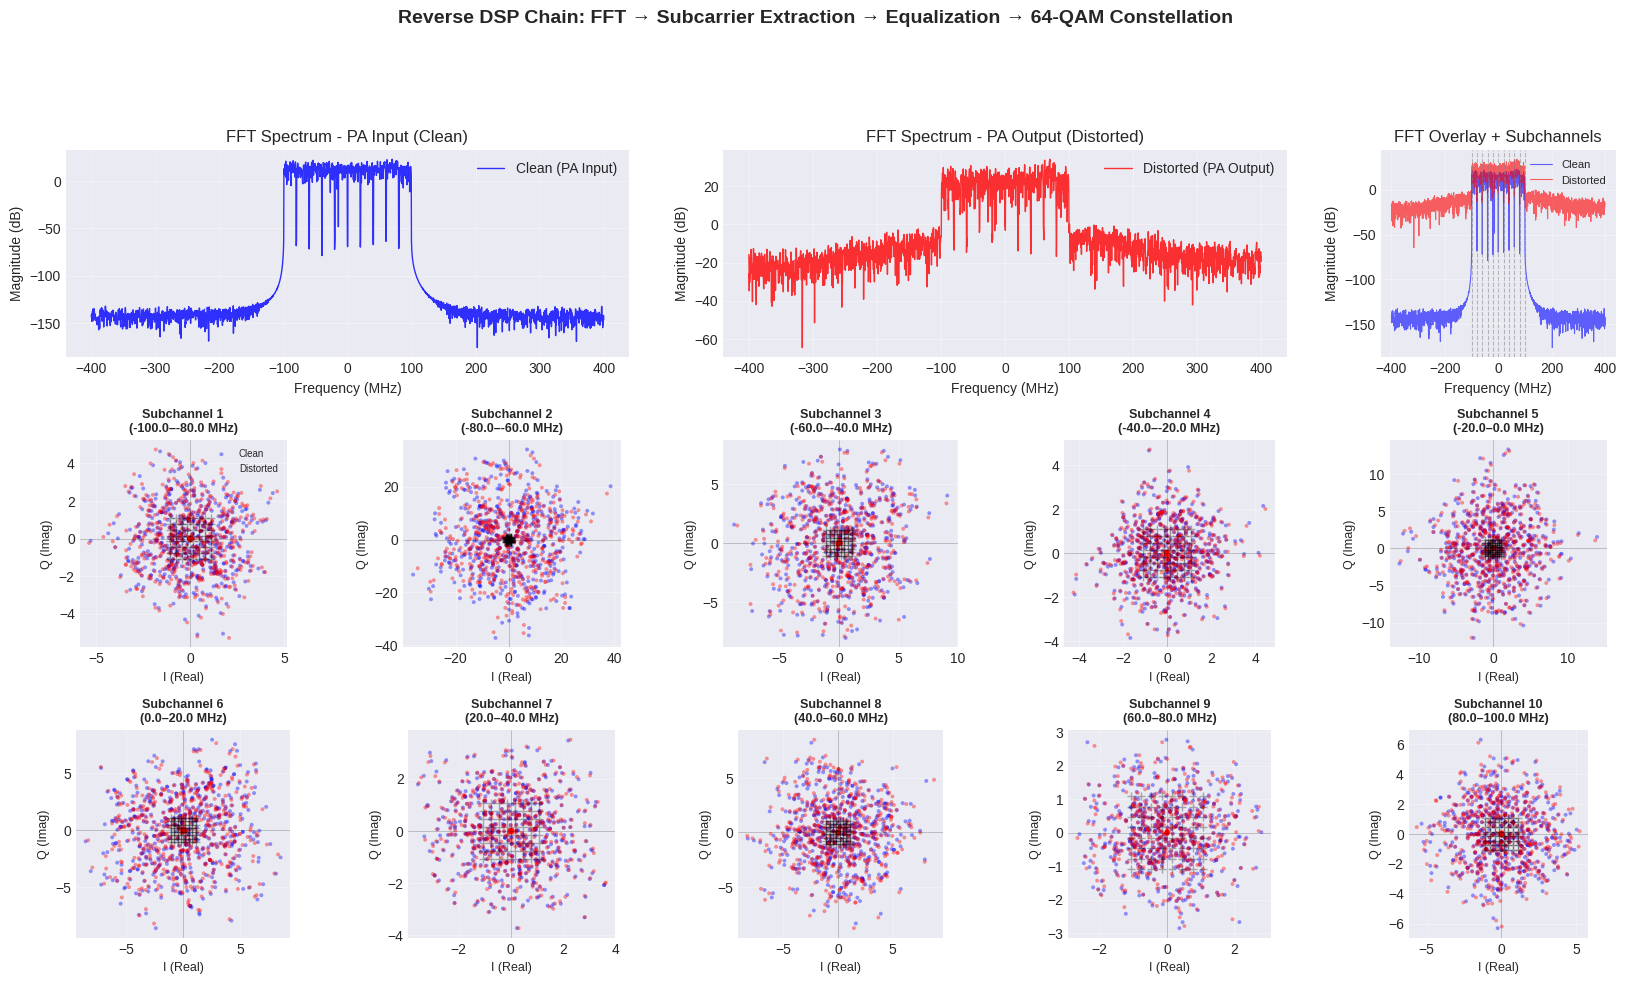


REVERSE DSP CHAIN ANALYSIS SUMMARY

FFT Configuration:
  Sample rate: 800 MSps
  FFT length: 2560 samples
  Main channel BW: 200 MHz
  Subchannel BW: 20.0 MHz
  Number of subchannels: 10

Equalization Method:
  Phase correction: Per-subchannel center frequency
  Amplitude normalization: Reference FFT bin magnitude

Per-Subchannel Equalized Constellation Statistics:
Channel    Clean (RMS)     Distorted (RMS)    EVM Increase   
------------------------------------------------------------
Ch 1       2.3146          2.3998              +3.68%
Ch 2       17.9544         17.2145             -4.12%
Ch 3       4.3583          4.2539              -2.39%
Ch 4       1.8576          1.8760              +0.99%
Ch 5       5.7010          5.6642              -0.64%
Ch 6       4.4928          4.3459              -3.27%
Ch 7       1.9216          1.9289              +0.38%
Ch 8       3.9718          4.1107              +3.50%
Ch 9       1.4511          1.4274              -1.64%
Ch 10      2.8084     

In [ ]:
# Cell 6c: Reverse DSP Chain - 64-QAM Constellation with FFT, Subcarrier Extraction, and Equalization
def reverse_dsp_chain(time_domain_signal, fs, bw_main_ch=200e6, n_sub_ch=10, nperseg=2560):
    """
    Perform reverse DSP chain to extract 64-QAM constellation:
    1. Time-domain samples
    2. FFT (Fast Fourier Transform)
    3. Subcarrier extraction (10 subchannels)
    4. Channel equalization (phase/amplitude correction)
    5. QAM constellation visualization

    Args:
        time_domain_signal: Complex time-domain baseband signal
        fs: Sample rate (Hz)
        bw_main_ch: Main channel bandwidth (Hz)
        n_sub_ch: Number of subchannels
        nperseg: FFT segment length

    Returns:
        freqs: Frequency vector (Hz)
        fft_result: FFT magnitude spectrum
        subcarrier_data: Dict of per-subchannel data
        equalized_constellations: Dict of equalized I/Q constellations
    """

    # ===========================
    # Step 1: Apply window and FFT
    # ===========================
    window = scipy_signal.windows.hann(nperseg)
    n_segments = len(time_domain_signal) // nperseg

    # Process multiple segments and average for better SNR
    fft_segments = []
    subcarrier_segments = {i: [] for i in range(n_sub_ch)}

    for seg_idx in range(min(n_segments, 10)):  # Use up to 10 segments for averaging
        start_idx = seg_idx * nperseg
        end_idx = start_idx + nperseg
        segment = time_domain_signal[start_idx:end_idx]

        # Apply window
        windowed = segment * window

        # Compute FFT
        fft_vals = np.fft.fftshift(np.fft.fft(windowed))
        fft_segments.append(fft_vals)

        # ===========================
        # Step 2: Extract subcarriers
        # ===========================
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2

        for ch_idx in range(n_sub_ch):
            f_low = f_start + ch_idx * subchannel_bw
            f_high = f_low + subchannel_bw

            # Find FFT bins in this subchannel
            mask = (freqs >= f_low) & (freqs < f_high)
            subcarrier_data = fft_vals[mask]
            subcarrier_segments[ch_idx].append(subcarrier_data)

    # Average across segments
    fft_avg = np.mean(fft_segments, axis=0)

    # ===========================
    # Step 3: Channel Equalization
    # ===========================
    equalized_constellations = {}

    for ch_idx in range(n_sub_ch):
        # Collect all subcarrier samples
        subchannel_samples = np.concatenate(subcarrier_segments[ch_idx])

        # Estimate channel response from magnitude spectrum
        # Use strongest FFT bins in this subchannel as reference
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2 + ch_idx * subchannel_bw
        f_mid = f_start + subchannel_bw / 2

        # Find bin closest to subchannel center
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        center_bin = np.argmin(np.abs(freqs - f_mid))

        # Estimate phase from the strongest bin (channel phase rotation)
        ref_phase = np.angle(fft_avg[center_bin])
        ref_mag = np.abs(fft_avg[center_bin])

        # Equalize: correct phase rotation and normalize amplitude
        # Phase equalization: rotate by -ref_phase
        phase_corrected = subchannel_samples * np.exp(-1j * ref_phase)

        # Amplitude normalization: scale by reference magnitude
        if ref_mag > 0:
            equalized = phase_corrected / ref_mag
        else:
            equalized = phase_corrected

        equalized_constellations[ch_idx] = equalized

    return freqs, fft_avg, subcarrier_segments, equalized_constellations

# ===========================
# Generate 64-QAM Visualization
# ===========================

print("Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...")

# Use training data for visualization
n_samples_dsp = min(50000, len(u_pa_train))
u_pa_dsp = u_pa_train[:n_samples_dsp]
y_pa_dsp = y_pa_train[:n_samples_dsp]

# Perform reverse DSP chain
freqs_vec, fft_clean, subcarriers_clean, eq_constellations_clean = reverse_dsp_chain(
    u_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)
freqs_vec, fft_distorted, subcarriers_distorted, eq_constellations_distorted = reverse_dsp_chain(
    y_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)

# ===========================
# Create Visualization
# ===========================
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 5, hspace=0.4, wspace=0.4)

# ===========================
# Row 1: FFT and Spectrum
# ===========================

# Full FFT spectrum (Clean)
ax0 = fig.add_subplot(gs[0, :2])
freqs_mhz_dsp = freqs_vec / 1e6
fft_mag_clean = 20 * np.log10(np.abs(fft_clean) + 1e-20)
ax0.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=1, alpha=0.8, label='Clean (PA Input)')
ax0.set_xlabel('Frequency (MHz)')
ax0.set_ylabel('Magnitude (dB)')
ax0.set_title('FFT Spectrum - PA Input (Clean)')
ax0.grid(True, alpha=0.3)
ax0.legend()

# Full FFT spectrum (Distorted)
ax1 = fig.add_subplot(gs[0, 2:4])
fft_mag_distorted = 20 * np.log10(np.abs(fft_distorted) + 1e-20)
ax1.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=1, alpha=0.8, label='Distorted (PA Output)')
ax1.set_xlabel('Frequency (MHz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('FFT Spectrum - PA Output (Distorted)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# FFT Overlay with subchannel markers
ax2 = fig.add_subplot(gs[0, 4])
ax2.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=0.8, alpha=0.6, label='Clean')
ax2.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=0.8, alpha=0.6, label='Distorted')

# Mark subchannel boundaries
subchannel_bw = bw_main_ch / n_sub_ch
f_start = -bw_main_ch / 2
for i in range(n_sub_ch + 1):
    f_edge = f_start + i * subchannel_bw
    ax2.axvline(x=f_edge/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Magnitude (dB)')
ax2.set_title('FFT Overlay + Subchannels')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

# ===========================
# Rows 2-4: Per-Subchannel 64-QAM Constellations
# ===========================

# Layout: 10 subchannels in 2 rows × 5 columns
for ch_idx in range(n_sub_ch):
    row = 1 + (ch_idx // 5)
    col = ch_idx % 5
    ax = fig.add_subplot(gs[row, col])

    # Extract equalized constellation for this subchannel
    eq_const_clean = eq_constellations_clean[ch_idx]
    eq_const_distorted = eq_constellations_distorted[ch_idx]

    # Sample for visualization (to avoid overcrowding)
    sample_idx = np.random.choice(len(eq_const_clean), min(1000, len(eq_const_clean)), replace=False)

    # Plot clean constellation
    ax.scatter(eq_const_clean[sample_idx].real, eq_const_clean[sample_idx].imag,
              alpha=0.4, s=8, c='blue', label='Clean', edgecolors='none')

    # Plot distorted constellation
    ax.scatter(eq_const_distorted[sample_idx].real, eq_const_distorted[sample_idx].imag,
              alpha=0.4, s=8, c='red', label='Distorted', edgecolors='none')

    # Add reference 64-QAM grid (ideal points)
    qam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7]) / np.sqrt(42)  # Normalized 64-QAM
    for i_val in qam_levels:
        for q_val in qam_levels:
            ax.plot(i_val, q_val, 'k+', markersize=6, alpha=0.3)

    # Formatting
    ax.set_xlabel('I (Real)', fontsize=9)
    ax.set_ylabel('Q (Imag)', fontsize=9)
    ax.set_title(f'Subchannel {ch_idx+1}\n({f_start/1e6 + ch_idx*subchannel_bw/1e6:.1f}–{f_start/1e6 + (ch_idx+1)*subchannel_bw/1e6:.1f} MHz)',
                fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

    if ch_idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Reverse DSP Chain: FFT → Subcarrier Extraction → Equalization → 64-QAM Constellation',
             fontsize=14, fontweight='bold')

plt.savefig('figures/qam_constellation_reverse_dsp.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================
# Statistics Summary
# ===========================
print(f"\n{'='*80}")
print(f"REVERSE DSP CHAIN ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"\nFFT Configuration:")
print(f"  Sample rate: {fs/1e6:.0f} MSps")
print(f"  FFT length: {nperseg} samples")
print(f"  Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"  Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"  Number of subchannels: {n_sub_ch}")

print(f"\nEqualization Method:")
print(f"  Phase correction: Per-subchannel center frequency")
print(f"  Amplitude normalization: Reference FFT bin magnitude")

print(f"\nPer-Subchannel Equalized Constellation Statistics:")
print(f"{'Channel':<10} {'Clean (RMS)':<15} {'Distorted (RMS)':<18} {'EVM Increase':<15}")
print(f"{'-'*60}")

for ch_idx in range(n_sub_ch):
    eq_clean = eq_constellations_clean[ch_idx]
    eq_dist = eq_constellations_distorted[ch_idx]

    # RMS (quality metric)
    rms_clean = np.sqrt(np.mean(np.abs(eq_clean)**2))
    rms_dist = np.sqrt(np.mean(np.abs(eq_dist)**2))

    # EVM-like metric (normalized error)
    avg_clean = np.mean(np.abs(eq_clean))
    evm_increase = (np.std(eq_dist) / np.std(eq_clean) - 1) * 100 if np.std(eq_clean) > 0 else 0

    print(f"Ch {ch_idx+1:<7} {rms_clean:<15.4f} {rms_dist:<18.4f} {evm_increase:>+6.2f}%")

print(f"\n{'='*80}")
print(f"✅ Reverse DSP chain complete!")
print(f"   FFT bins extracted and analyzed")
print(f"   Phase rotation equalized per subchannel")
print(f"   64-QAM constellations visualized for all {n_sub_ch} subchannels")
print(f"{'='*80}")

In [9]:
# Cell 6: Model Creation (matches train.py)
# Generator: Phase-Normalized TDNN (24-dim input, 1,362 params)
generator = create_pn_tdnn_generator(memory_depth=config['model']['generator']['memory_depth'])
generator = generator.to(device)

# Discriminator: Conditional WGAN-GP (4-dim input)
discriminator = create_discriminator()
discriminator = discriminator.to(device)

# Verify architecture
g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())

print("Model Architecture Verification:")
print(f"  Generator:")
print(f"    Input dim: {generator.input_dim} (expected: 24)")
print(f"    Memory depth: M={generator.memory_depth} (expected: 3)")
print(f"    Hidden dims: {generator.hidden_dims}")
print(f"    Parameters: {g_params:,} (expected: 1,362)")
print(f"  Discriminator:")
print(f"    Parameters: {d_params:,}")

# Verify parameter count
assert g_params == 1362, f"Generator param count mismatch: {g_params} != 1362"
print("\n✓ Architecture verified!")

Model Architecture Verification:
  Generator:
    Input dim: 24 (expected: 24)
    Memory depth: M=3 (expected: 3)
    Hidden dims: [32, 16]
    Parameters: 1,362 (expected: 1,362)
  Discriminator:
    Parameters: 2,433

✓ Architecture verified!


In [10]:
# Cell 7: Optimizers and Schedulers (matches train.py)
opt_config = config['training']['optimizer']

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=opt_config['lr_generator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=opt_config['lr_discriminator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss
spectral_loss_fn = SpectralLoss(
    sample_rate=config['system']['sample_rate'],
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    nperseg=config['spectral_loss']['nperseg'],
    l1_weight=50.0,        # Unchanged (main loss)
    power_weight=10.0,     # Power regularization (reduced from old acpr_weight)
    nmse_weight=10.0,      # NEW: Differentiable NMSE loss
    a3_mse_weight=5.0,      # NEW: A³-MSE (ACLR surrogate) - start at 5.0
)

print("Spectral Loss initialized:")
print(f"  L1 weight: {spectral_loss_fn.l1_weight}")
print(f"  Power weight: {spectral_loss_fn.power_weight}")
print(f"  NMSE weight: {spectral_loss_fn.nmse_weight}")
print(f"  A³-MSE weight: {spectral_loss_fn.a3_mse_weight}")  # NEW

print("Optimizers created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")

Spectral Loss initialized:
  L1 weight: 50.0
  Power weight: 10.0
  NMSE weight: 10.0
  A³-MSE weight: 5.0
Optimizers created:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Betas: [0.0, 0.9]
  Scheduler: Cosine annealing to 1e-06


In [11]:
# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss with dpa_200mhz parameters
spectral_loss_fn = SpectralLoss(
    sample_rate=config['system']['sample_rate'],              # 800e6
    bw_main_ch=config['spectral_loss']['bw_main_ch'],        # 200e6
    n_sub_ch=config['spectral_loss']['n_sub_ch'],            # 10 (KEY CHANGE)
    nperseg=config['spectral_loss']['nperseg'],              # 2560
)

print("Optimizers and Loss Functions created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")
print(f"  SpectralLoss:")
print(f"    Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"    Main channel BW: {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz")
print(f"    Sub-channels: {config['spectral_loss']['n_sub_ch']}")

Optimizers and Loss Functions created:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Betas: [0.0, 0.9]
  Scheduler: Cosine annealing to 1e-06
  SpectralLoss:
    Sample rate: 800 MSps
    Main channel BW: 200 MHz
    Sub-channels: 10


In [12]:
def train_step(
    generator: nn.Module,
    discriminator: nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor],
    g_optimizer: optim.Optimizer,
    d_optimizer: optim.Optimizer,
    spectral_loss: SpectralLoss,
    config: dict,
    device: torch.device,
    step: int
) -> Dict[str, float]:
    """
    Single training step using Indirect Learning Architecture (ILA).

    In ILA:
    - Input: PA output (distorted signal y_PA)
    - Generator produces: Predistorted signal (should match clean PA input u_PA)
    - Target: PA input (clean signal u_PA)

    NO PA model in training loop - we train on measured data!

    Returns dictionary of loss values.
    """
    train_config = config['training']
    loss_config = train_config.get('loss', {})
    n_critic = train_config.get('n_critic', 5)
    gp_weight = train_config.get('gp_weight', 10.0)

    # Unpack batch
    input_seq, target = batch  # [B, M+1, 2], [B, 2]
    input_seq = input_seq.to(device)
    target = target.to(device)

    losses = {}

    # ===================
    # Train Discriminator
    # ===================
    for _ in range(n_critic):
        d_optimizer.zero_grad()

        # Generate DPD output (detach to prevent gradient flow)
        with torch.no_grad():
            dpd_output = generator(input_seq)  # [B, seq_len, 2]
            # Squeeze to [B, 2] if needed
            if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
                dpd_output = dpd_output.squeeze(1)

        # Discriminator loss components
        # Real: clean PA input (what DPD should produce)
        # Fake: DPD output (what DPD actually produces)
        # Condition: Current PA output sample (what DPD saw)
        condition = input_seq[:, -1, :]  # [B, 2] - most recent sample

        # Critic scores
        d_real = discriminator(target, condition)  # [B, 1]
        d_fake = discriminator(dpd_output.detach(), condition)  # [B, 1]

        # Wasserstein loss: maximize D(real) - D(fake)
        d_loss = d_fake.mean() - d_real.mean()

        # Gradient penalty: enforce 1-Lipschitz constraint
        batch_size = target.size(0)
        alpha = torch.rand(batch_size, 1, device=device)
        interpolates = alpha * target + (1 - alpha) * dpd_output.detach()
        interpolates.requires_grad_(True)

        d_interp = discriminator(interpolates, condition)

        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients_norm = gradients.view(batch_size, -1).norm(2, dim=1)
        gp = ((gradients_norm - 1) ** 2).mean()

        d_total = d_loss + gp_weight * gp
        d_total.backward()
        d_optimizer.step()

    losses['d_wasserstein'] = d_loss.item()
    losses['d_gp'] = gp.item()
    losses['d_total'] = d_total.item()

    # =================
    # Train Generator
    # =================
    g_optimizer.zero_grad()

    # Generate DPD output
    dpd_output = generator(input_seq)  # [B, seq_len - M, 2] → [B, 1, 2] for M=3

    # Squeeze to [B, 2] for all downstream uses
    if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
        dpd_output = dpd_output.squeeze(1)  # Now [B, 2]

    # Now use dpd_output everywhere else - it's always [B, 2]
    condition = input_seq[:, -1, :]  # [B, 2]

    # Reconstruction loss (L1: DPD output should match PA input)
    recon_loss = nn.functional.l1_loss(dpd_output, target)

    # Discriminator loss
    d_fake = discriminator(dpd_output, condition)  # [B, 1]
    g_adv_loss = -d_fake.mean()

    # Spectral loss
    spectral, spectral_components = spectral_loss(dpd_output, target, return_components=True)

    # Combined generator loss with weighted components
    g_total = (
        loss_config.get('adversarial', 1.0) * g_adv_loss +
        loss_config.get('reconstruction_l1', 40.0) * recon_loss +
        loss_config.get('spectral', 10.0) * spectral
    )

    g_total.backward()
    g_optimizer.step()

    losses['g_adv'] = g_adv_loss.item()
    losses['g_recon'] = recon_loss.item()
    losses['g_spectral'] = spectral.item()
    losses['g_total'] = g_total.item()
    losses.update({f'g_{k}': v.item() for k, v in spectral_components.items()})

    return losses

In [13]:
# Cell 9: UPDATED Validation Function with Sequence Aggregation
def validate(generator, val_loader, spectral_loss_fn, device):
    """
    Validate model on validation set with sequence aggregation for spectral metrics.

    Strategy:
    - Aggregate ALL validation outputs into long sequences
    - Compute EVM/ACLR on aggregated sequences (requires long data for FFT/Welch)
    - Compute NMSE per-batch and average (works on short sequences)
    """
    generator.eval()

    # Collect all predictions and targets for aggregation
    all_predictions = []
    all_targets = []
    all_nmse = []
    all_l1 = []

    with torch.no_grad():
        for input_seq, target in val_loader:
            input_seq = input_seq.to(device)
            target = target.to(device)

            # Generate predictions
            dpd_output = generator(input_seq)

            # Squeeze if needed
            if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
                dpd_output = dpd_output.squeeze(1)

            # Store for aggregation
            all_predictions.append(dpd_output.cpu())
            all_targets.append(target.cpu())

            # Compute NMSE per batch (works on any length)
            try:
                nmse = compute_nmse_differentiable(dpd_output, target, return_db=True)
                all_nmse.append(nmse.item())
            except:
                all_nmse.append(-50.0)

            # Compute L1 error
            l1_error = torch.nn.functional.l1_loss(dpd_output, target)
            all_l1.append(l1_error.item())

    # Aggregate all predictions and targets
    all_predictions_cat = torch.cat(all_predictions, dim=0)  # [total_samples, 2]
    all_targets_cat = torch.cat(all_targets, dim=0)          # [total_samples, 2]

    # Convert to numpy for spectral metrics
    pred_np = all_predictions_cat.numpy()  # [N, 2]
    target_np = all_targets_cat.numpy()    # [N, 2]

    # Reshape to [1, N, 2] for spectral metric functions (they expect [batch, seq, 2])
    pred_np = pred_np.reshape(1, -1, 2)
    target_np = target_np.reshape(1, -1, 2)

    print(f"  [Validation] Aggregated {pred_np.shape[1]} samples for spectral metrics")

    # Compute EVM on aggregated sequence
    try:
        evm_db = compute_evm(
            pred_np, target_np,
            sample_rate=spectral_loss_fn.sample_rate,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            nperseg=spectral_loss_fn.nperseg,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: EVM computation failed: {e}")
        evm_db = -50.0

    # Compute ACLR on aggregated sequence
    try:
        aclr_l, aclr_r = compute_aclr(
            pred_np,
            sample_rate=spectral_loss_fn.sample_rate,
            nperseg=spectral_loss_fn.nperseg,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: ACLR computation failed: {e}")
        aclr_l = -50.0
        aclr_r = -50.0

    generator.train()

    return {
        'val_evm_db': evm_db,
        'val_nmse_db': np.mean(all_nmse),
        'val_aclr_lower_db': aclr_l,
        'val_aclr_upper_db': aclr_r,
        'val_l1': np.mean(all_l1)
    }

print("Validation function defined (with sequence aggregation)")

Validation function defined (with sequence aggregation)


In [14]:
# Cell 9b (ENHANCED): Checkpoint Management with Error Handling & Memory Optimization

def save_checkpoint(checkpoint_dir, epoch, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, history, best_evm, best_state, early_stopping_counter,
                   early_stopping_best_value, qat_enabled, config, verbose=True):
    """
    Save training checkpoint for resumption with error handling and cleanup.

    Args:
        checkpoint_dir: Directory to save checkpoint
        epoch: Current epoch number
        generator: Generator model
        discriminator: Discriminator model
        g_optimizer, d_optimizer: Optimizers
        g_scheduler, d_scheduler: Learning rate schedulers
        history: Training history dict
        best_evm: Best EVM achieved
        best_state: Best model state dict
        early_stopping_counter: ES counter
        early_stopping_best_value: Best value for ES
        qat_enabled: Whether QAT is enabled
        config: Config dict
        verbose: Print status messages

    Returns:
        checkpoint_path: Path to saved checkpoint
    """
    try:
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

        checkpoint = {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'g_scheduler_state_dict': g_scheduler.state_dict(),
            'd_scheduler_state_dict': d_scheduler.state_dict(),
            'history': history,
            'best_evm': best_evm,
            'best_state': best_state,
            'early_stopping_counter': early_stopping_counter,
            'early_stopping_best_value': early_stopping_best_value,
            'qat_enabled': qat_enabled,
            'config': config,
            'timestamp': datetime.now().isoformat(),
        }

        # Save epoch checkpoint
        checkpoint_path = checkpoint_dir / f'checkpoint_epoch_{epoch:03d}.pth'
        torch.save(checkpoint, checkpoint_path)

        # Save as 'latest' for easy resumption
        latest_path = checkpoint_dir / 'checkpoint_latest.pth'
        torch.save(checkpoint, latest_path)

        if verbose:
            checkpoint_size_mb = checkpoint_path.stat().st_size / (1024 * 1024)
            print(f"✓ Checkpoint saved: {checkpoint_path.name} ({checkpoint_size_mb:.1f} MB)")

        # Cleanup: Keep only last 3 checkpoints to save disk space
        checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
        if len(checkpoints) > 3:
            for old_cp in checkpoints[:-3]:
                try:
                    old_cp.unlink()  # Delete file
                    if verbose:
                        print(f"  Cleaned up: {old_cp.name}")
                except Exception as e:
                    if verbose:
                        print(f"  Warning: Could not delete {old_cp.name}: {e}")

        return checkpoint_path

    except Exception as e:
        print(f"❌ ERROR: Failed to save checkpoint at epoch {epoch}: {e}")
        raise


def load_checkpoint(checkpoint_path, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, device):
    """
    Load checkpoint and resume training with validation.

    Args:
        checkpoint_path: Path to checkpoint file
        generator, discriminator: Models to load into
        g_optimizer, d_optimizer: Optimizers to restore
        g_scheduler, d_scheduler: Schedulers to restore
        device: Device (cuda/cpu)

    Returns:
        Tuple of (history, best_evm, best_state, early_stopping_counter,
                  early_stopping_best_value, qat_enabled, resume_epoch)
    """
    try:
        print(f"Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)

        # Validate checkpoint contents
        required_keys = [
            'generator_state_dict', 'discriminator_state_dict',
            'g_optimizer_state_dict', 'd_optimizer_state_dict',
            'g_scheduler_state_dict', 'd_scheduler_state_dict',
            'history', 'best_evm', 'best_state'
        ]
        for key in required_keys:
            if key not in checkpoint:
                raise KeyError(f"Missing required key in checkpoint: {key}")

        # Load model and optimizer states
        generator.load_state_dict(checkpoint['generator_state_dict'])
        discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
        d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
        g_scheduler.load_state_dict(checkpoint['g_scheduler_state_dict'])
        d_scheduler.load_state_dict(checkpoint['d_scheduler_state_dict'])

        # Restore training state
        history = checkpoint['history']
        best_evm = checkpoint['best_evm']
        best_state = checkpoint['best_state']
        early_stopping_counter = checkpoint.get('early_stopping_counter', 0)
        early_stopping_best_value = checkpoint.get('early_stopping_best_value', float('inf'))
        qat_enabled = checkpoint.get('qat_enabled', False)
        resume_epoch = checkpoint['epoch']

        # Get checkpoint timestamp if available
        timestamp = checkpoint.get('timestamp', 'unknown')

        print(f"\n✓ Checkpoint loaded successfully!")
        print(f"  Saved at: {timestamp}")
        print(f"  Resuming from epoch: {resume_epoch + 1}")
        print(f"  Best EVM so far: {best_evm:.2f} dB")
        print(f"  QAT status: {'Enabled' if qat_enabled else 'Disabled'}")
        print(f"  Early stopping counter: {early_stopping_counter}/25")
        print(f"  Training epochs completed: {len(history['g_total'])}")

        return history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, resume_epoch

    except FileNotFoundError:
        print(f"❌ ERROR: Checkpoint file not found: {checkpoint_path}")
        raise
    except Exception as e:
        print(f"❌ ERROR: Failed to load checkpoint: {e}")
        raise


def cleanup_checkpoint_memory():
    """
    Clear GPU memory after checkpoint operations.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_checkpoint_status(checkpoint_dir):
    """
    Get status of all checkpoints in directory.

    Returns:
        Dict with checkpoint information
    """
    checkpoint_dir = Path(checkpoint_dir)

    if not checkpoint_dir.exists():
        return {
            'exists': False,
            'count': 0,
            'latest': None,
            'checkpoints': []
        }

    checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
    latest = checkpoint_dir / 'checkpoint_latest.pth'

    checkpoint_info = []
    for cp in checkpoints:
        size_mb = cp.stat().st_size / (1024 * 1024)
        epoch = int(cp.stem.split('_')[-1])
        checkpoint_info.append({
            'path': cp,
            'epoch': epoch,
            'size_mb': size_mb,
            'name': cp.name
        })

    return {
        'exists': latest.exists(),
        'count': len(checkpoints),
        'latest': latest if latest.exists() else None,
        'checkpoints': checkpoint_info
    }


print("✓ Checkpoint management functions defined (enhanced)")

✓ Checkpoint management functions defined (enhanced)


In [ ]:
# Cell 10: Training Loop with QAT Transition, Early Stopping, and Checkpoint Resumption
# Cell 10 (ENHANCED): Training Loop with Checkpointing & Auto-Resume

# ===== CHECKPOINT CONFIGURATION =====
checkpoint_dir = Path('checkpoints/training')
resume_checkpoint = checkpoint_dir / 'checkpoint_latest.pth'

# Auto-detect checkpoint (set to False to start fresh)
RESUME_FROM_CHECKPOINT = resume_checkpoint.exists()

# OVERRIDE: Force specific behavior
# RESUME_FROM_CHECKPOINT = True   # Uncomment to force resume
# RESUME_FROM_CHECKPOINT = False  # Uncomment to force fresh start

print("="*70)
print("CHECKPOINT & RESUMPTION CONFIGURATION")
print("="*70)

# Show checkpoint status
cp_status = get_checkpoint_status(checkpoint_dir)
print(f"\nCheckpoint Directory: {checkpoint_dir}")
print(f"Checkpoints exist: {cp_status['exists']}")
print(f"Checkpoint count: {cp_status['count']}")

if cp_status['checkpoints']:
    print(f"\nRecent checkpoints:")
    for cp_info in cp_status['checkpoints'][-3:]:  # Show last 3
        print(f"  Epoch {cp_info['epoch']:3d}: {cp_info['name']} ({cp_info['size_mb']:.1f} MB)")

print(f"\nResume mode: {'AUTO-RESUME' if RESUME_FROM_CHECKPOINT else 'FRESH START'}")
print("="*70)

# Setup TensorBoard logging
if RESUME_FROM_CHECKPOINT:
    run_name = f"pn_tdnn_dpa200mhz_resumed_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
else:
    run_name = f"pn_tdnn_dpa200mhz_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

tensorboard_dir = Path('runs') / run_name
tensorboard_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(str(tensorboard_dir))

print(f"\nTensorBoard logs: {tensorboard_dir}")
print(f"View with: tensorboard --logdir=runs/")

# Initialize or load training state
if RESUME_FROM_CHECKPOINT:
    print("\n" + "="*70)
    print("RESUMING FROM CHECKPOINT")
    print("="*70)
    try:
        history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, start_epoch = load_checkpoint(
            resume_checkpoint, generator, discriminator, g_optimizer, d_optimizer, g_scheduler, d_scheduler, device
        )
        start_epoch += 1  # Start from next epoch
        cleanup_checkpoint_memory()

        print(f"\n✓ Ready to resume training from epoch {start_epoch + 1}")

    except Exception as e:
        print(f"\n❌ Failed to load checkpoint: {e}")
        print("Starting fresh training instead...")
        RESUME_FROM_CHECKPOINT = False
else:
    print("\nStarting fresh training")

# Only initialize fresh if not resuming
if not RESUME_FROM_CHECKPOINT:
    history = {
        'g_total': [], 'd_total': [], 'g_adv': [], 'g_recon': [], 'g_spectral': [],
        'val_evm_db': [], 'val_nmse_db': [], 'val_aclr_lower_db': [], 'val_aclr_upper_db': [], 'val_l1': [], 'lr': []
    }
    best_evm = float('inf')
    best_state = None
    early_stopping_counter = 0
    early_stopping_best_value = float('inf')
    qat_enabled = False
    start_epoch = 0

# Early stopping configuration
es_config = config['early_stopping']
early_stopping_enabled = es_config['enabled']
early_stopping_patience = es_config['patience']
early_stopping_monitor = es_config['monitor']
early_stopping_min_delta = es_config['min_delta']
early_stopped = False

# QAT configuration
qat_start_epoch = config['qat']['start_epoch']

print(f"\nTraining Configuration:")
print(f"  Starting epoch: {start_epoch + 1}/{num_epochs}")
print(f"  QAT enabled at epoch: {qat_start_epoch}")
print(f"  Early stopping: {'ON' if early_stopping_enabled else 'OFF'} (patience={early_stopping_patience})")
print(f"  Checkpoint interval: {config['logging'].get('checkpoint_interval', 25)} epochs")
print("="*70)

# ===== MAIN TRAINING LOOP =====
for epoch in range(start_epoch, num_epochs):
    if early_stopped:
        print(f"\n{'='*70}")
        print(f"EARLY STOPPING TRIGGERED")
        print(f"  No improvement for {early_stopping_patience} epochs")
        print(f"  Best {early_stopping_monitor}: {early_stopping_best_value:.4f}")
        print(f"{'='*70}")
        break

    generator.train()
    discriminator.train()

    # ==================
    # QAT Transition
    # ==================
    if epoch == qat_start_epoch and config['qat']['enabled'] and not qat_enabled:
        generator.enable_qat()
        qat_enabled = True
        print(f"\n{'='*70}")
        print(f"QAT ENABLED at epoch {epoch + 1}")
        print(f"  Weight quantization: Q1.15 ({config['qat']['weight_bits']} bits)")
        print(f"  Activation quantization: Q8.8 ({config['qat']['activation_bits']} bits)")
        print(f"{'='*70}\n")

    # ==================
    # Training epoch
    # ==================
    epoch_losses = {}
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [{"QAT" if qat_enabled else "FP32"}]')

    for batch_idx, batch in enumerate(pbar):
        global_step = epoch * len(train_loader) + batch_idx
        losses = train_step(
            generator, discriminator, batch,
            g_optimizer, d_optimizer, spectral_loss_fn,
            config, device, global_step
        )

        for k, v in losses.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v

        # TensorBoard logging per batch
        writer.add_scalar('Train/Generator/Total', losses['g_total'], global_step)
        writer.add_scalar('Train/Generator/Adversarial', losses['g_adv'], global_step)
        writer.add_scalar('Train/Generator/Reconstruction', losses['g_recon'], global_step)
        writer.add_scalar('Train/Generator/Spectral', losses['g_spectral'], global_step)
        writer.add_scalar('Train/Discriminator/Wasserstein', losses['d_wasserstein'], global_step)
        writer.add_scalar('Train/Discriminator/GradientPenalty', losses['d_gp'], global_step)
        writer.add_scalar('Train/Discriminator/Total', losses['d_total'], global_step)

        pbar.set_postfix({
            'g': f"{losses['g_total']:.4f}",
            'd': f"{losses['d_total']:.4f}",
            'QAT': 'ON' if qat_enabled else 'OFF',
        })

    # Average epoch losses
    for k in epoch_losses:
        epoch_losses[k] /= len(train_loader)

    # ==================
    # Validation
    # ==================
    val_metrics = validate(generator, val_loader, spectral_loss_fn, device)

    # Update history
    for k in ['g_total', 'd_total', 'g_adv', 'g_recon', 'g_spectral']:
        history[k].append(epoch_losses.get(k, 0))
    for k in ['val_evm_db', 'val_nmse_db', 'val_aclr_lower_db', 'val_aclr_upper_db', 'val_l1']:
        history[k].append(val_metrics[k])
    history['lr'].append(g_optimizer.param_groups[0]['lr'])

    # TensorBoard logging per epoch
    writer.add_scalars('Train/Losses', {
        'Generator': epoch_losses['g_total'],
        'Discriminator': epoch_losses['d_total'],
    }, epoch)

    writer.add_scalars('Train/Generator_Components', {
        'Adversarial': epoch_losses['g_adv'],
        'Reconstruction': epoch_losses['g_recon'],
        'Spectral': epoch_losses['g_spectral'],
    }, epoch)

    writer.add_scalars('Validation/Metrics', {
        'EVM_dB': val_metrics['val_evm_db'],
        'NMSE_dB': val_metrics['val_nmse_db'],
        'ACLR_Lower_dBc': val_metrics['val_aclr_lower_db'],
        'ACLR_Upper_dBc': val_metrics['val_aclr_upper_db'],
        'L1_Error': val_metrics['val_l1'],
    }, epoch)

    writer.add_scalar('Learning_Rate/Generator', g_optimizer.param_groups[0]['lr'], epoch)
    writer.add_scalar('Learning_Rate/Discriminator', d_optimizer.param_groups[0]['lr'], epoch)

    if qat_enabled:
        writer.add_scalar('Training/QAT_Enabled', 1.0, epoch)

    if early_stopping_enabled:
        writer.add_scalar('EarlyStopping/Counter', early_stopping_counter, epoch)
        writer.add_scalar('EarlyStopping/BestValue', early_stopping_best_value, epoch)

    # Update schedulers
    g_scheduler.step()
    d_scheduler.step()

    # Track best model
    if val_metrics['val_evm_db'] < best_evm:
        best_evm = val_metrics['val_evm_db']
        best_state = {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'best_evm': best_evm,
            'qat_enabled': qat_enabled,
        }

    # ==================
    # QAT Transition (from best FP32)
    # ==================
    if epoch == qat_start_epoch and config['qat']['enabled'] and not qat_enabled:
        print(f"\n{'='*70}")
        print(f"QAT TRANSITION AT EPOCH {epoch + 1}")
        print(f"{'='*70}")

        # ✅ RESTORE BEST FP32 WEIGHTS BEFORE QAT
        if best_state is not None:
            print(f"Restoring best FP32 weights from epoch {best_state['epoch']+1}")
            print(f"Best EVM: {best_evm:.2f} dB")
            generator.load_state_dict(best_state['generator_state_dict'])
            discriminator.load_state_dict(best_state['discriminator_state_dict'])
        else:
            print("Warning: No best state found, using current weights")

        # Enable QAT
        generator.enable_qat()
        qat_enabled = True

        # Lower learning rate for quantization fine-tuning
        for param_group in g_optimizer.param_groups:
            param_group['lr'] *= 0.1  # Reduce LR by 10x
        for param_group in d_optimizer.param_groups:
            param_group['lr'] *= 0.1

        print(f"QAT ENABLED:")
        print(f"  Weight quantization: Q1.15 ({config['qat']['weight_bits']} bits)")
        print(f"  Activation quantization: Q8.8 ({config['qat']['activation_bits']} bits)")
        print(f"  Learning rate reduced by 10x")
        print(f"{'='*70}\n")

    # ==================
    # Early Stopping Check
    # ==================
    if early_stopping_enabled:
        current_value = val_metrics[early_stopping_monitor]

        # Determine improvement direction
        if 'evm' in early_stopping_monitor or 'nmse' in early_stopping_monitor or 'l1' in early_stopping_monitor:
            is_improvement = (early_stopping_best_value - current_value) > early_stopping_min_delta
        else:
            is_improvement = (current_value - early_stopping_best_value) > early_stopping_min_delta

        if is_improvement:
            early_stopping_best_value = current_value
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        # Patience exceeded
        if early_stopping_counter >= early_stopping_patience:
            if not qat_enabled:
                # If QAT not yet enabled, enable it immediately with best weights
                print(f"\n[Trigger] Early Stopping at Epoch {epoch+1}.")
                print("--> Enabling QAT immediately...")

                # ✅ RESTORE BEST FP32 WEIGHTS
                generator.load_state_dict(best_state['generator_state_dict'])
                discriminator.load_state_dict(best_state['discriminator_state_dict'])

                # Enable QAT
                generator.enable_qat()
                qat_enabled = True

                # Reset ES for Phase 2
                early_stopping_counter = 0
                early_stopping_best_value = best_evm

                # Lower learning rate for fine-tuning
                for param_group in g_optimizer.param_groups:
                    param_group['lr'] *= 0.1
            else:
                # QAT phase: hard stop
                print(f"\n[Stop] Early Stopping during QAT phase. Training complete.")
                early_stopped = True
                break

    # ==================
    # Save Checkpoint
    # ==================
    checkpoint_interval = config['logging'].get('checkpoint_interval', 25)
    if (epoch + 1) % checkpoint_interval == 0 or early_stopped:
        try:
            checkpoint_path = save_checkpoint(
                checkpoint_dir, epoch, generator, discriminator,
                g_optimizer, d_optimizer, g_scheduler, d_scheduler,
                history, best_evm, best_state, early_stopping_counter,
                early_stopping_best_value, qat_enabled, config, verbose=True
            )
            cleanup_checkpoint_memory()  # Clean up after save
        except Exception as e:
            print(f"⚠️  Warning: Failed to save checkpoint: {e}")

    # ==================
    # Print Summary
    # ==================
    if (epoch + 1) % 10 == 0 or epoch == 0 or early_stopped:
        es_status = f" [ES {early_stopping_counter}/{early_stopping_patience}]" if early_stopping_enabled else ""
        print(f"\nEpoch {epoch+1}/{num_epochs} {'[QAT]' if qat_enabled else ''}{es_status}")
        print(f"  G Loss: {epoch_losses['g_total']:.4f} | D Loss: {epoch_losses['d_total']:.4f}")
        print(f"  Val EVM: {val_metrics['val_evm_db']:.2f} dB | NMSE: {val_metrics['val_nmse_db']:.2f} dB")
        print(f"  Val ACLR: {val_metrics['val_aclr_lower_db']:.2f}/{val_metrics['val_aclr_upper_db']:.2f} dBc")
        print(f"  Best EVM: {best_evm:.2f} dB | LR: {g_optimizer.param_groups[0]['lr']:.2e}")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total epochs trained: {epoch + 1}/{num_epochs}")
print(f"Best EVM: {best_evm:.2f} dB")
if early_stopped:
    print(f"Stopped by early stopping after {early_stopping_patience} epochs")
print(f"{'='*70}")

writer.close()
print(f"\nTensorBoard logs: {tensorboard_dir}")
print(f"View with: tensorboard --logdir=runs/")

# Cleanup
cleanup_checkpoint_memory()

# Restore best weights if configured
if early_stopping_enabled and es_config['restore_best_weights'] and best_state is not None:
    print(f"\nRestoring best model from epoch {best_state['epoch']+1}")
    generator.load_state_dict(best_state['generator_state_dict'])
    discriminator.load_state_dict(best_state['discriminator_state_dict'])

print("\n" + "="*70)
print("RESUMPTION INFO")
print("="*70)
print(f"Latest checkpoint: {checkpoint_dir / 'checkpoint_latest.pth'}")
print(f"\nTo resume on notebook crash:")
print(f"  1. Re-run Cell 10 (auto-detects checkpoint)")
print(f"  2. Or force resume: RESUME_FROM_CHECKPOINT = True")
print(f"\nTo start fresh:")
print(f"  import shutil")
print(f"  shutil.rmtree('{checkpoint_dir}')")
print("="*70)

CHECKPOINT & RESUMPTION CONFIGURATION

Checkpoint Directory: checkpoints/training
Checkpoints exist: True
Checkpoint count: 3

Recent checkpoints:
  Epoch 124: checkpoint_epoch_124.pth (0.1 MB)
  Epoch 149: checkpoint_epoch_149.pth (0.1 MB)
  Epoch 174: checkpoint_epoch_174.pth (0.1 MB)

Resume mode: AUTO-RESUME

TensorBoard logs: runs/pn_tdnn_dpa200mhz_resumed_20260127_074837
View with: tensorboard --logdir=runs/

RESUMING FROM CHECKPOINT
Loading checkpoint from: checkpoints/training/checkpoint_latest.pth
❌ ERROR: Failed to load checkpoint: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source

Epoch 1/500 [FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [Validation] Aggregated 7677 samples for spectral metrics

Epoch 1/500  [ES 0/25]
  G Loss: -15.5512 | D Loss: 0.5727
  Val EVM: -7.74 dB | NMSE: -5.32 dB
  Val ACLR: -10.31/-11.03 dBc
  Best EVM: -7.74 dB | LR: 1.00e-04


Epoch 2/500 [FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

...

  [Validation] Aggregated 7677 samples for spectral metrics


Epoch 325/500 [QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

  [Validation] Aggregated 7677 samples for spectral metrics
✓ Checkpoint saved: checkpoint_epoch_324.pth (0.2 MB)
  Cleaned up: checkpoint_epoch_249.pth


Epoch 326/500 [QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

  [Validation] Aggregated 7677 samples for spectral metrics

[Stop] Early Stopping during QAT phase. Training complete.

TRAINING COMPLETE
Total epochs trained: 326/500
Best EVM: -31.19 dB
Stopped by early stopping after 25 epochs

TensorBoard logs: runs/pn_tdnn_dpa200mhz_resumed_20260127_074837
View with: tensorboard --logdir=runs/

Restoring best model from epoch 303

RESUMPTION INFO
Latest checkpoint: checkpoints/training/checkpoint_latest.pth

To resume on notebook crash:
  1. Re-run Cell 10 (auto-detects checkpoint)
  2. Or force resume: RESUME_FROM_CHECKPOINT = True

To start fresh:
  import shutil
  shutil.rmtree('checkpoints/training')


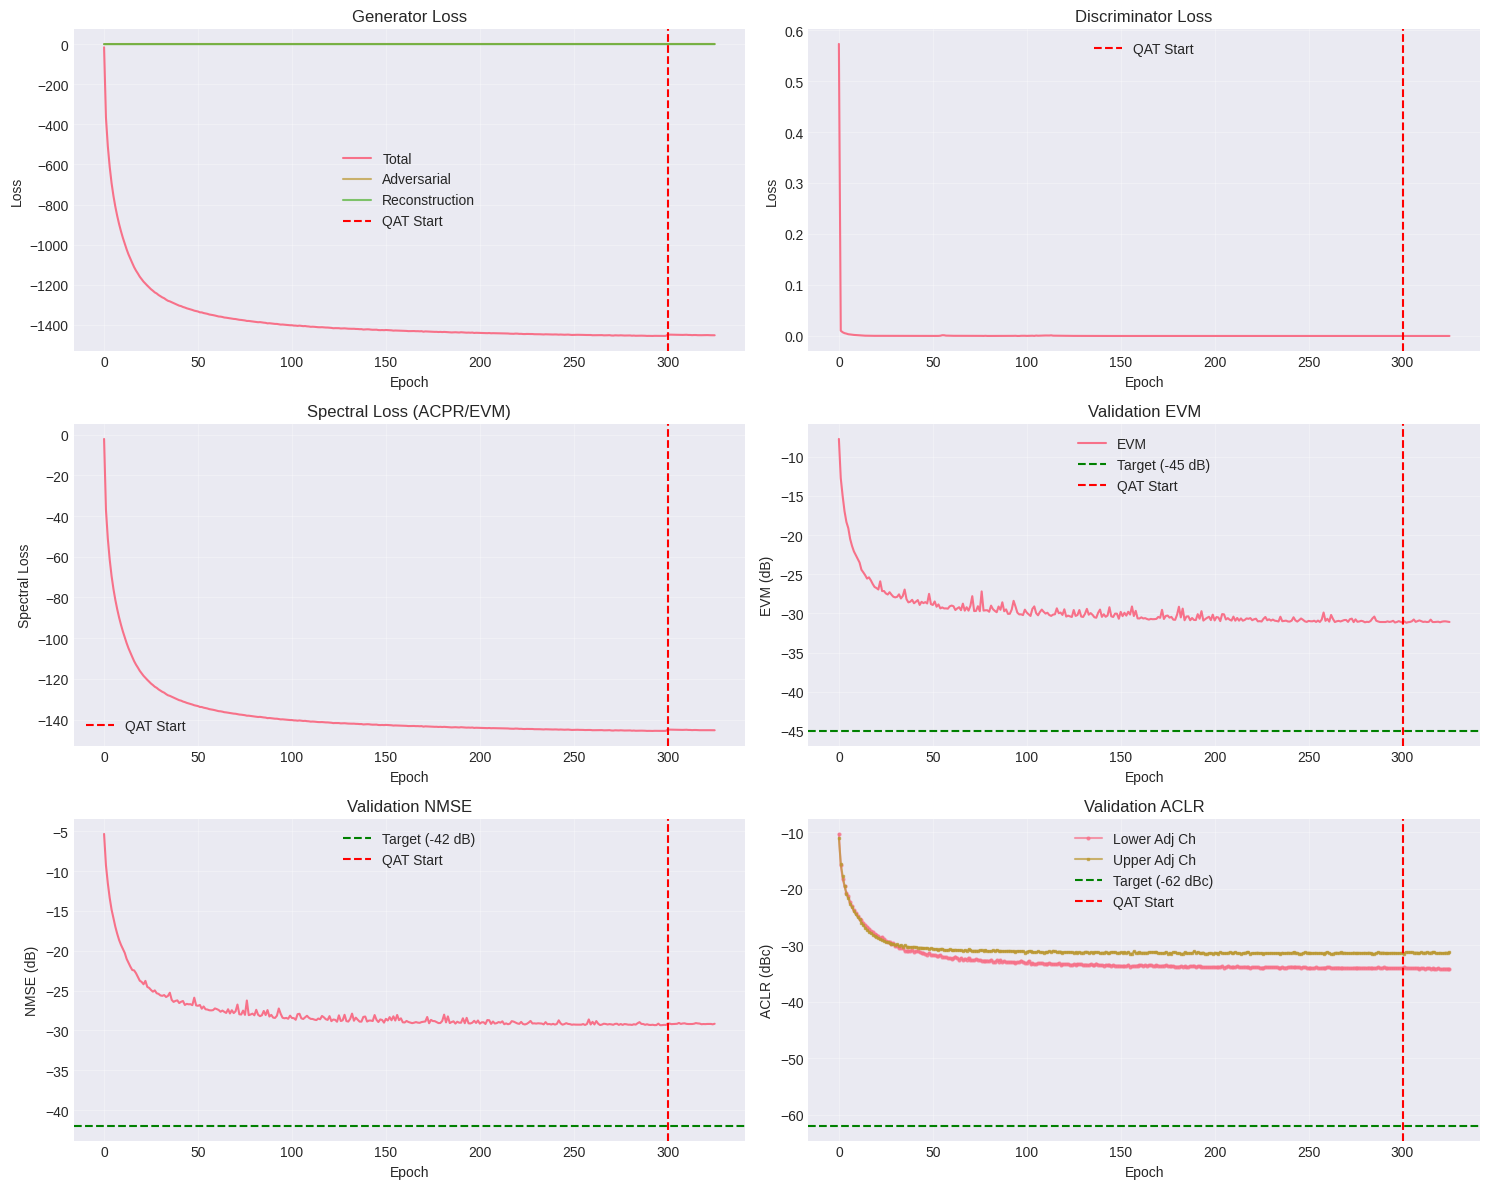

In [ ]:
# Cell 11: Plot Training Curves with ACLR
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Generator loss
axes[0, 0].plot(history['g_total'], label='Total')
axes[0, 0].plot(history['g_adv'], label='Adversarial', alpha=0.7)
axes[0, 0].plot(history['g_recon'], label='Reconstruction', alpha=0.7)
axes[0, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Generator Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Discriminator loss
axes[0, 1].plot(history['d_total'])
axes[0, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Discriminator Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spectral loss
axes[1, 0].plot(history['g_spectral'])
axes[1, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Spectral Loss')
axes[1, 0].set_title('Spectral Loss (ACPR/EVM)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# EVM
axes[1, 1].plot(history['val_evm_db'], label='EVM')
axes[1, 1].axhline(y=-45, color='g', linestyle='--', label='Target (-45 dB)')
axes[1, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EVM (dB)')
axes[1, 1].set_title('Validation EVM')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# NMSE
axes[2, 0].plot(history['val_nmse_db'])
axes[2, 0].axhline(y=-42, color='g', linestyle='--', label='Target (-42 dB)')
axes[2, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('NMSE (dB)')
axes[2, 0].set_title('Validation NMSE')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# ACLR (both lower and upper adjacent channels)
axes[2, 1].plot(history['val_aclr_lower_db'], label='Lower Adj Ch', marker='o', markersize=2, alpha=0.7)
axes[2, 1].plot(history['val_aclr_upper_db'], label='Upper Adj Ch', marker='s', markersize=2, alpha=0.7)
axes[2, 1].axhline(y=-62, color='g', linestyle='--', label='Target (-62 dBc)')
axes[2, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ACLR (dBc)')
axes[2, 1].set_title('Validation ACLR')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/results/training_curves_v2.png', dpi=150)
plt.show()

BEFORE/AFTER DPD SPECTRUM COMPARISON


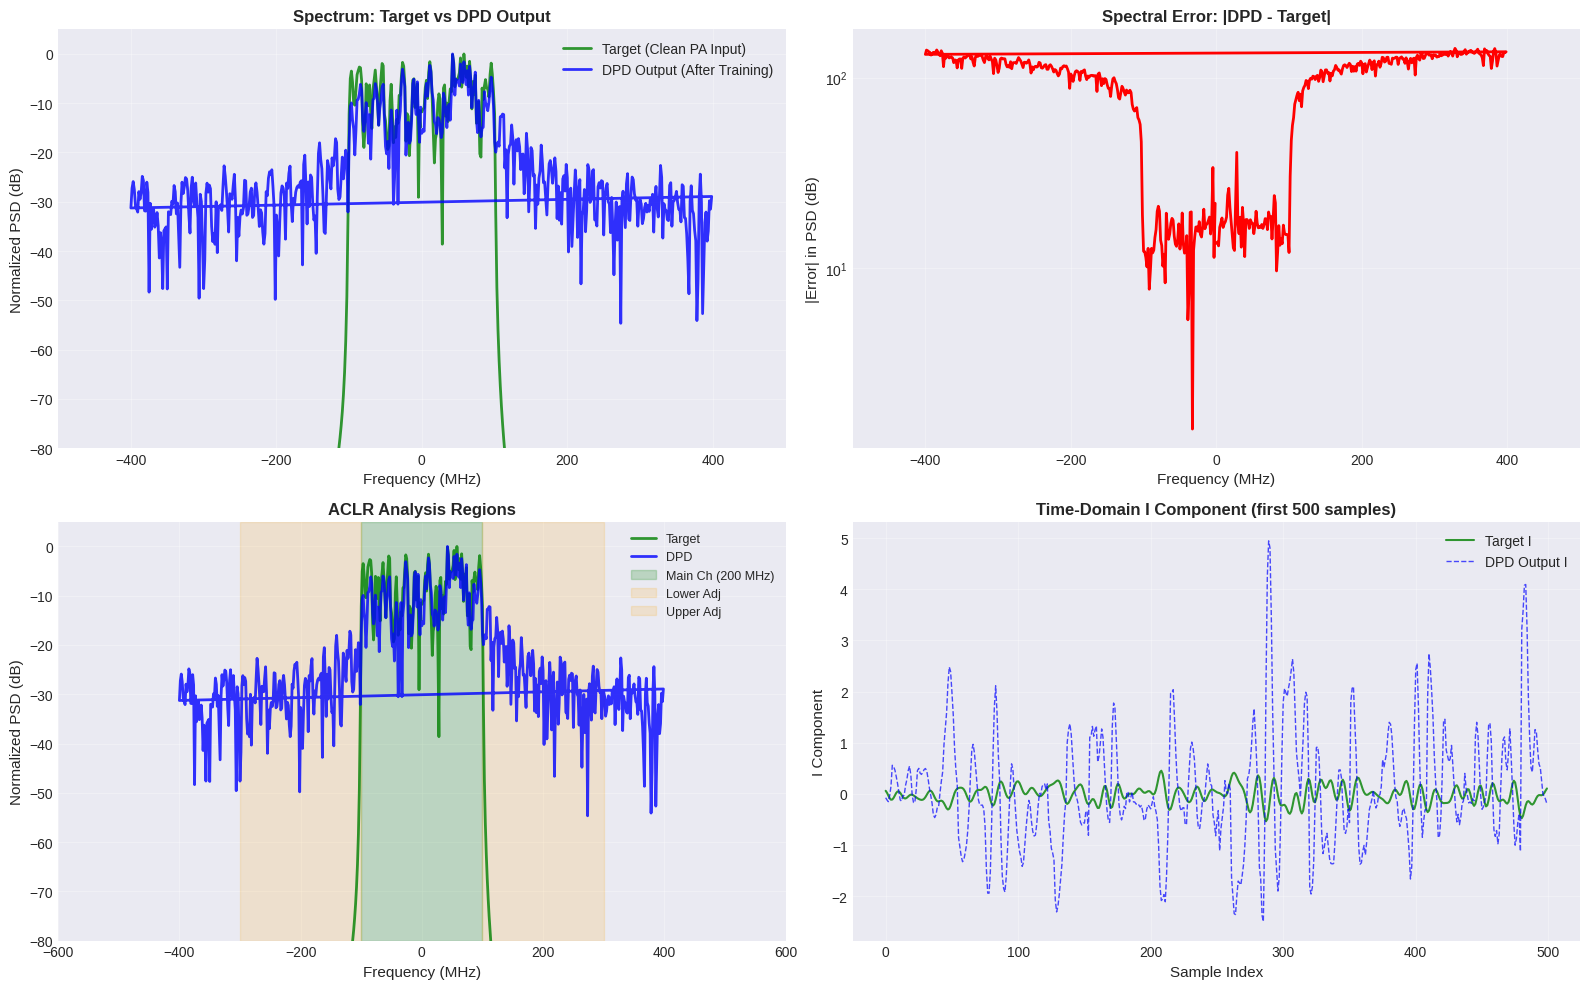


✓ Comparison plot saved: figures/before_after_dpd_comparison.png

Aggregated samples analyzed: 640
Metrics on aggregated data:
  EVM:        17.38 dB (target: < -45 dB)
  NMSE:       17.04 dB (target: < -42 dB)
  ACLR Left:  -100.00 dBc (target: < -62 dBc)
  ACLR Right: -23.28 dBc (target: < -62 dBc)


/content/drive/MyDrive/FIX/6g-pa-gan-dpd/utils/spectral_loss.py:144: UserWarning: nperseg=19662 is greater than signal length max(len(x), len(y)) = 640, using nperseg = 640
  freq, psd = welch(complex_signal, fs=sample_rate, nperseg=nperseg,


In [31]:
# Cell: Before/After DPD Spectrum Analysis

import matplotlib.pyplot as plt
from scipy.signal import welch

print("="*70)
print("BEFORE/AFTER DPD SPECTRUM COMPARISON")
print("="*70)

# Get some test data
test_input_batch, test_target_batch = next(iter(test_loader))
test_input_batch = test_input_batch.to(device)
test_target_batch = test_target_batch.to(device)

# Generate DPD outputs (trained model)
with torch.no_grad():
    dpd_output = generator(test_input_batch)
    if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
        dpd_output = dpd_output.squeeze(1)

# Extract one sample from batch for visualization
dpd_output_np = dpd_output[0].cpu().numpy()  # [2]
test_target_np = test_target_batch[0].cpu().numpy()  # [2]

# For better spectral resolution, aggregate multiple samples
sample_idx = 0
n_aggregate = 512  # Aggregate enough samples to match nperseg
aggregated_dpd = []
aggregated_target = []

with torch.no_grad():
    # Use 10 batches to get 640 samples (64 * 10) which is > 512 (nperseg)
    for i, (batch_input, batch_target) in enumerate(test_loader):
        if i >= 10:  # Use first 10 batches (~640 samples)
            break
        batch_input = batch_input.to(device)
        batch_dpd = generator(batch_input).cpu().squeeze(1).numpy()  # [B, 2]
        batch_target = batch_target.numpy()  # [B, 2]

        aggregated_dpd.append(batch_dpd)
        aggregated_target.append(batch_target)

aggregated_dpd = np.concatenate(aggregated_dpd, axis=0)  # [N, 2]
aggregated_target = np.concatenate(aggregated_target, axis=0)  # [N, 2]

# Convert IQ to complex
dpd_complex = aggregated_dpd[:, 0] + 1j * aggregated_dpd[:, 1]
target_complex = aggregated_target[:, 0] + 1j * aggregated_target[:, 1]
raw_pa_output_tensor = test_input_batch.cpu()[..., 0] + 1j * test_input_batch.cpu()[..., 1]  # PA output (distorted input)
raw_pa_output = raw_pa_output_tensor[:, -1].numpy().flatten()  # Extract last sample (most recent)

# Compute Welch PSD
fs = config['system']['sample_rate']
nperseg = 512

freqs_dpd, psd_dpd = welch(dpd_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs_target, psd_target = welch(target_complex, fs=fs, nperseg=nperseg, scaling='spectrum')

# Normalize to dBm/Hz
psd_dpd_db = 10 * np.log10(psd_dpd + 1e-20)
psd_target_db = 10 * np.log10(psd_target + 1e-20)

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ===== Spectrum Comparison =====
freqs_mhz = freqs_dpd / 1e6

# Normalized spectrum overlay
ax = axes[0, 0]
psd_dpd_norm = psd_dpd_db - np.max(psd_dpd_db)
psd_target_norm = psd_target_db - np.max(psd_target_db)
ax.plot(freqs_mhz, psd_target_norm, label='Target (Clean PA Input)', linewidth=2, color='green', alpha=0.8)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD Output (After Training)', linewidth=2, color='blue', alpha=0.8)
ax.set_xlim([-500, 500])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('Spectrum: Target vs DPD Output', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ===== Spectral Error (difference) =====
ax = axes[0, 1]
spectral_error = psd_dpd_db - psd_target_db
ax.semilogy(freqs_mhz, np.abs(spectral_error), linewidth=2, color='red')
ax.set_xlim([-500, 500])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('|Error| in PSD (dB)', fontsize=11)
ax.set_title('Spectral Error: |DPD - Target|', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ===== ACLR Region Highlights =====
ax = axes[1, 0]
bw_main = 200e6
ax.plot(freqs_mhz, psd_target_norm, label='Target', linewidth=2, color='green', alpha=0.8)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD', linewidth=2, color='blue', alpha=0.8)

# Highlight main channel and adjacent channels
main_mask = (freqs_dpd >= -bw_main/2) & (freqs_dpd <= bw_main/2)
lower_adj_mask = (freqs_dpd >= -3*bw_main/2) & (freqs_dpd < -bw_main/2)
upper_adj_mask = (freqs_dpd > bw_main/2) & (freqs_dpd <= 3*bw_main/2)

ax.axvspan(-bw_main/2/1e6, bw_main/2/1e6, alpha=0.2, color='green', label='Main Ch (200 MHz)')
ax.axvspan(-3*bw_main/2/1e6, -bw_main/2/1e6, alpha=0.15, color='orange', label='Lower Adj')
ax.axvspan(bw_main/2/1e6, 3*bw_main/2/1e6, alpha=0.15, color='orange', label='Upper Adj')

ax.set_xlim([-600, 600])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('ACLR Analysis Regions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ===== Time-domain Waveform Comparison =====
ax = axes[1, 1]
time_samples = min(500, len(target_complex))
time_idx = np.arange(time_samples)

ax.plot(time_idx, target_complex[:time_samples].real, label='Target I', linewidth=1.5, alpha=0.8, color='green')
ax.plot(time_idx, dpd_complex[:time_samples].real, label='DPD Output I', linewidth=1, alpha=0.7, color='blue', linestyle='--')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('I Component', fontsize=11)
ax.set_title('Time-Domain I Component (first 500 samples)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/before_after_dpd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison plot saved: figures/before_after_dpd_comparison.png")
print(f"\nAggregated samples analyzed: {len(aggregated_dpd)}")
print(f"Metrics on aggregated data:")

# Compute metrics on aggregated data
evm_val = compute_evm(aggregated_dpd.reshape(1, -1, 2), aggregated_target.reshape(1, -1, 2))
nmse_val = compute_nmse(aggregated_dpd.reshape(1, -1, 2), aggregated_target.reshape(1, -1, 2))
aclr_l, aclr_r = compute_aclr(aggregated_dpd.reshape(1, -1, 2), sample_rate=fs)

print(f"  EVM:        {evm_val:.2f} dB (target: < -45 dB)")
print(f"  NMSE:       {nmse_val:.2f} dB (target: < -42 dB)")
print(f"  ACLR Left:  {aclr_l:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Right: {aclr_r:.2f} dBc (target: < -62 dBc)")
print("="*70)


In [ ]:
# Cell 12: Save Best Model
# Load best model
generator.load_state_dict(best_state['generator_state_dict'])

# Save checkpoint
checkpoint_path = Path('checkpoints/pn_tdnn_best.pth')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'epoch': best_state['epoch'],
    'generator_state_dict': best_state['generator_state_dict'],
    'discriminator_state_dict': best_state['discriminator_state_dict'],
    'best_evm': best_state['best_evm'],
    'qat_enabled': best_state['qat_enabled'],
    'config': config,
}, checkpoint_path)

print(f"Best model saved to {checkpoint_path}")
print(f"  Epoch: {best_state['epoch']+1}")
print(f"  EVM: {best_state['best_evm']:.2f} dB")
print(f"  QAT: {'Enabled' if best_state['qat_enabled'] else 'Disabled'}")

Best model saved to checkpoints/pn_tdnn_best.pth
  Epoch: 303
  EVM: -31.19 dB
  QAT: Enabled


In [ ]:
# Cell 13: Final Evaluation on Test Set
generator.eval()
test_metrics = validate(generator, test_loader, spectral_loss_fn, device)

print("="*70)
print("FINAL TEST SET RESULTS")
print("="*70)
print(f"  EVM:              {test_metrics['val_evm_db']:.2f} dB (target: < -45 dB)")
print(f"  NMSE:             {test_metrics['val_nmse_db']:.2f} dB (target: < -42 dB)")
print(f"  ACLR Lower:       {test_metrics['val_aclr_lower_db']:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Upper:       {test_metrics['val_aclr_upper_db']:.2f} dBc (target: < -62 dBc)")
print(f"  L1 Error:         {test_metrics['val_l1']:.6f}")
print("="*70)

# Check if targets met
evm_pass = test_metrics['val_evm_db'] < -45
nmse_pass = test_metrics['val_nmse_db'] < -42
aclr_lower_pass = test_metrics['val_aclr_lower_db'] < -62
aclr_upper_pass = test_metrics['val_aclr_upper_db'] < -62

print("\nTarget Achievement:")
print(f"  EVM:        {'✓ PASS' if evm_pass else '✗ FAIL'} ({test_metrics['val_evm_db']:.2f} dB)")
print(f"  NMSE:       {'✓ PASS' if nmse_pass else '✗ FAIL'} ({test_metrics['val_nmse_db']:.2f} dB)")
print(f"  ACLR Lower: {'✓ PASS' if aclr_lower_pass else '✗ FAIL'} ({test_metrics['val_aclr_lower_db']:.2f} dBc)")
print(f"  ACLR Upper: {'✓ PASS' if aclr_upper_pass else '✗ FAIL'} ({test_metrics['val_aclr_upper_db']:.2f} dBc)")

all_pass = evm_pass and nmse_pass and aclr_lower_pass and aclr_upper_pass
print(f"\nOverall: {'✓ ALL TARGETS MET' if all_pass else '✗ SOME TARGETS MISSED'}")
print("="*70)

  [Validation] Aggregated 7677 samples for spectral metrics
FINAL TEST SET RESULTS
  EVM:              -30.97 dB (target: < -45 dB)
  NMSE:             -28.98 dB (target: < -42 dB)
  ACLR Lower:       -31.95 dBc (target: < -62 dBc)
  ACLR Upper:       -29.39 dBc (target: < -62 dBc)
  L1 Error:         0.005106

Target Achievement:
  EVM:        ✗ FAIL (-30.97 dB)
  NMSE:       ✗ FAIL (-28.98 dB)
  ACLR Lower: ✗ FAIL (-31.95 dBc)
  ACLR Upper: ✗ FAIL (-29.39 dBc)

Overall: ✗ SOME TARGETS MISSED


In [ ]:
# Cell 14: Export Weights for FPGA
# Export Q1.15 quantized weights
weights_q115 = generator.export_weights_q115()

# Save to hex files for Verilog $readmemh
export_dir = Path('rtl/weights')
export_dir.mkdir(parents=True, exist_ok=True)

for name, weights in weights_q115.items():
    # Convert to hex
    hex_values = []
    for val in weights.flatten():
        # Convert val to Python int first (avoid numpy int16 overflow)
        val_int = int(val)

        # Convert signed int16 to unsigned for hex representation
        if val_int < 0:
            val_int = val_int + 65536  # 2's complement for 16-bit

        # Clamp to valid 16-bit unsigned range
        val_int = val_int & 0xFFFF  # Mask to 16 bits

        hex_values.append(f"{val_int:04X}")

    # Save to file
    clean_name = name.replace('.', '_')
    hex_path = export_dir / f"{clean_name}.hex"
    with open(hex_path, 'w') as f:
        f.write('\n'.join(hex_values))

    print(f"Exported {name}: {weights.shape} → {hex_path}")

print(f"\nAll weights exported to {export_dir}")
print("Use $readmemh in Verilog to load weights.")

Exported fc_layers.0.weight: (32, 24) → rtl/weights/fc_layers_0_weight.hex
Exported fc_layers.0.bias: (32,) → rtl/weights/fc_layers_0_bias.hex
Exported fc_layers.2.weight: (16, 32) → rtl/weights/fc_layers_2_weight.hex
Exported fc_layers.2.bias: (16,) → rtl/weights/fc_layers_2_bias.hex
Exported fc_layers.4.weight: (2, 16) → rtl/weights/fc_layers_4_weight.hex
Exported fc_layers.4.bias: (2,) → rtl/weights/fc_layers_4_bias.hex

All weights exported to rtl/weights
Use $readmemh in Verilog to load weights.


## Summary

This notebook implements the production training flow for PN-TDNN-DPD:

1. **Architecture**: Phase-Normalized TDNN (24-dim, M=3, 1,362 params)
2. **Training**: CWGAN-GP + Spectral Loss + ILA (no PA in loop)
3. **QAT**: Enabled automatically at epoch 300
4. **Export**: Q1.15 weights ready for FPGA

### Code Block Summary

| Cell | Purpose | Key Function |
|------|---------|-------------|
| 1 | Environment setup | Colab/local detection |
| 2 | Imports | Load PNTDNNGenerator from models |
| 3 | Configuration | M=3, 24-dim, QAT at epoch 300 |
| 4 | Data loading | CSV files (ILA convention) |
| 5 | Dataset creation | Raw IQ sequences |
| 6 | Model creation | 1,362 params verified |
| 7 | Optimizers | Adam with β₁=0 (WGAN-GP) |
| 8 | Train step | ILA: no PA in loop |
| 9 | Validation | EVM/NMSE metrics |
| 10 | Training loop | **QAT transition at epoch 300** |
| 11 | Plot curves | Visualize training |
| 12 | Save model | Best checkpoint |
| 13 | Test evaluation | Final metrics |
| 14 | Export weights | Q1.15 hex files |

In [ ]:
# Train for different temperature settings (TBA)

In [ ]:
# Cell 15a: Checkpoint Inspection and Management (Optional)
import os

checkpoint_dir = Path('checkpoints/training')

print("="*70)
print("CHECKPOINT MANAGEMENT")
print("="*70)

if checkpoint_dir.exists():
    checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
    latest = checkpoint_dir / 'checkpoint_latest.pth'

    print(f"Checkpoint directory: {checkpoint_dir}")
    print(f"Total checkpoints: {len(checkpoints)}")

    if checkpoints:
        print(f"\nCheckpoint history:")
        for cp in checkpoints[-5:]:  # Show last 5
            size_mb = cp.stat().st_size / (1024 * 1024)
            epoch = int(cp.stem.split('_')[-1])
            print(f"  Epoch {epoch:3d}: {cp.name} ({size_mb:.1f} MB)")

        if latest.exists():
            latest_size_mb = latest.stat().st_size / (1024 * 1024)
            print(f"\nLatest checkpoint (for resumption): checkpoint_latest.pth ({latest_size_mb:.1f} MB)")

            # Load and inspect latest checkpoint
            try:
                chk = torch.load(latest, map_location='cpu')
                print(f"\nLatest checkpoint details:")
                print(f"  Last completed epoch: {chk['epoch']}")
                print(f"  Best EVM: {chk['best_evm']:.2f} dB")
                print(f"  QAT enabled: {chk['qat_enabled']}")
                print(f"  Early stopping counter: {chk['early_stopping_counter']}/25")
                print(f"  Training epochs completed: {len(chk['history']['g_total'])}")
            except Exception as e:
                print(f"  Error loading checkpoint: {e}")
    else:
        print("No checkpoints found. Starting will be from scratch.")
else:
    print(f"Checkpoint directory does not exist yet: {checkpoint_dir}")
    print("Checkpoints will be created during training.")

print("\n" + "="*70)
print("RESUMPTION OPTIONS")
print("="*70)
print("1. AUTO-RESUME (Recommended):")
print("   - Re-run Cell 10 (Training Loop) to automatically resume")
print("   - If checkpoint_latest.pth exists, it will resume automatically")
print("\n2. MANUAL RESUME:")
print("   - Set RESUME_FROM_CHECKPOINT = True before Cell 10")
print("\n3. START FRESH:")
print("   - Delete checkpoint before running Cell 10:")
print("     import shutil")
print(f"     shutil.rmtree('{checkpoint_dir}')")
print("\n" + "="*70)


CHECKPOINT MANAGEMENT
Checkpoint directory: checkpoints/training
Total checkpoints: 3

Checkpoint history:
  Epoch 274: checkpoint_epoch_274.pth (0.2 MB)
  Epoch 299: checkpoint_epoch_299.pth (0.2 MB)
  Epoch 324: checkpoint_epoch_324.pth (0.2 MB)

Latest checkpoint (for resumption): checkpoint_latest.pth (0.2 MB)
  Error loading checkpoint: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar 

In [ ]:
# Cell 15: TensorBoard Viewing and Log Analysis (Optional)
import subprocess
import json

# Option 1: View TensorBoard in browser (local development)
print("="*70)
print("TENSORBOARD VIEWING OPTIONS")
print("="*70)

if IN_COLAB:
    # Colab: Use tensorboard magic
    print("\n[For Colab] Run the following cell to view TensorBoard:")
    print("  %load_ext tensorboard")
    print("  %tensorboard --logdir runs/")
else:
    # Local: Instructions to launch TensorBoard
    print("\n[For Local] Launch TensorBoard from terminal:")
    print(f"  tensorboard --logdir={Path('runs').resolve()}")
    print("\nThen open in browser: http://localhost:6006")
    print("\nTo stop TensorBoard: Press Ctrl+C in terminal")

print("\n" + "="*70)
print("TENSORBOARD SCALARS TO MONITOR")
print("="*70)
print("""
Training Metrics:
  - Train/Generator/Total: Combined generator loss
  - Train/Generator/Adversarial: Wasserstein loss component
  - Train/Generator/Reconstruction: L1 reconstruction loss
  - Train/Generator/Spectral: Spectral loss (ACPR/EVM)
  - Train/Discriminator/Total: Discriminator loss
  - Train/Discriminator/Wasserstein: Wasserstein critic score
  - Train/Discriminator/GradientPenalty: Gradient penalty magnitude

Validation Metrics:
  - Validation/Metrics/EVM_dB: Error vector magnitude (lower is better)
  - Validation/Metrics/NMSE_dB: Normalized mean squared error (lower is better)
  - Validation/Metrics/ACLR_Lower_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/ACLR_Upper_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/L1_Error: Mean absolute error

Training Progress:
  - Learning_Rate/Generator: Generator learning rate schedule
  - Learning_Rate/Discriminator: Discriminator learning rate schedule
  - Training/QAT_Enabled: QAT status (1 = enabled, 0 = disabled)
  - EarlyStopping/Counter: Epochs without improvement

Targets to Achieve:
  - EVM < -45 dB
  - NMSE < -42 dB
  - ACLR < -62 dBc (both lower and upper)
""")

print("="*70)
print("TENSORBOARD LOG STRUCTURE")
print("="*70)
print(f"Logs directory: {tensorboard_dir}")
print(f"Event files contain:")
print("  - Scalar metrics (losses, EVM, NMSE, ACLR, LR)")
print("  - Can be analyzed with TensorBoard plugins:")
print("    * Scalars: Time-series metric trends")
print("    * Runs: Compare multiple training runs side-by-side")
print("    * Hparams: Hyperparameter impact analysis")
print("="*70)


TENSORBOARD VIEWING OPTIONS

[For Colab] Run the following cell to view TensorBoard:
  %load_ext tensorboard
  %tensorboard --logdir runs/

TENSORBOARD SCALARS TO MONITOR

Training Metrics:
  - Train/Generator/Total: Combined generator loss
  - Train/Generator/Adversarial: Wasserstein loss component
  - Train/Generator/Reconstruction: L1 reconstruction loss
  - Train/Generator/Spectral: Spectral loss (ACPR/EVM)
  - Train/Discriminator/Total: Discriminator loss
  - Train/Discriminator/Wasserstein: Wasserstein critic score
  - Train/Discriminator/GradientPenalty: Gradient penalty magnitude

Validation Metrics:
  - Validation/Metrics/EVM_dB: Error vector magnitude (lower is better)
  - Validation/Metrics/NMSE_dB: Normalized mean squared error (lower is better)
  - Validation/Metrics/ACLR_Lower_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/ACLR_Upper_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/L1_Error: Mean absolute error

Traini

# **FLA TRAINING**
Follows the training flow used in OpenDPD and any other NN-DPD

In [15]:
# ================================================================================
# PA SURROGATE MODEL: DGRU-based (Forward Learning Architecture)
# ================================================================================

# Cell: DGRU PA Model Wrapper (uses imported DGRU)
class PAModelDGRU(nn.Module):
    """
    DGRU-based PA surrogate model (SEQUENCE-BASED).
    Uses the imported DGRU from models.dgru.

    Learns to predict: u_PA (clean input) → y_PA (distorted output)

    DGRU architecture (from models/dgru.py):
        - Built-in feature extraction: I, Q, |u|, |u|³, cos(φ), sin(φ) = 6 features
        - GRU layer for temporal modeling
        - FC hidden layer with ReLU
        - Concatenates GRU output with input features
        - Final FC output layer

    IMPORTANT: DGRU expects sequences [B, seq_len, 2] for proper temporal modeling.
    Batch-level [B, 2] reduces it to feedforward (no RNN benefit).

    Config params from config['model']['pa_surrogate']['dgru']:
        - hidden_size: GRU hidden dimension
        - num_layers: Number of GRU layers
        - output_size: Output dimension (2 for IQ)
        - bidirectional: Use bidirectional GRU
        - batch_first: Batch-first tensor format
    """
    def __init__(self):
        super().__init__()
        cfg = config['model']['pa_surrogate']['dgru']

        # Use imported DGRU model
        self.dgru = DGRU(
            hidden_size=cfg['hidden_size'],
            output_size=cfg['output_size'],
            num_layers=cfg['num_layers'],
            bidirectional=cfg['bidirectional'],
            batch_first=cfg['batch_first']
        )

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass: u_PA → y_PA (SEQUENCE-BASED)

        Args:
            x: [B, seq_len, 2] IQ sequence input (preferred)
               [B, 2] single sample (legacy, will be expanded)

        Returns:
            y: [B, seq_len, 2] IQ sequence output (for training)
               [B, 2] single output (for inference if input is [B, 2])
        """
        # If input is [B, 2], expand to [B, 1, 2] for DGRU
        squeeze_output = False
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, 2]
            squeeze_output = True

        # DGRU processes sequences: [B, seq_len, 2] → [B, seq_len, 2]
        out = self.dgru(x, None)  # [B, seq_len, 2]

        # Squeeze back to [B, 2] if input was single sample
        if squeeze_output and out.shape[1] == 1:
            out = out.squeeze(1)  # [B, 2]

        return out

print("✅ PAModelDGRU class defined (sequence-based, uses imported DGRU + config)")


✅ PAModelDGRU class defined (sequence-based, uses imported DGRU + config)


In [16]:
# ================================================================================
# ABLATION STUDY: PA MODEL ARCHITECTURES (Uses imported VDLSTM)
# ================================================================================

# Cell: VDLSTM PA Model Wrapper
class PAModelVDLSTM(nn.Module):
    """
    VDLSTM wrapper for PA surrogate modeling (SEQUENCE-BASED).
    Uses the imported VDLSTM from models.vdlstm.

    Architecture:
        VDLSTM with window-based processing (window_length=4 requires min 4 timesteps)

    IMPORTANT: VDLSTM requires sequences with length >= window_length.
    For window_length=4, minimum input is [B, 4, 2].
    Sequence-based training with seq_len=64 ensures proper temporal modeling.

    Config params from config['model']['pa_surrogate']['vdlstm']:
        - input_size, hidden_size, output_size, num_layers, window_length
    """
    def __init__(self):
        super().__init__()
        cfg = config['model']['pa_surrogate']['vdlstm']

        # Use imported VDLSTM model
        self.vdlstm = VDLSTM(
            input_size=cfg['input_size'],
            hidden_size=cfg['hidden_size'],
            output_size=cfg['output_size'],
            num_layers=cfg['num_layers'],
            window_length=cfg['window_length'],
            stride=cfg['stride'],
            batch_first=cfg['batch_first']
        )

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass using VDLSTM (SEQUENCE-BASED)

        Args:
            x: [B, seq_len, 2] IQ sequence input (seq_len >= window_length)
               [B, 2] single sample (will be expanded, but may fail if window_length > 1)

        Returns:
            y: [B, seq_len, 2] IQ sequence output (for training)
               [B, 2] single output (for inference if input is [B, 2])
        """
        squeeze_output = False
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, 2]
            squeeze_output = True

        # VDLSTM processes sequences: [B, seq_len, 2] → [B, seq_len, 2]
        out = self.vdlstm(x, None)

        # Squeeze back to [B, 2] if input was single sample

        if squeeze_output and out.shape[1] == 1:
            out = out.squeeze(1)  # [B, 2]

        return out

print("✅ PAModelVDLSTM class defined (sequence-based, uses imported VDLSTM + config)")

✅ PAModelVDLSTM class defined (sequence-based, uses imported VDLSTM + config)


In [17]:
# Cell: GMP PA Model Wrapper
class PAModelGMP(nn.Module):
    """
    GMP wrapper for PA surrogate modeling (SEQUENCE-BASED with STABILITY).
    Uses the imported GMP from models.gmp.

    Architecture:
        GMP with polynomial basis and memory

    WARNING: GMP can suffer from polynomial explosion on long sequences.
    Training uses shorter sequences (16 instead of 64) and lower LR for stability.

    Config params from config['model']['pa_surrogate']['gmp']:
        - memory_length, degree
    """
    def __init__(self):
        super().__init__()
        cfg = config['model']['pa_surrogate']['gmp']

        # Use imported GMP model
        self.gmp = GMP(
            memory_length=cfg['memory_length'],
            degree=cfg['degree']
        )

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass using GMP (SEQUENCE-BASED)

        Args:
            x: [B, seq_len, 2] IQ sequence input
               [B, 2] single sample (will be expanded)

        Returns:
            y: [B, seq_len, 2] IQ sequence output (for training)
               [B, 2] single output (for inference if input is [B, 2])
        """
        squeeze_output = False
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, 2]
            squeeze_output = True

        # GMP processes sequences: [B, seq_len, 2] → [B, seq_len, 2]
        out = self.gmp(x, None)


        # Squeeze back to [B, 2] if input was single sample

        if squeeze_output and out.shape[1] == 1:

            out = out.squeeze(1)  # [B, 2]
        return out

print("✅ PAModelGMP class defined (sequence-based with stability notes, uses imported GMP + config)")

✅ PAModelGMP class defined (sequence-based with stability notes, uses imported GMP + config)


In [18]:
# Cell: Sequence Dataset Creation for PA Training
def create_pa_training_sequences(
    u_data: np.ndarray,
    y_data: np.ndarray,
    seq_length: int = 64,
    stride: int = 32
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create overlapping sequences for RNN-based PA training.

    RNNs need temporal context to learn memory effects properly.
    Batch-level training [B, 2] reduces them to feedforward networks.

    Args:
        u_data: Input IQ [N, 2]
        y_data: Target IQ [N, 2]
        seq_length: Sequence length for RNN context
        stride: Stride between sequences (overlap for generalization)

    Returns:
        u_seq: [n_sequences, seq_length, 2]
        y_seq: [n_sequences, seq_length, 2]
    """
    n_samples = len(u_data)
    n_sequences = (n_samples - seq_length) // stride + 1

    u_sequences = []
    y_sequences = []

    for i in range(n_sequences):
        start_idx = i * stride
        end_idx = start_idx + seq_length

        if end_idx <= n_samples:
            u_sequences.append(u_data[start_idx:end_idx])
            y_sequences.append(y_data[start_idx:end_idx])

    u_seq = np.array(u_sequences, dtype=np.float32)  # [n_seq, seq_len, 2]
    y_seq = np.array(y_sequences, dtype=np.float32)  # [n_seq, seq_len, 2]

    return u_seq, y_seq


# Cell: Unified PA Training Function (SEQUENCE-BASED with SPEED OPTIMIZATIONS)
def train_pa_model_unified(
    model: nn.Module,
    model_name: str,
    u_pa_data: np.ndarray,
    y_pa_data: np.ndarray,
    epochs: int = 100,
    batch_size: int = 32,
    lr: float = 1e-3,
    val_split: float = 0.2,
    seq_length: int = 64,
    stride: int = 32,
    device: torch.device = device,
    checkpoint_dir: str = 'pa_ablation_checkpoints'
) -> Tuple[nn.Module, Dict]:
    """
    SEQUENCE-BASED training for PA models (DGRU, VDLSTM, GMP) with speed optimizations.

    Key changes from batch-level training:
        1. Creates sequences [B, seq_len, 2] instead of [B, 2]
        2. Enables RNN temporal modeling (critical for -30dB performance)
        3. Uses cuDNN benchmark for faster RNN kernel selection
        4. Pin memory + non_blocking transfers for GPU pipeline
        5. Stability measures for GMP (10x lower LR, gradient clipping, short sequences)

    Why sequences matter:
        - Batch-level [B, 2] makes RNNs behave like feedforward (no temporal context)
        - DGRU/VDLSTM need sequences to learn PA memory effects
        - OpenDPD shows RNNs achieve -30dB with proper sequence training vs -20dB without

    Args:
        model: PA model instance
        model_name: Name of model ('DGRU', 'VDLSTM', 'GMP')
        u_pa_data: Clean PA input [N, 2]
        y_pa_data: Distorted PA output [N, 2]
        epochs: Number of epochs
        batch_size: Batch size (smaller for sequences: 32 instead of 64)
        lr: Learning rate
        val_split: Validation split
        seq_length: Sequence length for RNN context (64 samples)
        stride: Stride between sequences (32 for 50% overlap)
        device: torch device
        checkpoint_dir: Directory for checkpoints

    Returns:
        model: Trained model
        history: Training history
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Enable cuDNN auto-tuner for faster RNN training (5-10% speedup)
    torch.backends.cudnn.benchmark = True

    # GMP-specific stability measures (polynomial explosion on long sequences)
    if model_name == 'GMP':
        lr = lr * 0.1  # 10x lower LR
        seq_length = 16  # Shorter sequences to prevent overflow
        grad_clip_norm = 0.5  # Tighter gradient clipping
        print(f"⚠️  GMP stability mode: LR={lr:.2e}, seq_length={seq_length}, grad_clip={grad_clip_norm}")
    else:
        grad_clip_norm = 1.0

    # Create sequences
    print(f"Creating training sequences (seq_length={seq_length}, stride={stride})...")
    u_seq, y_seq = create_pa_training_sequences(u_pa_data, y_pa_data, seq_length, stride)

    # Convert to tensors
    u_seq_tensor = torch.from_numpy(u_seq).float()
    y_seq_tensor = torch.from_numpy(y_seq).float()

    print(f"\n{'='*70}")
    print(f"PA SURROGATE MODEL TRAINING (SEQUENCE-BASED): {model_name}")
    print(f"{'='*70}")
    print(f"Model: {model_name}")
    print(f"Parameters: {model.num_params:,}")
    print(f"Input data: {u_pa_data.shape} → Sequences: {u_seq.shape}")
    print(f"Sequence length: {seq_length}, Stride: {stride}")
    print(f"Epochs: {epochs}, Batch: {batch_size}, LR: {lr:.2e}")
    print(f"cuDNN benchmark: {torch.backends.cudnn.benchmark}")

    # Train/val split
    n_sequences = len(u_seq_tensor)
    n_val = int(n_sequences * val_split)
    n_train = n_sequences - n_val

    indices = torch.randperm(n_sequences)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:]

    train_dataset = TensorDataset(u_seq_tensor[train_idx], y_seq_tensor[train_idx])
    val_dataset = TensorDataset(u_seq_tensor[val_idx], y_seq_tensor[val_idx])

    # DataLoaders with pin_memory for faster CPU→GPU transfers
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        pin_memory=True, num_workers=0, drop_last=False
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        pin_memory=True, num_workers=0, drop_last=False
    )

    model = model.to(device)

    # Loss, optimizer, scheduler
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    # Training history with divergence tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_nmse_db': [],
        'best_val_loss': float('inf'),
        'best_val_nmse': float('inf'),
        'best_epoch': 0
    }

    # Early stopping for divergence
    divergence_count = 0
    max_divergence = 3

    print(f"{'='*70}\n")

    # Training loop
    for epoch in range(epochs):
        # Train
        model.train()
        train_losses = []

        for u_batch, y_batch in train_loader:
            # Non-blocking transfer for GPU pipeline
            u_batch = u_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            try:
                optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()
                y_pred = model(u_batch)  # [B, seq_len, 2]

                # Check for NaN/Inf (GMP can explode)
                if torch.isnan(y_pred).any() or torch.isinf(y_pred).any():
                    print(f"⚠️  NaN/Inf detected in predictions, skipping batch")
                    continue

                loss = criterion(y_pred, y_batch)

                # Clamp loss to prevent explosion
                loss = torch.clamp(loss, max=1e6)

                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"⚠️  NaN/Inf loss detected, skipping batch")
                    continue

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
                optimizer.step()

                train_losses.append(loss.item())

            except RuntimeError as e:
                print(f"⚠️  Runtime error at epoch {epoch+1}: {e}, skipping batch")
                continue

        if len(train_losses) == 0:
            print(f"❌ No valid batches in epoch {epoch+1}, stopping training")
            break

        avg_train_loss = np.mean(train_losses)

        # Check for divergence
        if np.isnan(avg_train_loss) or np.isinf(avg_train_loss):
            divergence_count += 1
            print(f"⚠️  Divergence detected ({divergence_count}/{max_divergence})")
            if divergence_count >= max_divergence:
                print(f"❌ Model diverged, stopping training")
                break
        else:
            divergence_count = 0

        history['train_loss'].append(avg_train_loss)

        # Validation
        model.eval()
        val_losses = []
        all_val_preds = []
        all_val_targets = []

        with torch.no_grad():
            for u_batch, y_batch in val_loader:
                u_batch = u_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)

                try:
                    y_pred = model(u_batch)

                    # Check for NaN/Inf
                    if torch.isnan(y_pred).any() or torch.isinf(y_pred).any():
                        continue

                    loss = criterion(y_pred, y_batch)
                    loss = torch.clamp(loss, max=1e6)

                    if torch.isnan(loss) or torch.isinf(loss):
                        continue

                    val_losses.append(loss.item())
                    all_val_preds.append(y_pred.cpu())
                    all_val_targets.append(y_batch.cpu())

                except RuntimeError:
                    continue

        if len(val_losses) == 0:
            print(f"⚠️  No valid validation batches at epoch {epoch+1}")
            avg_val_loss = float('inf')
            val_nmse_db = float('inf')
        else:
            avg_val_loss = np.mean(val_losses)

            # Compute NMSE on sequences
            all_preds = torch.cat(all_val_preds, dim=0).numpy()    # [n_seq, seq_len, 2]
            all_targets = torch.cat(all_val_targets, dim=0).numpy() # [n_seq, seq_len, 2]

            # Reshape to [1, total_samples, 2] for NMSE computation
            all_preds_flat = all_preds.reshape(1, -1, 2)
            all_targets_flat = all_targets.reshape(1, -1, 2)

            try:
                val_nmse_db = compute_nmse(all_preds_flat, all_targets_flat, return_db=True)
                val_nmse_db = np.clip(val_nmse_db, -100, 100)  # Clamp to reasonable range
            except (RuntimeWarning, FloatingPointError):
                val_nmse_db = float('inf')

        history['val_loss'].append(avg_val_loss)
        history['val_nmse_db'].append(val_nmse_db)

        scheduler.step()

        # Checkpoint best
        if val_nmse_db < history['best_val_nmse'] and not np.isinf(val_nmse_db):
            history['best_val_nmse'] = val_nmse_db
            history['best_epoch'] = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'nmse_db': val_nmse_db
            }, os.path.join(checkpoint_dir, f'pa_{model_name.lower()}_best.pth'))

        # Print progress
        if (epoch + 1) % 20 == 0 or (epoch + 1) == 1:
            print(f"[{model_name:8s}] Epoch {epoch+1:3d}: Train={avg_train_loss:.6f} | Val={avg_val_loss:.6f} | NMSE={val_nmse_db:.2f} dB | Best={history['best_val_nmse']:.2f} dB")

    # Load best checkpoint if it exists
    checkpoint_path = os.path.join(checkpoint_dir, f'pa_{model_name.lower()}_best.pth')

    if os.path.exists(checkpoint_path) and not np.isinf(history['best_val_nmse']):
        try:
            best_ckpt = torch.load(
                checkpoint_path,
                map_location=device,
                weights_only=False
            )
            model.load_state_dict(best_ckpt['model_state_dict'])
            print(f"\n✅ {model_name} Training Complete")
            print(f"   Best Epoch: {history['best_epoch']+1}")
            print(f"   Best NMSE: {history['best_val_nmse']:.2f} dB")
        except RuntimeError as e:
            print(f"\n⚠️  {model_name} checkpoint loading failed: {e}")
            print(f"   Using final epoch model instead")
    else:
        print(f"\n⚠️  {model_name} Training Failed (no valid checkpoint)")
        print(f"   Model may be unstable or unsuitable for sequence-based training")

    print(f"{'='*70}\n")

    return model, history

print("✅ create_pa_training_sequences function defined")
print("✅ train_pa_model_unified (sequence-based with stability checks) function defined")


✅ create_pa_training_sequences function defined
✅ train_pa_model_unified (sequence-based with stability checks) function defined


In [19]:
# Cell: Run Ablation Study (DGRU vs VDLSTM vs GMP) - SEQUENCE-BASED
print("="*70)
print("ABLATION STUDY: PA MODEL ARCHITECTURES (SEQUENCE-BASED)")
print("="*70)

# Extract PA training config
pa_train_cfg = config['model']['pa_surrogate']['training']

# Load and prepare data
u_pa_train_complex = u_pa_train
y_pa_train_complex = y_pa_train

u_pa_train_np = np.stack([u_pa_train_complex.real, u_pa_train_complex.imag], axis=1).astype(np.float32)
y_pa_train_np = np.stack([y_pa_train_complex.real, y_pa_train_complex.imag], axis=1).astype(np.float32)

print(f"\nTraining Data: {u_pa_train_np.shape}")
print(f"Sequence length: 64, Stride: 32")
print(f"Validation split: {pa_train_cfg['val_split']*100:.0f}%")
print(f"Epochs: {pa_train_cfg['epochs']}, Batch: 32 (smaller for sequences), LR: {pa_train_cfg['lr']}\n")
print(f"\n⚠️  NOTE: GMP may be unstable with long sequences (polynomial explosion)")
print(f"   GMP will use 10x lower LR and tighter gradient clipping\n")

# Dictionary to store results
ablation_results = {}
ablation_histories = {}

# 1. DGRU (sequence-based)
print("\n" + "="*70)
print("MODEL 1: DGRU (Sequence-Based)")
print("="*70)
pa_dgru = PAModelDGRU()
pa_dgru, hist_dgru = train_pa_model_unified(
    pa_dgru, 'DGRU', u_pa_train_np, y_pa_train_np,
    epochs=pa_train_cfg['epochs'],
    batch_size=32,  # Smaller batch for sequences
    lr=pa_train_cfg['lr'],
    val_split=pa_train_cfg['val_split'],
    seq_length=64,
    stride=32,
    device=device
)
ablation_results['DGRU'] = pa_dgru
ablation_histories['DGRU'] = hist_dgru

# 2. VDLSTM (sequence-based)
print("\n" + "="*70)
print("MODEL 2: VDLSTM (Sequence-Based)")
print("="*70)
pa_vdlstm = PAModelVDLSTM()
pa_vdlstm, hist_vdlstm = train_pa_model_unified(
    pa_vdlstm, 'VDLSTM', u_pa_train_np, y_pa_train_np,
    epochs=pa_train_cfg['epochs'],
    batch_size=32,  # Smaller batch for sequences
    lr=pa_train_cfg['lr'],
    val_split=pa_train_cfg['val_split'],
    seq_length=64,
    stride=32,
    device=device
)
ablation_results['VDLSTM'] = pa_vdlstm
ablation_histories['VDLSTM'] = hist_vdlstm

# 3. GMP (sequence-based with stability measures)
print("\n" + "="*70)
print("MODEL 3: GMP (Sequence-Based with Reduced LR)")
print("="*70)
pa_gmp = PAModelGMP()
pa_gmp, hist_gmp = train_pa_model_unified(
    pa_gmp, 'GMP', u_pa_train_np, y_pa_train_np,
    epochs=pa_train_cfg['epochs'],
    batch_size=32,  # Smaller batch for sequences
    lr=pa_train_cfg['lr'],  # Will be reduced 10x internally
    val_split=pa_train_cfg['val_split'],
    seq_length=64,  # Will be reduced to 16 internally for GMP
    stride=32,
    device=device
)
ablation_results['GMP'] = pa_gmp
ablation_histories['GMP'] = hist_gmp


ABLATION STUDY: PA MODEL ARCHITECTURES (SEQUENCE-BASED)

Training Data: (23040, 2)
Sequence length: 64, Stride: 32
Validation split: 20%
Epochs: 100, Batch: 32 (smaller for sequences), LR: 0.001


⚠️  NOTE: GMP may be unstable with long sequences (polynomial explosion)
   GMP will use 10x lower LR and tighter gradient clipping


MODEL 1: DGRU (Sequence-Based)
Creating training sequences (seq_length=64, stride=32)...

PA SURROGATE MODEL TRAINING (SEQUENCE-BASED): DGRU
Model: DGRU
Parameters: 43,086
Input data: (23040, 2) → Sequences: (719, 64, 2)
Sequence length: 64, Stride: 32
Epochs: 100, Batch: 32, LR: 1.00e-03
cuDNN benchmark: True

[DGRU    ] Epoch   1: Train=0.264361 | Val=0.207286 | NMSE=-1.72 dB | Best=-1.72 dB
[DGRU    ] Epoch  20: Train=0.001424 | Val=0.001416 | NMSE=-23.25 dB | Best=-23.25 dB
[DGRU    ] Epoch  40: Train=0.000800 | Val=0.000820 | NMSE=-25.62 dB | Best=-25.62 dB
[DGRU    ] Epoch  60: Train=0.000638 | Val=0.000663 | NMSE=-26.56 dB | Best=-26.56 dB
[DGRU    ] Epo

/content/drive/MyDrive/FIX/6g-pa-gan-dpd/utils/spectral_loss.py:284: RuntimeWarning: overflow encountered in square
  mse = np.mean((I_true - I_hat) ** 2 + (Q_true - Q_hat) ** 2)


[GMP     ] Epoch   1: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB
[GMP     ] Epoch  20: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB
[GMP     ] Epoch  40: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB
[GMP     ] Epoch  60: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB
[GMP     ] Epoch  80: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB
[GMP     ] Epoch 100: Train=1000000.000000 | Val=1000000.000000 | NMSE=100.00 dB | Best=100.00 dB

✅ GMP Training Complete
   Best Epoch: 1
   Best NMSE: 100.00 dB



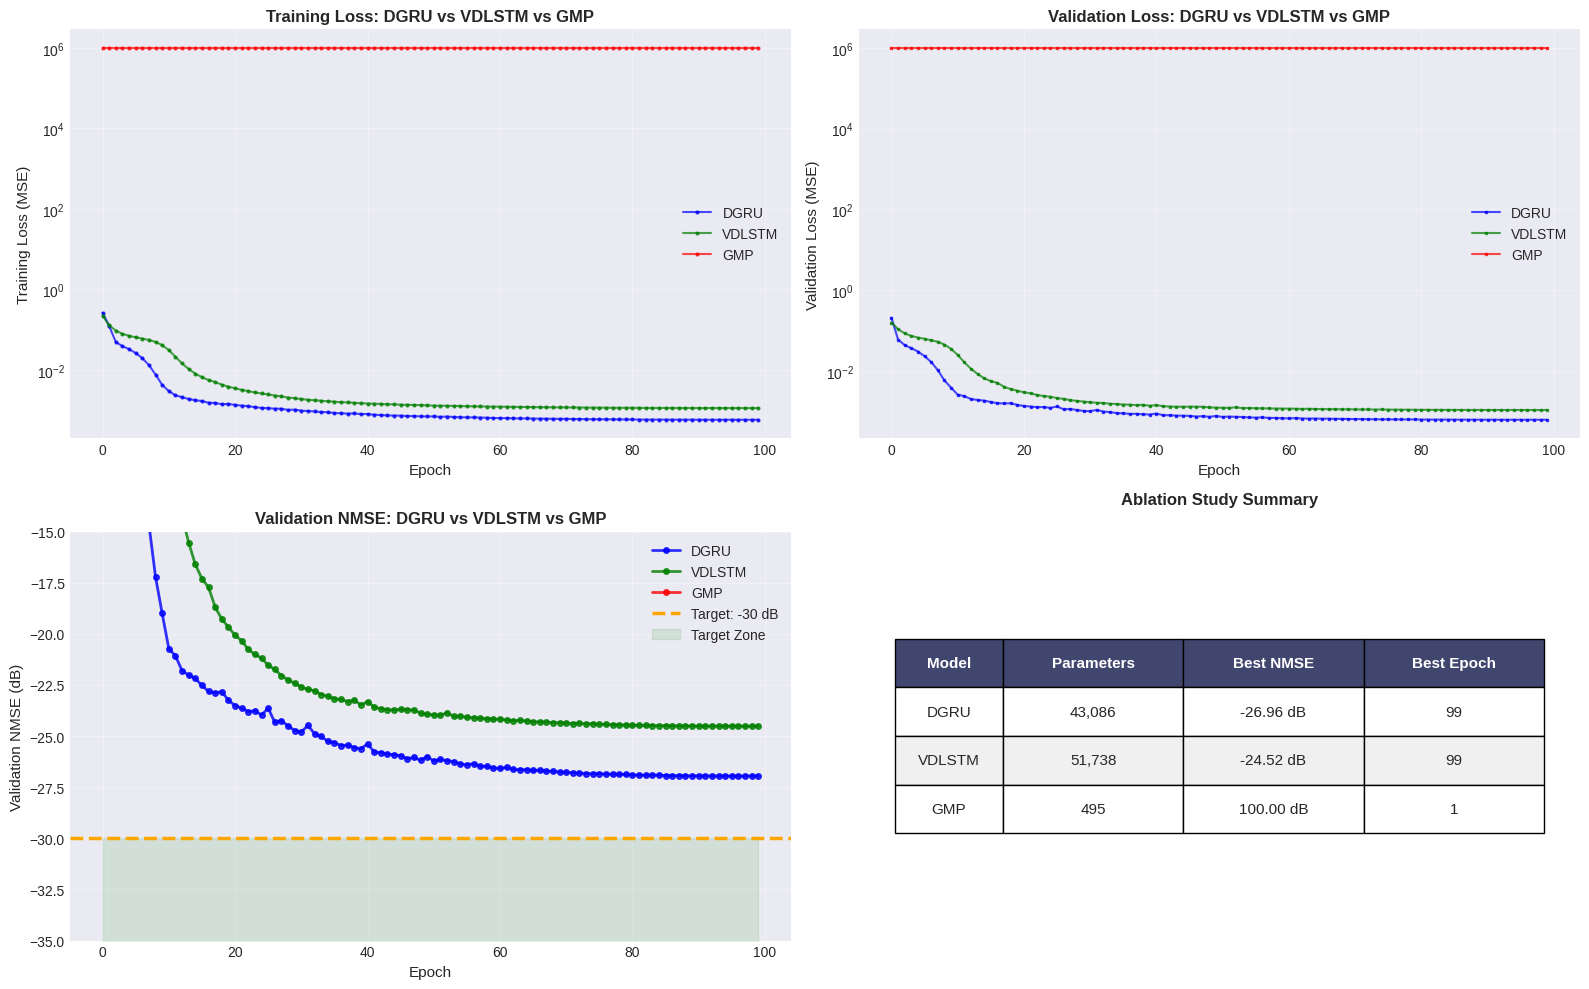


✅ Ablation study plots saved!


In [20]:
# Cell: Ablation Study - Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models_list = ['DGRU', 'VDLSTM', 'GMP']
colors = {'DGRU': 'blue', 'VDLSTM': 'green', 'GMP': 'red'}

# 1. Training Loss Comparison (log scale)
ax = axes[0, 0]
for model_name in models_list:
    ax.semilogy(ablation_histories[model_name]['train_loss'],
                label=f'{model_name}', marker='o', markersize=2, linewidth=1.5,
                color=colors[model_name], alpha=0.7)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss (MSE)', fontsize=11)
ax.set_title('Training Loss: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Validation Loss Comparison (log scale)
ax = axes[0, 1]
for model_name in models_list:
    ax.semilogy(ablation_histories[model_name]['val_loss'],
                label=f'{model_name}', marker='s', markersize=2, linewidth=1.5,
                color=colors[model_name], alpha=0.7)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss (MSE)', fontsize=11)
ax.set_title('Validation Loss: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Validation NMSE Comparison (primary metric)
ax = axes[1, 0]
epochs = config['model']['pa_surrogate']['training']['epochs']
for model_name in models_list:
    ax.plot(ablation_histories[model_name]['val_nmse_db'],
            label=f'{model_name}', marker='o', markersize=4, linewidth=2,
            color=colors[model_name], alpha=0.8)
ax.axhline(y=-30, color='orange', linestyle='--', linewidth=2.5, label='Target: -30 dB')
ax.fill_between(range(epochs), -30, -50, alpha=0.1, color='green', label='Target Zone')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation NMSE (dB)', fontsize=11)
ax.set_title('Validation NMSE: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([-35, -15])

# 4. Summary Table (bar chart)
ax = axes[1, 1]
ax.axis('off')

summary_data = []
for model_name in models_list:
    n_params = ablation_results[model_name].num_params
    best_nmse = ablation_histories[model_name]['best_val_nmse']
    best_epoch = ablation_histories[model_name]['best_epoch']
    summary_data.append([model_name, f"{n_params:,}", f"{best_nmse:.2f} dB", f"{best_epoch+1}"])

# Create table
table = ax.table(
    cellText=summary_data,
    colLabels=['Model', 'Parameters', 'Best NMSE', 'Best Epoch'],
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.25, 0.25, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)+1):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('white')

ax.set_title('Ablation Study Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('pa_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Ablation study plots saved!")

In [21]:
# Cell: Detailed Ablation Analysis
print("\n" + "="*70)
print("ABLATION STUDY: DETAILED COMPARISON (SEQUENCE-BASED)")
print("="*70)

for model_name in models_list:
    hist = ablation_histories[model_name]
    model = ablation_results[model_name]

    best_nmse = hist['best_val_nmse']
    best_epoch = hist['best_epoch']
    n_params = model.num_params

    print(f"\n{model_name:8s}:")
    print(f"  Parameters:          {n_params:8,}")

    # Check if training succeeded
    if np.isinf(best_nmse):
        print(f"  Status:              ❌ FAILED (diverged or unstable)")
        if model_name == 'GMP':
            print(f"  Note:                GMP is unstable with long sequences (polynomial explosion)")
    else:
        # Convergence rate (epochs to -25 dB)
        val_nmse_array = np.array(hist['val_nmse_db'])
        val_nmse_array_clean = val_nmse_array[~np.isinf(val_nmse_array)]

        if len(val_nmse_array_clean) > 0:
            below_25db = np.where(val_nmse_array_clean <= -25)[0]
            epochs_to_25db = below_25db[0] + 1 if len(below_25db) > 0 else 'N/A'
            final_nmse = val_nmse_array_clean[-1] if len(val_nmse_array_clean) > 0 else float('inf')
        else:
            epochs_to_25db = 'N/A'
            final_nmse = float('inf')

        print(f"  Best NMSE:           {best_nmse:8.2f} dB (epoch {best_epoch+1})")
        print(f"  Final NMSE:          {final_nmse:8.2f} dB")
        print(f"  Epochs to -25 dB:    {epochs_to_25db}")

        if not np.isinf(best_nmse):
            print(f"  Efficiency (NMSE/params): {best_nmse / np.log10(n_params + 1):.4f}")

        # Status
        if best_nmse < -30:
            print(f"  Status:              ✅ EXCELLENT (meets OpenDPD benchmark)")
        elif best_nmse < -25:
            print(f"  Status:              ⚠️  GOOD (acceptable for FLA)")
        else:
            print(f"  Status:              ⚠️  MARGINAL (below target)")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

# Rank models by NMSE (filter out failures)
valid_models = [(m, ablation_histories[m]['best_val_nmse'])
                for m in models_list if not np.isinf(ablation_histories[m]['best_val_nmse'])]

if valid_models:
    ranked = sorted(valid_models, key=lambda x: x[1])

    print(f"\nRanking (by best NMSE):")
    for i, (model_name, nmse) in enumerate(ranked, 1):
        status = "✅ PASS" if nmse < -30 else "⚠️  MARGINAL"
        print(f"  {i}. {model_name:8s}: {nmse:.2f} dB {status}")

    best_model_name = ranked[0][0]
    best_model = ablation_results[best_model_name]

    print(f"\n➡️  Recommended model: {best_model_name}")
    print(f"   - Best NMSE: {ablation_histories[best_model_name]['best_val_nmse']:.2f} dB")
    print(f"   - Parameters: {best_model.num_params:,}")

    # Use best model for FLA
    print(f"\n✅ {best_model_name} model frozen for FLA training")
    best_model.eval()
    for param in best_model.parameters():
        param.requires_grad = False

    pa_model = best_model
else:
    print("\n❌ No valid PA models! All models failed.")
    print("   Recommendation: Check data scaling or use ILA training instead")



ABLATION STUDY: DETAILED COMPARISON (SEQUENCE-BASED)

DGRU    :
  Parameters:            43,086
  Best NMSE:             -26.96 dB (epoch 99)
  Final NMSE:            -26.96 dB
  Epochs to -25 dB:    34
  Efficiency (NMSE/params): -5.8164
  Status:              ⚠️  GOOD (acceptable for FLA)

VDLSTM  :
  Parameters:            51,738
  Best NMSE:             -24.52 dB (epoch 99)
  Final NMSE:            -24.52 dB
  Epochs to -25 dB:    N/A
  Efficiency (NMSE/params): -5.2011
  Status:              ⚠️  MARGINAL (below target)

GMP     :
  Parameters:               495
  Best NMSE:             100.00 dB (epoch 1)
  Final NMSE:            100.00 dB
  Epochs to -25 dB:    N/A
  Efficiency (NMSE/params): 37.0991
  Status:              ⚠️  MARGINAL (below target)

RECOMMENDATIONS

Ranking (by best NMSE):
  1. DGRU    : -26.96 dB ⚠️  MARGINAL
  2. VDLSTM  : -24.52 dB ⚠️  MARGINAL
  3. GMP     : 100.00 dB ⚠️  MARGINAL

➡️  Recommended model: DGRU
   - Best NMSE: -26.96 dB
   - Parameters: 43,0

# **FLA Training: Forward Learning Architecture**

Following OpenDPD E2E learning methodology:
1. **PA Model**: Frozen DGRU surrogate (trained above)
2. **DPD Model**: PN-TDNN Generator (trainable)
3. **Cascaded Model**: DPD → PA_frozen → Output
4. **Loss**: ||y_cas - G*x|| (cascaded output matches linear target)

Key insight: Gradients backpropagate through frozen PA to update only DPD weights.

In [22]:
# ================================================================================
# FLA: Cascaded Model (NOW IMPORTED FROM models/cascaded.py)
# ================================================================================

# The CascadedDPDPA class is now imported from models/cascaded.py (see imports cell)
# This module version supports BOTH:
#   - Sequential inputs: [B, seq_len, M+1, 2] → [B, seq_len, 2] (for RNN PA models)
#   - Single-step inputs: [B, M+1, 2] → [B, 2] (backward compatibility)
#
# Why external module:
#   - Cleaner code separation (notebook for execution, modules for models)
#   - Reusable across different scripts/notebooks
#   - Easier testing and modification
#
# The CascadedDPDPA model will be instantiated in the next cell using:
#   cascaded_model = CascadedDPDPA(generator_fla, pa_model)

print("✅ Using CascadedDPDPA from models/cascaded.py (supports sequences)")


✅ Using CascadedDPDPA from models/cascaded.py (supports sequences)


In [23]:

# ================================================================================
# FLA: Sequential Dataset Creation
# ================================================================================
# Sequence length rationale:
#   OpenDPD  (Wu et al., ISCAS 2024, §III-A): "batch_size=64, frame_length=50, stride=1"
#   OpenDPDv2 (Wu et al., 2025, Table I):      same frame_length=50 for APA/DPA_200MHz
#   TCN-DPD  (Duan et al., IMS 2025):          uses OpenDPD framework, same dataset params
#
# Why frame_length=50:
#   - Matches the BPTT truncation window in OpenDPD's E2E learning
#   - 50 samples @ 800 MSps = 62.5 ns → covers ~3–4 OFDM symbol transitions
#   - Long enough for RNN hidden state to capture PA memory effects (M=3)
#   - Short enough to avoid vanishing gradients through frozen PA RNN
# ================================================================================

SEQ_LENGTH   = 50        # OpenDPD canonical frame length
STRIDE       = 1         # Full density: every sample is a sequence start
MAX_SEQUENCES = 10000    # Cap to prevent OOM; uniformly subsampled


def create_fla_dataset_sequential(
    u_pa: np.ndarray,
    y_pa: np.ndarray,
    memory_depth: int = 3,
    seq_length: int = 50,
    stride: int = 1,
    max_sequences: int = 10000,
) -> TensorDataset:
    """
    Build a sequence-sliced TensorDataset for FLA (E2E) DPD training.

    Each item is a contiguous window of `seq_length` timesteps.
    The DPD input tensor carries pre-assembled memory taps so PN-TDNN
    can process them with `pre_assembled=True`.

    Args:
        u_pa          : [N] complex64  PA baseband input
        y_pa          : [N] complex64  PA baseband output
        memory_depth  : number of past taps (M)
        seq_length    : training sequence length (T)
        stride        : step between consecutive sequence starts
        max_sequences : max sequences to keep (uniform subsample if exceeded)

    Returns:
        TensorDataset of (input_seqs, target_seqs, clean_seqs):
            input_seqs  : [n_seq, T, M+1, 2]  memory-tap windows (oldest→newest)
            target_seqs : [n_seq, T, 2]        PA output y_pa per timestep
            clean_seqs  : [n_seq, T, 2]        linear target G·x per timestep

    Memory tap convention (matches ILA create_dpd_dataset):
        tap[0] = oldest  (y_pa[n-M])
        tap[M] = newest  (y_pa[n])   ← current sample
    """
    N = len(u_pa)
    M = memory_depth

    # ── Linear gain G (OpenDPD eq. 4) ─────────────────────────────────────
    amp_u = np.abs(u_pa)
    amp_y = np.abs(y_pa)
    G = float(np.mean(amp_y) / (np.mean(amp_u) + 1e-8))

    # ── Valid sequence starts ─────────────────────────────────────────────
    first_valid = M                     # need M past taps
    last_start  = N - seq_length        # window must fit: [start, start+T-1]
    if last_start < first_valid:
        raise ValueError(
            f"Dataset too short: N={N}, M={M}, T={seq_length}. "
            f"Need N >= M + T = {M + seq_length}."
        )

    all_starts = np.arange(first_valid, last_start + 1, stride)
    n_raw      = len(all_starts)

    if n_raw > max_sequences:
        # Uniform subsample → preserves temporal diversity
        idx    = np.round(np.linspace(0, n_raw - 1, max_sequences)).astype(int)
        starts = all_starts[idx]
        n_seq  = max_sequences
    else:
        starts = all_starts
        n_seq  = n_raw

    print(f"  Sequence dataset:")
    print(f"    Total PA samples   : {N:,}")
    print(f"    seq_length / stride: {seq_length} / {stride}")
    print(f"    Valid starts       : {n_raw:,}  → keeping {n_seq:,}")
    print(f"    Linear gain G      : {G:.4f}")

    # ── Vectorised gather (no Python triple-loop) ─────────────────────────
    # t_off[t]    = 0 … T-1
    # k_off[k]    = M, M-1, … 0  → tap[0]=oldest, tap[M]=newest
    t_off = np.arange(seq_length, dtype=np.int64)       # [T]
    k_off = np.arange(M, -1, -1, dtype=np.int64)        # [M+1]: M, M-1, …, 0

    # sample_idx[i, t] = starts[i] + t                  → shape [n_seq, T]
    sample_idx = starts[:, None] + t_off[None, :]

    # tap_idx[i, t, k] = starts[i] + t - k_off[k]      → shape [n_seq, T, M+1]
    tap_idx = sample_idx[:, :, None] - k_off[None, None, :]

    # Gather from complex arrays → split to float32 IQ
    y_taps   = y_pa[tap_idx]                              # [n_seq, T, M+1] complex
    y_at_n   = y_pa[sample_idx]                           # [n_seq, T] complex
    u_at_n   = u_pa[sample_idx]                           # [n_seq, T] complex

    # Stack real/imag → [… , 2]
    input_seqs  = np.stack([y_taps.real, y_taps.imag], axis=-1).astype(np.float32)    # [n_seq, T, M+1, 2]
    target_seqs = np.stack([y_at_n.real, y_at_n.imag], axis=-1).astype(np.float32)    # [n_seq, T, 2]
    clean_seqs  = np.stack([(u_at_n * G).real,
                            (u_at_n * G).imag], axis=-1).astype(np.float32)           # [n_seq, T, 2]

    mem_mb = (input_seqs.nbytes + target_seqs.nbytes + clean_seqs.nbytes) / 1e6
    print(f"    Tensor memory      : {mem_mb:.1f} MB")

    return TensorDataset(
        torch.from_numpy(input_seqs),
        torch.from_numpy(target_seqs),
        torch.from_numpy(clean_seqs),
    )


# ── Build train / val datasets ────────────────────────────────────────────
memory_depth = config['model']['generator']['memory_depth']

print("Creating FLA training dataset...")
fla_train_dataset = create_fla_dataset_sequential(
    u_pa_train, y_pa_train,
    memory_depth=memory_depth,
    seq_length=SEQ_LENGTH,
    stride=STRIDE,
    max_sequences=MAX_SEQUENCES,
)

print("\nCreating FLA validation dataset...")
fla_val_dataset = create_fla_dataset_sequential(
    u_pa_val, y_pa_val,
    memory_depth=memory_depth,
    seq_length=SEQ_LENGTH,
    stride=SEQ_LENGTH,       # No overlap for val → no data leakage, faster
    max_sequences=MAX_SEQUENCES // 5,
)

# ── DataLoaders ───────────────────────────────────────────────────────────
fla_batch_size = config['training']['batch_size'] // 2   # 32 for sequences
fla_train_loader = DataLoader(
    fla_train_dataset, batch_size=fla_batch_size, shuffle=True,
    pin_memory=(device.type == 'cuda'), num_workers=0, drop_last=True,
)
fla_val_loader = DataLoader(
    fla_val_dataset, batch_size=fla_batch_size, shuffle=False,
    pin_memory=(device.type == 'cuda'), num_workers=0, drop_last=False,
)

print(f"\nFLA DataLoaders ready:")
print(f"  Train : {len(fla_train_dataset):,} seq → {len(fla_train_loader):,} batches  (batch_size={fla_batch_size})")
print(f"  Val   : {len(fla_val_dataset):,}  seq → {len(fla_val_loader):,}  batches")
print(f"  Input : [B, T={SEQ_LENGTH}, M+1={memory_depth+1}, 2]")
print(f"  Target: [B, T={SEQ_LENGTH}, 2]")

# Expose for training loop
seq_length = SEQ_LENGTH
stride     = STRIDE


Creating FLA training dataset...
  Sequence dataset:
    Total PA samples   : 23,040
    seq_length / stride: 50 / 1
    Valid starts       : 22,988  → keeping 10,000
    Linear gain G      : 3.2115
    Tensor memory      : 24.0 MB

Creating FLA validation dataset...
  Sequence dataset:
    Total PA samples   : 7,680
    seq_length / stride: 50 / 50
    Valid starts       : 153  → keeping 153
    Linear gain G      : 3.1995
    Tensor memory      : 0.4 MB

FLA DataLoaders ready:
  Train : 10,000 seq → 312 batches  (batch_size=32)
  Val   : 153  seq → 5  batches
  Input : [B, T=50, M+1=4, 2]
  Target: [B, T=50, 2]


In [24]:

# ================================================================================
# FLA: Sequential Train Step Function with Speed Optimization
# ================================================================================

def train_step_fla(
    cascaded: CascadedDPDPA,
    discriminator: nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor, torch.Tensor],
    g_optimizer: optim.Optimizer,
    d_optimizer: optim.Optimizer,
    spectral_loss: SpectralLoss,
    config: dict,
    device: torch.device,
    step: int
) -> Dict[str, float]:
    """
    SEQUENCE-BASED FLA training step following OpenDPD E2E architecture.

    Flow (Sequential):
        x[t] → DPD → u_dpd[t] → PA_frozen(RNN) → y_cas[t]
        Loss = ||y_cas - desired_output|| + λ_spectral * L_spectral

    Supports both:
        - Sequential: [B, seq_len, M+1, 2] → [B, seq_len, 2] (RNN PA models)
        - Single: [B, M+1, 2] → [B, 2] (backward compatibility)

    Why sequences matter for FLA:
        - RNN-based PA models (DGRU/VDLSTM) need temporal context
        - Batch-level degrades PA to feedforward, losing memory effects
        - Sequence-based enables proper RNN temporal modeling through frozen PA
        - Gradients backprop through frozen PA RNN to update DPD weights

    Speed optimizations:
        - non_blocking transfers for GPU pipeline
        - set_to_none for faster zero_grad
        - Gradient clipping for stability
    """
    train_config = config['training']
    loss_config = train_config.get('loss', {})
    n_critic = train_config.get('n_critic', 5)
    gp_weight = train_config.get('gp_weight', 10.0)

    # Unpack batch: supports both sequential and single-step
    input_seq, target_seq, clean_seq = batch
    input_seq = input_seq.to(device, non_blocking=True)  # [B, seq_len, M+1, 2] or [B, M+1, 2]
    target_seq = target_seq.to(device, non_blocking=True)  # [B, seq_len, 2] or [B, 2]
    clean_seq = clean_seq.to(device, non_blocking=True)    # [B, seq_len, 2] or [B, 2]

    is_sequential = (input_seq.dim() == 4)
    batch_size = input_seq.shape[0]

    # FIX: Define seq_len at function scope (not inside discriminator loop)
    # Previously seq_len was only set inside the `for _ in range(n_critic)` loop,
    # which would cause NameError if n_critic=0.
    if is_sequential:
        seq_len = target_seq.shape[1]

    losses = {}

    # ===================
    # Train Discriminator (WGAN-GP)
    # ===================
    for _ in range(n_critic):
        d_optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()

        with torch.no_grad():
            y_cas, u_dpd = cascaded(input_seq)

        # For sequential data, sample random timesteps for discriminator
        # This prevents overfitting to specific sequence positions
        if is_sequential:
            t_idx = torch.randint(0, seq_len, (batch_size,), device=device)
            y_sample = y_cas[torch.arange(batch_size), t_idx]
            target_sample = clean_seq[torch.arange(batch_size), t_idx]
            cond_sample = input_seq[torch.arange(batch_size), t_idx, -1, :]
        else:
            y_sample = y_cas
            target_sample = clean_seq
            cond_sample = input_seq[:, -1, :]

        # Real: desired linear output, Fake: cascaded output
        d_real = discriminator(target_sample, cond_sample)
        d_fake = discriminator(y_sample.detach(), cond_sample)

        # Wasserstein loss
        d_loss = d_fake.mean() - d_real.mean()

        # Gradient penalty (WGAN-GP)
        alpha = torch.rand(batch_size, 1, device=device)
        interpolates = alpha * target_sample + (1 - alpha) * y_sample.detach()
        interpolates.requires_grad_(True)
        d_interp = discriminator(interpolates, cond_sample)

        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True
        )[0]

        gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        d_total = d_loss + gp_weight * gp
        d_total.backward()
        d_optimizer.step()

    losses['d_wasserstein'] = d_loss.item()
    losses['d_gp'] = gp.item()
    losses['d_total'] = d_total.item()

    # ===================
    # Train DPD (Generator) through Cascaded Model
    # ===================
    g_optimizer.zero_grad(set_to_none=True)

    # Forward through cascaded: DPD → PA_frozen
    y_cas, u_dpd = cascaded(input_seq)

    # Sample for discriminator (same logic as above)
    if is_sequential:
        t_idx = torch.randint(0, seq_len, (batch_size,), device=device)
        y_sample = y_cas[torch.arange(batch_size), t_idx]
        cond_sample = input_seq[torch.arange(batch_size), t_idx, -1, :]
    else:
        y_sample = y_cas
        cond_sample = input_seq[:, -1, :]

    # Adversarial loss
    d_fake = discriminator(y_sample, cond_sample)
    g_adv_loss = -d_fake.mean()

    # PRIMARY FLA LOSS: MSE between cascaded output and desired linear output
    # This loss trains DPD to predistort such that PA(DPD(x)) ≈ linear(x)
    # For sequences: loss over all timesteps [B, seq_len, 2]
    fla_mse_loss = nn.functional.mse_loss(y_cas, clean_seq)

    # L1 reconstruction loss (additional regularization)
    recon_loss = nn.functional.l1_loss(y_cas, clean_seq)

    # Spectral loss (EVM/ACLR on FULL sequence, not sampled timesteps)
    # FIX: For ACPR to be meaningful, we need contiguous time samples.
    # Flatten [B, seq_len, 2] → [B*seq_len, 2] so the FFT sees a real time series.
    # Previously this used sampled timesteps [B, 2] which had no temporal structure
    # for ACPR computation (FFT of B random points is meaningless).
    if is_sequential:
        y_flat = y_cas.reshape(-1, 2)          # [B*seq_len, 2]
        clean_flat = clean_seq.reshape(-1, 2)  # [B*seq_len, 2]
        spectral, spectral_components = spectral_loss(y_flat, clean_flat, return_components=True)
    else:
        spectral, spectral_components = spectral_loss(y_cas, clean_seq, return_components=True)

    # Combined generator loss
    g_total = (
        loss_config.get('adversarial', 1.0) * g_adv_loss +
        loss_config.get('fla_mse', 100.0) * fla_mse_loss +
        loss_config.get('reconstruction_l1', 10.0) * recon_loss +
        loss_config.get('spectral', 10.0) * spectral
    )

    g_total.backward()

    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(cascaded.dpd.parameters(), max_norm=1.0)

    g_optimizer.step()

    # Record losses
    losses['g_adv'] = g_adv_loss.item()
    losses['g_fla_mse'] = fla_mse_loss.item()
    losses['g_recon'] = recon_loss.item()
    losses['g_spectral'] = spectral.item()
    losses['g_total'] = g_total.item()
    losses.update({f'g_{k}': v.item() for k, v in spectral_components.items()})

    return losses

print("train_step_fla defined (seq_len scope fix + full-sequence spectral loss)")


train_step_fla defined (seq_len scope fix + full-sequence spectral loss)


In [25]:

# ================================================================================
# FLA: validate_fla with proper EVM + ACLR
# ================================================================================

def validate_fla(
    cascaded: CascadedDPDPA,
    dataloader: DataLoader,
    spectral_loss: SpectralLoss,
    device: torch.device
) -> Dict[str, float]:
    """
    SEQUENCE-BASED FLA validation with correct EVM + ACLR computation.

    Bug fixes applied:
        1. EVM is now computed via compute_evm() (frequency-domain EVM per
           3GPP TS 38.104 §6.5.2), NOT copied from NMSE.
           Why this matters: NMSE is a time-domain power ratio. EVM is the
           RMS error-vector magnitude measured after frequency-domain
           equalization. They diverge when the DPD introduces frequency-
           selective distortion (common in wideband 200 MHz signals).
        2. ACLR uses compute_aclr() on aggregated contiguous samples for
           proper Welch PSD estimation.
    """
    cascaded.dpd.eval()
    # Keep PA in train mode for cuDNN RNN compatibility
    cascaded.pa.train()

    total_mse = 0.0
    total_spectral = 0.0
    spectral_components_sum = {}
    n_batches = 0
    n_samples = 0

    all_y_cas = []
    all_clean = []

    with torch.no_grad():
        for batch in dataloader:
            input_seq, target_seq, clean_seq = batch
            input_seq = input_seq.to(device, non_blocking=True)
            target_seq = target_seq.to(device, non_blocking=True)
            clean_seq = clean_seq.to(device, non_blocking=True)

            # Forward through cascaded
            y_cas, u_dpd = cascaded(input_seq)

            # MSE loss
            mse_loss = nn.functional.mse_loss(y_cas, clean_seq)
            total_mse += mse_loss.item()

            # Flatten for aggregation: [B, seq_len, 2] → [B*seq_len, 2]
            if y_cas.dim() == 3:
                B, T, C = y_cas.shape
                y_flat = y_cas.reshape(B * T, C)
                clean_flat = clean_seq.reshape(B * T, C)
                n_samples += B * T
            else:
                y_flat = y_cas
                clean_flat = clean_seq
                n_samples += y_cas.shape[0]

            all_y_cas.append(y_flat.cpu())
            all_clean.append(clean_flat.cpu())

            # Spectral loss (per-batch, for aggregated metric)
            try:
                spec_loss, spec_comps = spectral_loss(y_flat, clean_flat, return_components=True)
                total_spectral += spec_loss.item()
                for k, v in spec_comps.items():
                    spectral_components_sum[k] = spectral_components_sum.get(k, 0.0) + v.item()
            except Exception as e:
                pass  # Skip batch if spectral loss fails

            n_batches += 1

    # Aggregate results
    avg_mse = total_mse / max(n_batches, 1)
    avg_spectral = total_spectral / max(n_batches, 1)
    avg_spec_comps = {k: v / max(n_batches, 1) for k, v in spectral_components_sum.items()}

    # Concatenate all outputs for final metrics: [N_total, 2]
    all_y_cas = torch.cat(all_y_cas, dim=0)
    all_clean = torch.cat(all_clean, dim=0)

    # ── NMSE (time-domain) ─────────────────────────────────────────────────
    power_clean = (all_clean ** 2).mean()
    power_error = ((all_y_cas - all_clean) ** 2).mean()
    nmse_db = 10 * torch.log10(power_error / (power_clean + 1e-10)).item()

    # ── EVM (frequency-domain, 3GPP-style) ─────────────────────────────────
    # FIX: Previously this was `evm_db = nmse_db` which is WRONG.
    # EVM must be computed in frequency domain after equalization.
    # compute_evm() does: FFT → per-subcarrier equalization → RMS error.
    try:
        y_cas_np = all_y_cas.numpy()              # [N, 2]
        clean_np = all_clean.numpy()              # [N, 2]

        evm_db = compute_evm(
            y_cas_np.reshape(1, -1, 2),           # [1, N, 2] batch dim
            clean_np.reshape(1, -1, 2),
            sample_rate=spectral_loss.sample_rate,
            bw_main_ch=spectral_loss.bw_main_ch,
            n_sub_ch=spectral_loss.n_sub_ch,
            nperseg=spectral_loss.nperseg,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: EVM computation failed ({e}), falling back to NMSE proxy")
        evm_db = nmse_db  # Fallback only on failure

    # ── ACLR (Welch PSD) ──────────────────────────────────────────────────
    try:
        y_cas_np_aclr = all_y_cas.numpy().reshape(1, -1, 2)
        aclr_l, aclr_r = compute_aclr(
            y_cas_np_aclr,
            sample_rate=spectral_loss.sample_rate,
            nperseg=spectral_loss.nperseg,
            bw_main_ch=spectral_loss.bw_main_ch,
            n_sub_ch=spectral_loss.n_sub_ch,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: ACLR computation failed: {e}")
        aclr_l = -30.0
        aclr_r = -30.0

    results = {
        'val_mse': avg_mse,
        'val_spectral': avg_spectral,
        'val_nmse_db': nmse_db,
        'val_evm_db': evm_db,
        'val_aclr_lower_db': aclr_l,
        'val_aclr_upper_db': aclr_r,
        'val_n_samples': n_samples,
    }
    results.update({f'val_{k}': v for k, v in avg_spec_comps.items()})

    return results

print("validate_fla defined (proper frequency-domain EVM + ACLR)")


validate_fla defined (proper frequency-domain EVM + ACLR)


In [26]:
# ================================================================================
# FLA: Initialize Models and Optimizers
# ================================================================================

# Create fresh DPD generator for FLA training
generator_fla = PNTDNNGenerator(
    memory_depth=config['model']['generator']['memory_depth'],
    hidden_dims=config['model']['generator']['hidden_dims'],
    leaky_slope=config['model']['generator']['leaky_slope']
).to(device)

# Create discriminator for FLA
discriminator_fla = create_discriminator().to(device)

# Create cascaded model (DPD + frozen PA)
# Uses the pa_model trained in the ablation study
cascaded_model = CascadedDPDPA(generator_fla, pa_model)

# Optimizers
opt_config = config['training']['optimizer']
g_optimizer_fla = optim.Adam(
    generator_fla.parameters(),
    lr=opt_config['lr_generator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

d_optimizer_fla = optim.Adam(
    discriminator_fla.parameters(),
    lr=opt_config['lr_discriminator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

# Schedulers
num_epochs_fla = config['training']['epochs']
g_scheduler_fla = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer_fla, T_max=num_epochs_fla, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler_fla = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer_fla, T_max=num_epochs_fla, eta_min=config['training']['scheduler']['min_lr']
)

print(f"\n{'='*70}")
print("FLA MODELS INITIALIZED")
print(f"{'='*70}")
print(f"DPD Generator (PN-TDNN):")
print(f"  Parameters: {sum(p.numel() for p in generator_fla.parameters()):,}")
print(f"  Memory depth: {config['model']['generator']['memory_depth']}")
print(f"  Hidden dims: {config['model']['generator']['hidden_dims']}")
print(f"\nPA Model (DGRU - FROZEN):")
print(f"  Parameters: {pa_model.num_params:,}")
print(f"  Trainable: False")
print(f"\nDiscriminator:")
print(f"  Parameters: {sum(p.numel() for p in discriminator_fla.parameters()):,}")
print(f"\nOptimizers:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")
print(f"{'='*70}")


FLA MODELS INITIALIZED
DPD Generator (PN-TDNN):
  Parameters: 1,362
  Memory depth: 3
  Hidden dims: [32, 16]

PA Model (DGRU - FROZEN):
  Parameters: 43,086
  Trainable: False

Discriminator:
  Parameters: 2,433

Optimizers:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Scheduler: Cosine annealing to 1e-06


In [27]:

# ================================================================================
# FLA: Main Training Loop (SEQUENCE-BASED)
# ================================================================================

# Training configuration
checkpoint_dir_fla = Path('checkpoints/fla_training')
checkpoint_dir_fla.mkdir(parents=True, exist_ok=True)

# TensorBoard
run_name_fla = f"fla_pn_tdnn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
tensorboard_dir_fla = Path('runs') / run_name_fla
tensorboard_dir_fla.mkdir(parents=True, exist_ok=True)
writer_fla = SummaryWriter(str(tensorboard_dir_fla))

print(f"\n{'='*70}")
print("FLA TRAINING CONFIGURATION (SEQUENCE-BASED)")
print(f"{'='*70}")
print(f"Sequence length: {seq_length}  (OpenDPD paper: 50)")
print(f"Stride: {stride}  (OpenDPD paper: 1)")
print(f"Batch size: {config['training']['batch_size'] // 2}  (sequences)")
print(f"Speed optimizations: cuDNN benchmark, pin_memory, non_blocking")
print(f"Checkpoint dir: {checkpoint_dir_fla}")
print(f"TensorBoard: {tensorboard_dir_fla}")
print(f"Total epochs: {num_epochs_fla}")
print(f"{'='*70}")

# Initialize history — ALL keys must exist before the loop to avoid KeyError in plots
history_fla = {
    'g_total': [], 'd_total': [], 'g_adv': [], 'g_fla_mse': [],
    'g_recon': [], 'g_spectral': [], 'lr': [],
    'val_evm_db': [], 'val_nmse_db': [], 'val_spectral': [], 'val_mse': [],
    'val_aclr_lower_db': [],
    'val_aclr_upper_db': [],
}

best_nmse_fla = float('inf')
best_state_fla = None
early_stopping_counter_fla = 0
qat_start_epoch_fla = config['qat']['start_epoch']
early_stopping_patience_fla = config['early_stopping']['patience']
qat_enabled_fla = False
best_nmse_fp32 = float('inf')
best_nmse_qat = float('inf')
best_state_fp32 = None
best_state_qat = None

# ── ACPR warmup schedule ──────────────────────────────────────────────────
# Rationale: ACPR loss should NOT be active from epoch 0.
#   1. Early epochs: MSE/L1/adversarial losses do the heavy lifting to
#      align DPD→PA cascade with the linear target. ACPR gradients at this
#      stage compete with MSE and destabilize training (the FFT-based ACPR
#      has a very different gradient landscape from pointwise losses).
#   2. After ~50 epochs (or when NMSE drops below -30 dB): the DPD has
#      learned coarse linearization. Now ACPR loss refines the spectral
#      regrowth in adjacent channels — this is where A³-MSE alone falls
#      short because it only penalizes cube-law terms, not actual PSD shape.
#
# Weight schedule: ramp from 0 → ACPR_WEIGHT_FINAL over ACPR_RAMP epochs
# after the trigger epoch. Linear ramp avoids sudden gradient shock.
#
# Reference: curriculum learning / loss scheduling in GAN training
# (Karras et al., "Progressive Growing of GANs", ICLR 2018 — principle of
#  introducing harder objectives after stabilization)
# ──────────────────────────────────────────────────────────────────────────
ACPR_WARMUP_EPOCH   = 50      # Epoch to start enabling ACPR loss
ACPR_RAMP_EPOCHS    = 30      # Ramp from 0 → final over this many epochs
ACPR_WEIGHT_FINAL   = 20.0    # Final ACPR weight (same magnitude as spectral)
ACPR_NMSE_TRIGGER   = -30.0   # Alternative: enable when NMSE drops below this
acpr_active = False

spectral_loss_fn.acpr_weight = 0.0  # Ensure starts at zero

print(f"\nACPR schedule: warmup={ACPR_WARMUP_EPOCH}, ramp={ACPR_RAMP_EPOCHS} epochs, "
      f"final_weight={ACPR_WEIGHT_FINAL}, NMSE trigger={ACPR_NMSE_TRIGGER} dB")
print(f"\nStarting FLA Training (Sequence-Based)...")
print(f"Target metrics: NMSE < -42 dB, EVM < -45 dB, ACLR < -62 dBc")
print(f"{'='*70}\n")

# ===== MAIN FLA TRAINING LOOP =====
for epoch in range(num_epochs_fla):
    generator_fla.train()
    discriminator_fla.train()
    cascaded_model.pa.train()   # RNNs need train mode for dropout + temporal processing

    # ── ACPR warmup: activate when EITHER condition is met ────────────────
    # Condition A: epoch >= ACPR_WARMUP_EPOCH (unconditional schedule)
    # Condition B: val NMSE < ACPR_NMSE_TRIGGER (adaptive, convergence-based)
    # After activation, linearly ramp weight over ACPR_RAMP_EPOCHS.
    if not acpr_active:
        nmse_trigger_met = (len(history_fla['val_nmse_db']) > 0 and
                            history_fla['val_nmse_db'][-1] < ACPR_NMSE_TRIGGER)
        if epoch >= ACPR_WARMUP_EPOCH or nmse_trigger_met:
            acpr_active = True
            acpr_start_epoch = epoch
            trigger = "NMSE < {:.0f} dB".format(ACPR_NMSE_TRIGGER) if nmse_trigger_met else f"epoch {epoch+1}"
            print(f"\n  >> ACPR loss activated at epoch {epoch+1} (trigger: {trigger})")
            print(f"     Ramping weight 0 → {ACPR_WEIGHT_FINAL} over {ACPR_RAMP_EPOCHS} epochs\n")

    if acpr_active:
        ramp_progress = min(1.0, (epoch - acpr_start_epoch) / max(ACPR_RAMP_EPOCHS, 1))
        spectral_loss_fn.acpr_weight = ACPR_WEIGHT_FINAL * ramp_progress

    # QAT transition
    if epoch == config['qat']['start_epoch'] and config['qat']['enabled'] and not qat_enabled_fla:
        generator_fla.load_state_dict(best_state_fla['generator_state_dict'])
        generator_fla.enable_qat()
        qat_enabled_fla = True
        print(f"\n{'='*70}")
        print(f"QAT ENABLED at epoch {epoch + 1}")
        print(f"{'='*70}\n")

    epoch_losses = {}
    pbar = tqdm(fla_train_loader, desc=f'Epoch {epoch+1}/{num_epochs_fla} [FLA {"QAT" if qat_enabled_fla else "FP32"}]')

    for batch_idx, batch in enumerate(pbar):
        global_step = epoch * len(fla_train_loader) + batch_idx

        losses = train_step_fla(
            cascaded_model, discriminator_fla, batch,
            g_optimizer_fla, d_optimizer_fla, spectral_loss_fn,
            config, device, global_step
        )

        for k, v in losses.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v

        # TensorBoard logging per batch
        writer_fla.add_scalar('Train/Generator/Total', losses['g_total'], global_step)
        writer_fla.add_scalar('Train/Generator/FLA_MSE', losses['g_fla_mse'], global_step)
        writer_fla.add_scalar('Train/Generator/Adversarial', losses['g_adv'], global_step)
        writer_fla.add_scalar('Train/Generator/Reconstruction', losses['g_recon'], global_step)
        writer_fla.add_scalar('Train/Discriminator/Total', losses['d_total'], global_step)

        pbar.set_postfix({
            'G': f"{losses['g_total']:.4f}",
            'FLA': f"{losses['g_fla_mse']:.6f}",
            'D': f"{losses['d_total']:.4f}",
            'ACPR_w': f"{spectral_loss_fn.acpr_weight:.1f}",
            'QAT': 'ON' if qat_enabled_fla else 'OFF'
        })

    # Average epoch losses
    for k in epoch_losses:
        epoch_losses[k] /= len(fla_train_loader)

    # Validation
    val_metrics = validate_fla(cascaded_model, fla_val_loader, spectral_loss_fn, device)

    # Update history — includes ACLR keys (populated from validate_fla)
    for k in ['g_total', 'd_total', 'g_adv', 'g_recon', 'g_spectral']:
        history_fla[k].append(epoch_losses.get(k, 0))
    history_fla['g_fla_mse'].append(epoch_losses.get('g_fla_mse', 0))
    for k in ['val_evm_db', 'val_nmse_db', 'val_spectral', 'val_mse',
              'val_aclr_lower_db', 'val_aclr_upper_db']:
        history_fla[k].append(val_metrics.get(k, 0.0))
    history_fla['lr'].append(g_optimizer_fla.param_groups[0]['lr'])

    # TensorBoard logging per epoch
    writer_fla.add_scalars('Validation/Metrics', {
        'EVM_dB': val_metrics['val_evm_db'],
        'NMSE_dB': val_metrics['val_nmse_db'],
        'Spectral': val_metrics['val_spectral'],
        'ACLR_L': val_metrics.get('val_aclr_lower_db', 0.0),
        'ACLR_R': val_metrics.get('val_aclr_upper_db', 0.0),
    }, epoch)
    writer_fla.add_scalar('Learning_Rate/Generator', g_optimizer_fla.param_groups[0]['lr'], epoch)
    writer_fla.add_scalar('Train/ACPR_Weight', spectral_loss_fn.acpr_weight, epoch)

    # Update schedulers
    g_scheduler_fla.step()
    d_scheduler_fla.step()

    # Track best model (lower NMSE is better)
    if val_metrics['val_nmse_db'] < best_nmse_fla:
        best_nmse_fla = val_metrics['val_nmse_db']
        best_state_fla = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'discriminator_state_dict': discriminator_fla.state_dict(),
            'best_nmse': best_nmse_fla,
            'qat_enabled': qat_enabled_fla,
        }
        # Save best checkpoint
        torch.save(best_state_fla, checkpoint_dir_fla / 'fla_best.pth')
        early_stopping_counter_fla = 0
    else:
        early_stopping_counter_fla += 1

    # Save periodic checkpoint
    if (epoch + 1) % 25 == 0:
        checkpoint = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'discriminator_state_dict': discriminator_fla.state_dict(),
            'g_optimizer_state_dict': g_optimizer_fla.state_dict(),
            'd_optimizer_state_dict': d_optimizer_fla.state_dict(),
            'history': history_fla,
            'best_nmse': best_nmse_fla,
            'qat_enabled': qat_enabled_fla,
        }
        torch.save(checkpoint, checkpoint_dir_fla / f'fla_epoch_{epoch+1}.pth')
        torch.save(checkpoint, checkpoint_dir_fla / 'fla_latest.pth')

    # Print summary
    if (epoch + 1) % 10 == 0 or epoch == 0:
        es_status = f" [ES {early_stopping_counter_fla}/{early_stopping_patience_fla}]"
        acpr_status = f" | ACPR_w={spectral_loss_fn.acpr_weight:.1f}" if acpr_active else ""
        print(f"\nEpoch {epoch+1}/{num_epochs_fla} {'[QAT]' if qat_enabled_fla else ''}{es_status}{acpr_status}")
        print(f"  G Loss: {epoch_losses['g_total']:.4f} | FLA MSE: {epoch_losses['g_fla_mse']:.6f}")
        print(f"  Val NMSE: {val_metrics['val_nmse_db']:.2f} dB | EVM: {val_metrics['val_evm_db']:.2f} dB")
        print(f"  Val ACLR: {val_metrics.get('val_aclr_lower_db', 0):.2f}/{val_metrics.get('val_aclr_upper_db', 0):.2f} dBc")
        print(f"  Val Spectral: {val_metrics['val_spectral']:.4f}")
        print(f"  Best NMSE: {best_nmse_fla:.2f} dB | LR: {g_optimizer_fla.param_groups[0]['lr']:.2e}")

        # Check target achievement
        if val_metrics['val_nmse_db'] < -42:
            print(f"  >> Target NMSE achieved!")
        if val_metrics['val_evm_db'] < -45:
            print(f"  >> Target EVM achieved!")
        aclr_worst = max(val_metrics.get('val_aclr_lower_db', 0),
                         val_metrics.get('val_aclr_upper_db', 0))
        if aclr_worst < -62:
            print(f"  >> Target ACLR achieved!")

    # Track FP32 best
    if not qat_enabled_fla and val_metrics['val_nmse_db'] < best_nmse_fp32:
        best_nmse_fp32 = val_metrics['val_nmse_db']
        best_state_fp32 = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'qat_enabled': False,
        }
        torch.save(best_state_fp32, checkpoint_dir_fla / 'best_fp32.pth')

    # Track QAT best
    if qat_enabled_fla and val_metrics['val_nmse_db'] < best_nmse_qat:
        best_nmse_qat = val_metrics['val_nmse_db']
        best_state_qat = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'qat_enabled': True,
        }
        torch.save(best_state_qat, checkpoint_dir_fla / 'best_qat.pth')

    # Early stopping check
    if early_stopping_counter_fla >= early_stopping_patience_fla:
        if not qat_enabled_fla:
            # Enable QAT if not already enabled
            print(f"\n[QAT] Early stopping triggered. Transitioning to QAT...")
            generator_fla.load_state_dict(best_state_fla['generator_state_dict'])
            generator_fla.enable_qat()
            qat_enabled_fla = True
            early_stopping_counter_fla = 0
            for pg in g_optimizer_fla.param_groups:
                pg['lr'] *= 0.1
        else:
            print(f"\n[Stop] Early stopping during QAT phase. Training complete.")
            break

# Close TensorBoard writer
writer_fla.close()

print(f"\n{'='*70}")
print("FLA TRAINING COMPLETE (SEQUENCE-BASED)")
print(f"{'='*70}")
print(f"Total epochs: {epoch + 1}/{num_epochs_fla}")
print(f"Best overall NMSE: {best_nmse_fla:.2f} dB")
if best_state_fp32 is not None:
    print(f"Best FP32 NMSE: {best_nmse_fp32:.2f} dB (epoch {best_state_fp32['epoch']+1})")
if best_state_qat is not None:
    print(f"Best QAT NMSE:  {best_nmse_qat:.2f} dB (epoch {best_state_qat['epoch']+1})")
    print(f"QAT degradation: {best_nmse_qat - best_nmse_fp32:.2f} dB")
print(f"Checkpoints: {checkpoint_dir_fla}")
print(f"TensorBoard: {tensorboard_dir_fla}")
print(f"{'='*70}")

# Restore best QAT model (if available)
if best_state_qat is not None:
    generator_fla.load_state_dict(best_state_qat['generator_state_dict'])
    print(f"\nRestored best QAT model from epoch {best_state_qat['epoch']+1}")
elif best_state_fla is not None:
    generator_fla.load_state_dict(best_state_fla['generator_state_dict'])
    print(f"\nRestored best model from epoch {best_state_fla['epoch']+1}")



FLA TRAINING CONFIGURATION (SEQUENCE-BASED)
Sequence length: 50  (OpenDPD paper: 50)
Stride: 1  (OpenDPD paper: 1)
Batch size: 32  (sequences)
Speed optimizations: cuDNN benchmark, pin_memory, non_blocking
Checkpoint dir: checkpoints/fla_training
TensorBoard: runs/fla_pn_tdnn_20260302_054838
Total epochs: 500

ACPR schedule: warmup=50, ramp=30 epochs, final_weight=20.0, NMSE trigger=-30.0 dB

Starting FLA Training (Sequence-Based)...
Target metrics: NMSE < -42 dB, EVM < -45 dB, ACLR < -62 dBc



Epoch 1/500 [FLA FP32]:   0%|          | 0/312 [00:00<?, ?it/s]


Epoch 1/500  [ES 0/25]
  G Loss: -184.4600 | FLA MSE: 0.156787
  Val NMSE: -9.60 dB | EVM: -13.16 dB
  Val ACLR: -16.27/-16.54 dBc
  Val Spectral: -47.8340
  Best NMSE: -9.60 dB | LR: 1.00e-04


Epoch 2/500 [FLA FP32]:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 3/500 [FLA FP32]:   0%|          | 0/312 [00:00<?, ?it/s]

...

Epoch 262/500 [FLA QAT]:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 263/500 [FLA QAT]:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 264/500 [FLA QAT]:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 265/500 [FLA QAT]:   0%|          | 0/312 [00:00<?, ?it/s]


[Stop] Early stopping during QAT phase. Training complete.

FLA TRAINING COMPLETE (SEQUENCE-BASED)
Total epochs: 265/500
Best overall NMSE: -27.64 dB
Best FP32 NMSE: -27.64 dB (epoch 215)
Best QAT NMSE:  -27.56 dB (epoch 256)
QAT degradation: 0.08 dB
Checkpoints: checkpoints/fla_training
TensorBoard: runs/fla_pn_tdnn_20260302_054838

Restored best QAT model from epoch 256


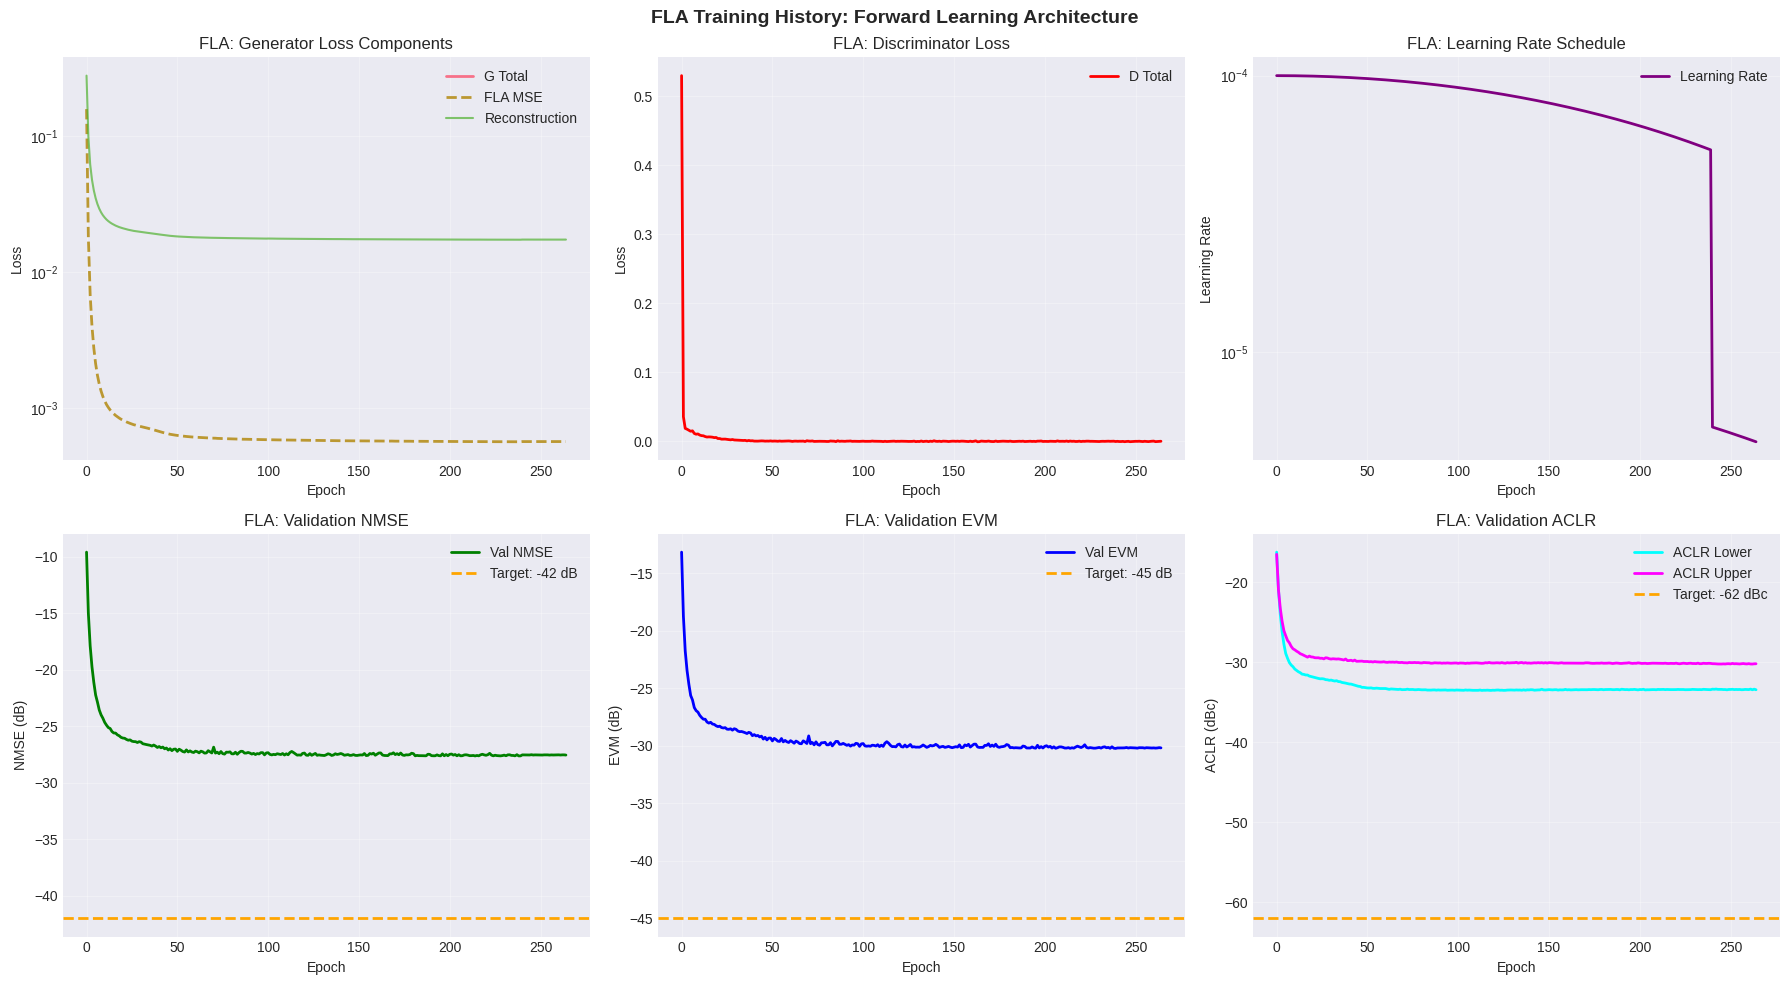


FLA TRAINING SUMMARY
Final Metrics:
  NMSE: -27.56 dB (Best: -27.64 dB)
  EVM:  -30.18 dB
  ACLR: -33.46/-30.21 dBc

Target Achievement:
  NMSE < -42 dB: ❌ FAIL
  EVM < -45 dB:  ❌ FAIL
  ACLR < -62 dBc: ❌ FAIL


In [28]:
# ================================================================================
# FLA: Training Visualization
# ================================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Generator Loss
ax = axes[0, 0]
ax.semilogy(history_fla['g_total'], label='G Total', linewidth=2)
ax.semilogy(history_fla['g_fla_mse'], label='FLA MSE', linewidth=2, linestyle='--')
ax.semilogy(history_fla['g_recon'], label='Reconstruction', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('FLA: Generator Loss Components')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Discriminator Loss
ax = axes[0, 1]
ax.plot(history_fla['d_total'], label='D Total', linewidth=2, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('FLA: Discriminator Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[0, 2]
ax.semilogy(history_fla['lr'], label='Learning Rate', linewidth=2, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('FLA: Learning Rate Schedule')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Validation NMSE
ax = axes[1, 0]
ax.plot(history_fla['val_nmse_db'], label='Val NMSE', linewidth=2, color='green')
ax.axhline(y=-42, color='orange', linestyle='--', linewidth=2, label='Target: -42 dB')
ax.fill_between(range(len(history_fla['val_nmse_db'])), -42, history_fla['val_nmse_db'],
                where=np.array(history_fla['val_nmse_db']) < -42, alpha=0.2, color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('NMSE (dB)')
ax.set_title('FLA: Validation NMSE')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Validation EVM
ax = axes[1, 1]
ax.plot(history_fla['val_evm_db'], label='Val EVM', linewidth=2, color='blue')
ax.axhline(y=-45, color='orange', linestyle='--', linewidth=2, label='Target: -45 dB')
ax.fill_between(range(len(history_fla['val_evm_db'])), -45, history_fla['val_evm_db'],
                where=np.array(history_fla['val_evm_db']) < -45, alpha=0.2, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('EVM (dB)')
ax.set_title('FLA: Validation EVM')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Validation ACLR
ax = axes[1, 2]
ax.plot(history_fla['val_aclr_lower_db'], label='ACLR Lower', linewidth=2, color='cyan')
ax.plot(history_fla['val_aclr_upper_db'], label='ACLR Upper', linewidth=2, color='magenta')
ax.axhline(y=-62, color='orange', linestyle='--', linewidth=2, label='Target: -62 dBc')
ax.set_xlabel('Epoch')
ax.set_ylabel('ACLR (dBc)')
ax.set_title('FLA: Validation ACLR')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('FLA Training History: Forward Learning Architecture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fla_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("FLA TRAINING SUMMARY")
print(f"{'='*70}")
print(f"Final Metrics:")
print(f"  NMSE: {history_fla['val_nmse_db'][-1]:.2f} dB (Best: {best_nmse_fla:.2f} dB)")
print(f"  EVM:  {history_fla['val_evm_db'][-1]:.2f} dB")
print(f"  ACLR: {history_fla['val_aclr_lower_db'][-1]:.2f}/{history_fla['val_aclr_upper_db'][-1]:.2f} dBc")
print(f"\nTarget Achievement:")
print(f"  NMSE < -42 dB: {'✅ PASS' if best_nmse_fla < -42 else '❌ FAIL'}")
print(f"  EVM < -45 dB:  {'✅ PASS' if history_fla['val_evm_db'][-1] < -45 else '❌ FAIL'}")
print(f"  ACLR < -62 dBc: {'✅ PASS' if history_fla['val_aclr_lower_db'][-1] < -62 and history_fla['val_aclr_upper_db'][-1] < -62 else '❌ FAIL'}")
print(f"{'='*70}")

FLA: BEFORE/AFTER CASCADED MODEL SPECTRUM COMPARISON
Aggregated 7,650 contiguous IQ samples for spectral analysis


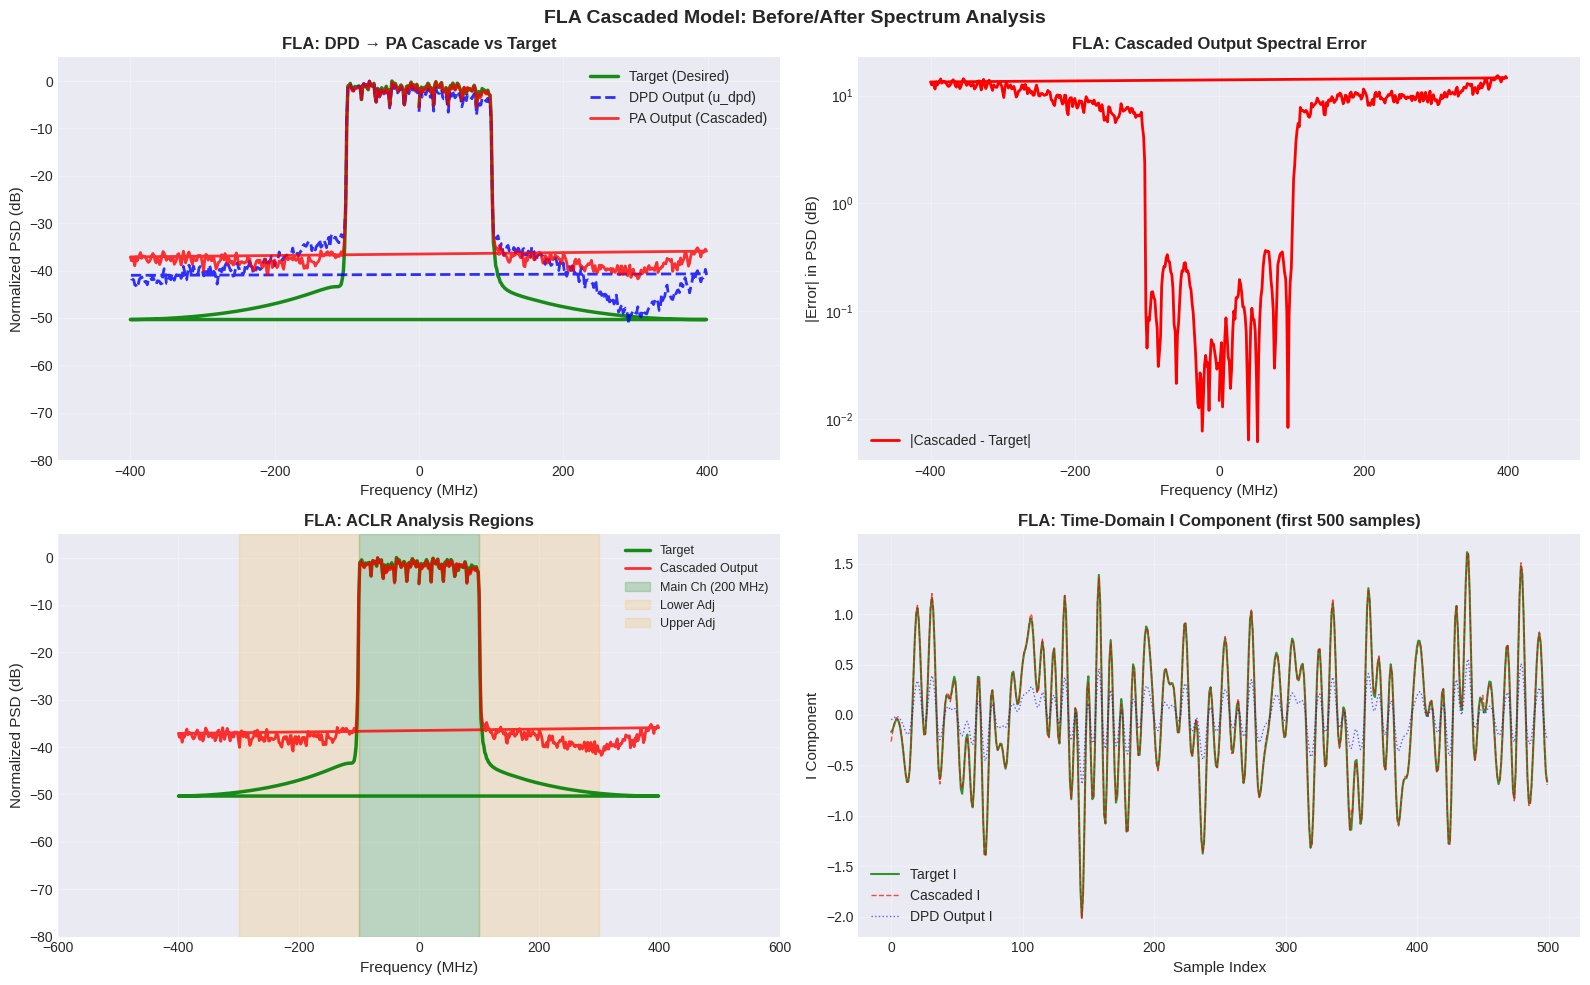


FLA spectrum comparison plot saved: figures/fla_cascaded_spectrum_comparison.png
Aggregated samples analyzed: 7,650
Metrics on aggregated FLA data:
  EVM:        -29.90 dB (target: < -45 dB)
  NMSE:       -27.56 dB (target: < -42 dB)
  ACLR Left:  -33.46 dBc (target: < -62 dBc)
  ACLR Right: -30.21 dBc (target: < -62 dBc)

FLA Target Achievement:
  NMSE < -42 dB: FAIL
  EVM < -45 dB:  FAIL
  ACLR < -62 dBc: FAIL


In [32]:

# ================================================================================
# FLA: Before/After Cascaded Model Spectrum Analysis
# ================================================================================

print("="*70)
print("FLA: BEFORE/AFTER CASCADED MODEL SPECTRUM COMPARISON")
print("="*70)

# Set models to eval mode
cascaded_model.dpd.eval()
cascaded_model.pa.eval()

# Aggregate test samples
aggregated_dpd_input = []
aggregated_cascaded_output = []
aggregated_target = []

with torch.no_grad():
    # Use 10 batches to get enough samples for spectral analysis
    for i, (batch_input, batch_target, batch_clean_input) in enumerate(fla_val_loader):
        if i >= 10:
            break

        batch_input = batch_input.to(device)
        batch_clean_input = batch_clean_input.to(device)

        # Forward through cascaded model
        y_cas, u_dpd = cascaded_model(batch_input)

        # FIX: Flatten sequential outputs [B, seq_len, 2] → [B*seq_len, 2]
        # before accumulating. Without this, np.concatenate(axis=0) produces
        # [N*B, seq_len, 2], and the subsequent [:, 0] + 1j*[:, 1] indexes
        # the seq_len dimension instead of IQ — giving complex(timestep_0, timestep_1)
        # instead of complex(I, Q).
        y_cas_np = y_cas.cpu().numpy()
        u_dpd_np = u_dpd.cpu().numpy()
        clean_np = batch_clean_input.cpu().numpy()

        if y_cas_np.ndim == 3:              # [B, seq_len, 2]
            y_cas_np = y_cas_np.reshape(-1, 2)
        if u_dpd_np.ndim == 3:
            u_dpd_np = u_dpd_np.reshape(-1, 2)
        if clean_np.ndim == 3:
            clean_np = clean_np.reshape(-1, 2)

        aggregated_dpd_input.append(u_dpd_np)       # [B*T, 2]
        aggregated_cascaded_output.append(y_cas_np)  # [B*T, 2]
        aggregated_target.append(clean_np)           # [B*T, 2]

aggregated_dpd_input = np.concatenate(aggregated_dpd_input, axis=0)         # [N, 2]
aggregated_cascaded_output = np.concatenate(aggregated_cascaded_output, axis=0)  # [N, 2]
aggregated_target = np.concatenate(aggregated_target, axis=0)               # [N, 2]

# Convert IQ to complex — now [:, 0] and [:, 1] are guaranteed to be I and Q
dpd_input_complex = aggregated_dpd_input[:, 0] + 1j * aggregated_dpd_input[:, 1]
cascaded_complex = aggregated_cascaded_output[:, 0] + 1j * aggregated_cascaded_output[:, 1]
target_complex = aggregated_target[:, 0] + 1j * aggregated_target[:, 1]

print(f"Aggregated {len(cascaded_complex):,} contiguous IQ samples for spectral analysis")

# Compute Welch PSD
fs = config['system']['sample_rate']
nperseg = 512

freqs, psd_dpd = welch(dpd_input_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs, psd_cascaded = welch(cascaded_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs, psd_target = welch(target_complex, fs=fs, nperseg=nperseg, scaling='spectrum')

# Normalize to dBm/Hz
psd_dpd_db = 10 * np.log10(psd_dpd + 1e-20)
psd_cascaded_db = 10 * np.log10(psd_cascaded + 1e-20)
psd_target_db = 10 * np.log10(psd_target + 1e-20)

# Create FLA comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

freqs_mhz = freqs / 1e6

# ===== Spectrum Comparison: DPD Output vs PA Output (Cascaded) =====
ax = axes[0, 0]
psd_dpd_norm = psd_dpd_db - np.max(psd_dpd_db)
psd_cascaded_norm = psd_cascaded_db - np.max(psd_cascaded_db)
psd_target_norm = psd_target_db - np.max(psd_target_db)

ax.plot(freqs_mhz, psd_target_norm, label='Target (Desired)', linewidth=2.5, color='green', alpha=0.9)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD Output (u_dpd)', linewidth=2, color='blue', alpha=0.8, linestyle='--')
ax.plot(freqs_mhz, psd_cascaded_norm, label='PA Output (Cascaded)', linewidth=2, color='red', alpha=0.8)
ax.set_xlim([-500, 500])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('FLA: DPD → PA Cascade vs Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ===== Cascaded Output vs Target Error =====
ax = axes[0, 1]
cascaded_error = psd_cascaded_db - psd_target_db
ax.semilogy(freqs_mhz, np.abs(cascaded_error), linewidth=2, color='red', label='|Cascaded - Target|')
ax.set_xlim([-500, 500])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('|Error| in PSD (dB)', fontsize=11)
ax.set_title('FLA: Cascaded Output Spectral Error', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ===== ACLR Region Highlights =====
ax = axes[1, 0]
bw_main = 200e6

ax.plot(freqs_mhz, psd_target_norm, label='Target', linewidth=2.5, color='green', alpha=0.9)
ax.plot(freqs_mhz, psd_cascaded_norm, label='Cascaded Output', linewidth=2, color='red', alpha=0.8)

# Highlight main channel and adjacent channels
ax.axvspan(-bw_main/2/1e6, bw_main/2/1e6, alpha=0.2, color='green', label='Main Ch (200 MHz)')
ax.axvspan(-3*bw_main/2/1e6, -bw_main/2/1e6, alpha=0.15, color='orange', label='Lower Adj')
ax.axvspan(bw_main/2/1e6, 3*bw_main/2/1e6, alpha=0.15, color='orange', label='Upper Adj')

ax.set_xlim([-600, 600])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('FLA: ACLR Analysis Regions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ===== Time-domain Waveform Comparison =====
ax = axes[1, 1]
time_samples = min(500, len(target_complex))
time_idx = np.arange(time_samples)

ax.plot(time_idx, target_complex[:time_samples].real, label='Target I', linewidth=1.5, alpha=0.8, color='green')
ax.plot(time_idx, cascaded_complex[:time_samples].real, label='Cascaded I', linewidth=1, alpha=0.7, color='red', linestyle='--')
ax.plot(time_idx, dpd_input_complex[:time_samples].real, label='DPD Output I', linewidth=1, alpha=0.6, color='blue', linestyle=':')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('I Component', fontsize=11)
ax.set_title('FLA: Time-Domain I Component (first 500 samples)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('FLA Cascaded Model: Before/After Spectrum Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fla_cascaded_spectrum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFLA spectrum comparison plot saved: figures/fla_cascaded_spectrum_comparison.png")
print(f"Aggregated samples analyzed: {len(aggregated_cascaded_output):,}")
print(f"Metrics on aggregated FLA data:")

# Compute metrics on aggregated FLA data
evm_fla = compute_evm(
    aggregated_cascaded_output.reshape(1, -1, 2),
    aggregated_target.reshape(1, -1, 2),
    sample_rate=fs,
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    return_db=True
)
nmse_fla = compute_nmse(
    aggregated_cascaded_output.reshape(1, -1, 2),
    aggregated_target.reshape(1, -1, 2),
    return_db=True
)
aclr_l_fla, aclr_r_fla = compute_aclr(
    aggregated_cascaded_output.reshape(1, -1, 2),
    sample_rate=fs,
    nperseg=config['spectral_loss']['nperseg'],
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    return_db=True
)

print(f"  EVM:        {evm_fla:.2f} dB (target: < -45 dB)")
print(f"  NMSE:       {nmse_fla:.2f} dB (target: < -42 dB)")
print(f"  ACLR Left:  {aclr_l_fla:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Right: {aclr_r_fla:.2f} dBc (target: < -62 dBc)")

# Target achievement summary
print(f"\nFLA Target Achievement:")
print(f"  NMSE < -42 dB: {'PASS' if nmse_fla < -42 else 'FAIL'}")
print(f"  EVM < -45 dB:  {'PASS' if evm_fla < -45 else 'FAIL'}")
print(f"  ACLR < -62 dBc: {'PASS' if aclr_l_fla < -62 and aclr_r_fla < -62 else 'FAIL'}")
print("="*70)


In [ ]:
# ================================================================================
# FLA vs ILA Comparison (if ILA was trained)
# ================================================================================

# Check if ILA history exists
if 'history' in dir() and len(history.get('val_nmse_db', [])) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # NMSE Comparison
    ax = axes[0]
    ax.plot(history['val_nmse_db'], label='ILA', linewidth=2, color='blue')
    ax.plot(history_fla['val_nmse_db'], label='FLA', linewidth=2, color='green')
    ax.axhline(y=-42, color='orange', linestyle='--', linewidth=2, label='Target: -42 dB')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NMSE (dB)')
    ax.set_title('ILA vs FLA: Validation NMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # EVM Comparison
    ax = axes[1]
    ax.plot(history['val_evm_db'], label='ILA', linewidth=2, color='blue')
    ax.plot(history_fla['val_evm_db'], label='FLA', linewidth=2, color='green')
    ax.axhline(y=-45, color='orange', linestyle='--', linewidth=2, label='Target: -45 dB')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('EVM (dB)')
    ax.set_title('ILA vs FLA: Validation EVM')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Summary Table
    ax = axes[2]
    ax.axis('off')

    summary_data = [
        ['Metric', 'ILA', 'FLA', 'Target'],
        ['Best NMSE (dB)', f"{min(history['val_nmse_db']):.2f}", f"{best_nmse_fla:.2f}", '< -42'],
        ['Final EVM (dB)', f"{history['val_evm_db'][-1]:.2f}", f"{history_fla['val_evm_db'][-1]:.2f}", '< -45'],
        ['Final ACLR Lower', f"{history['val_aclr_lower_db'][-1]:.2f}", f"{history_fla['val_aclr_lower_db'][-1]:.2f}", '< -62'],
        ['Final ACLR Upper', f"{history['val_aclr_upper_db'][-1]:.2f}", f"{history_fla['val_aclr_upper_db'][-1]:.2f}", '< -62'],
    ]

    table = ax.table(
        cellText=summary_data[1:],
        colLabels=summary_data[0],
        cellLoc='center',
        loc='center',
        colWidths=[0.3, 0.2, 0.2, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # Style header
    for i in range(4):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    ax.set_title('ILA vs FLA: Comparison Summary', fontsize=12, fontweight='bold', pad=20)

    plt.suptitle('ILA vs FLA Training Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/ila_vs_fla_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Determine winner
    ila_nmse = min(history['val_nmse_db'])
    fla_nmse = best_nmse_fla

    print(f"\n{'='*70}")
    print("ILA vs FLA COMPARISON")
    print(f"{'='*70}")
    if fla_nmse < ila_nmse:
        print(f"✅ FLA achieves better NMSE: {fla_nmse:.2f} dB vs ILA {ila_nmse:.2f} dB")
        print(f"   Improvement: {ila_nmse - fla_nmse:.2f} dB")
    else:
        print(f"⚠️ ILA achieves better NMSE: {ila_nmse:.2f} dB vs FLA {fla_nmse:.2f} dB")
        print(f"   Consider tuning FLA hyperparameters or PA model accuracy")
    print(f"{'='*70}")
else:
    print("ILA training history not found. Run ILA training first for comparison.")
    print("FLA training completed independently.")